# Statistics for Michel electron candidate

### Created by Shu, 

##### (20250916) Main update here is the introduction of CLASS, to upgrade current cumbersome data processing

#### Dataset recording (2025 Official MC Production):

minus5GeV:    'run20250627'

minus1GeV:      'run20250614'

pos1GeV:        'run20250613'

pos5GeV:        'run20250623'

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [2]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    energy_initial: float = None
    lifetime_initial: float = None
    pdg_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    """Read a single file into a list."""
    values = []
    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values
    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()
            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")
    return values


def read_multiple(file_paths, cast_type=float):
    """Read multiple files and concatenate them."""
    combined = []
    for path in file_paths:
        combined.extend(read_values(path, cast_type))
    return combined


# ----------------------------- Configuration --------------------------------
data_groups = [
    {
        "data_dir": "./statResult_tpc",
        "dates": [
#            "minus5GeV_part1", "minus5GeV_part2", "minus5GeV_part3",
#            "minus1GeV_part1", "minus1GeV_part2", "minus1GeV_part3",
#            "pos1GeV_part1", "pos1GeV_part2", "pos1GeV_part3",
            "pos5GeV_part1", "pos5GeV_part2", "pos5GeV_part3"
        ]
    }
]

# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "energy_initial": ("energy", float),
    "lifetime_initial": ("lifetime", float),
    "pdg_initial": ("pdg", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}

# ----------------------------- File Reading ---------------------------------
data = {k: [] for k in fields_info}  # initialize empty lists for each field

for group in data_groups:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")

print("\n[INFO] Combined totals:")
for field in data:
    print(f"  {field}: {len(data[field])} entries")


# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data.values())))
events_reco = [
    ParticleEvent(**{k: data[k][i] for k in data})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].energy_initial)
print(events_reco[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial   = data["decayX_initial"]
decayY_initial   = data["decayY_initial"]
decayZ_initial   = data["decayZ_initial"]
startX_initial   = data["startX_initial"]
startY_initial   = data["startY_initial"]
startZ_initial   = data["startZ_initial"]
MS_initial       = data["MS_initial"]
MH_initial       = data["MH_initial"]
energy_initial   = data["energy_initial"]
lifetime_initial = data["lifetime_initial"]
pdg_initial      = data["pdg_initial"]
eventID_initial  = data["eventID_initial"]
trackID_initial  = data["trackID_initial"]





#True Michel events----------
events_true = []
trueE_num = 0
trueL_num = 0
for ev in events_reco:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco)*100))




[INFO] Reading group: ./statResult_tpc
  - Loaded  62318 entries from pos5GeV_part1 → appended to decayX_initial
  - Loaded  62161 entries from pos5GeV_part2 → appended to decayX_initial
  - Loaded  35150 entries from pos5GeV_part3 → appended to decayX_initial
  - Loaded  62318 entries from pos5GeV_part1 → appended to decayY_initial
  - Loaded  62161 entries from pos5GeV_part2 → appended to decayY_initial
  - Loaded  35150 entries from pos5GeV_part3 → appended to decayY_initial
  - Loaded  62318 entries from pos5GeV_part1 → appended to decayZ_initial
  - Loaded  62161 entries from pos5GeV_part2 → appended to decayZ_initial
  - Loaded  35150 entries from pos5GeV_part3 → appended to decayZ_initial
  - Loaded  62318 entries from pos5GeV_part1 → appended to startX_initial
  - Loaded  62161 entries from pos5GeV_part2 → appended to startX_initial
  - Loaded  35150 entries from pos5GeV_part3 → appended to startX_initial
  - Loaded  62318 entries from pos5GeV_part1 → appended to startY_initia


Decay points distribution: 
# of X < 0 :  72564 (45.46%)
# of X >= 0:  87065 (54.54%)


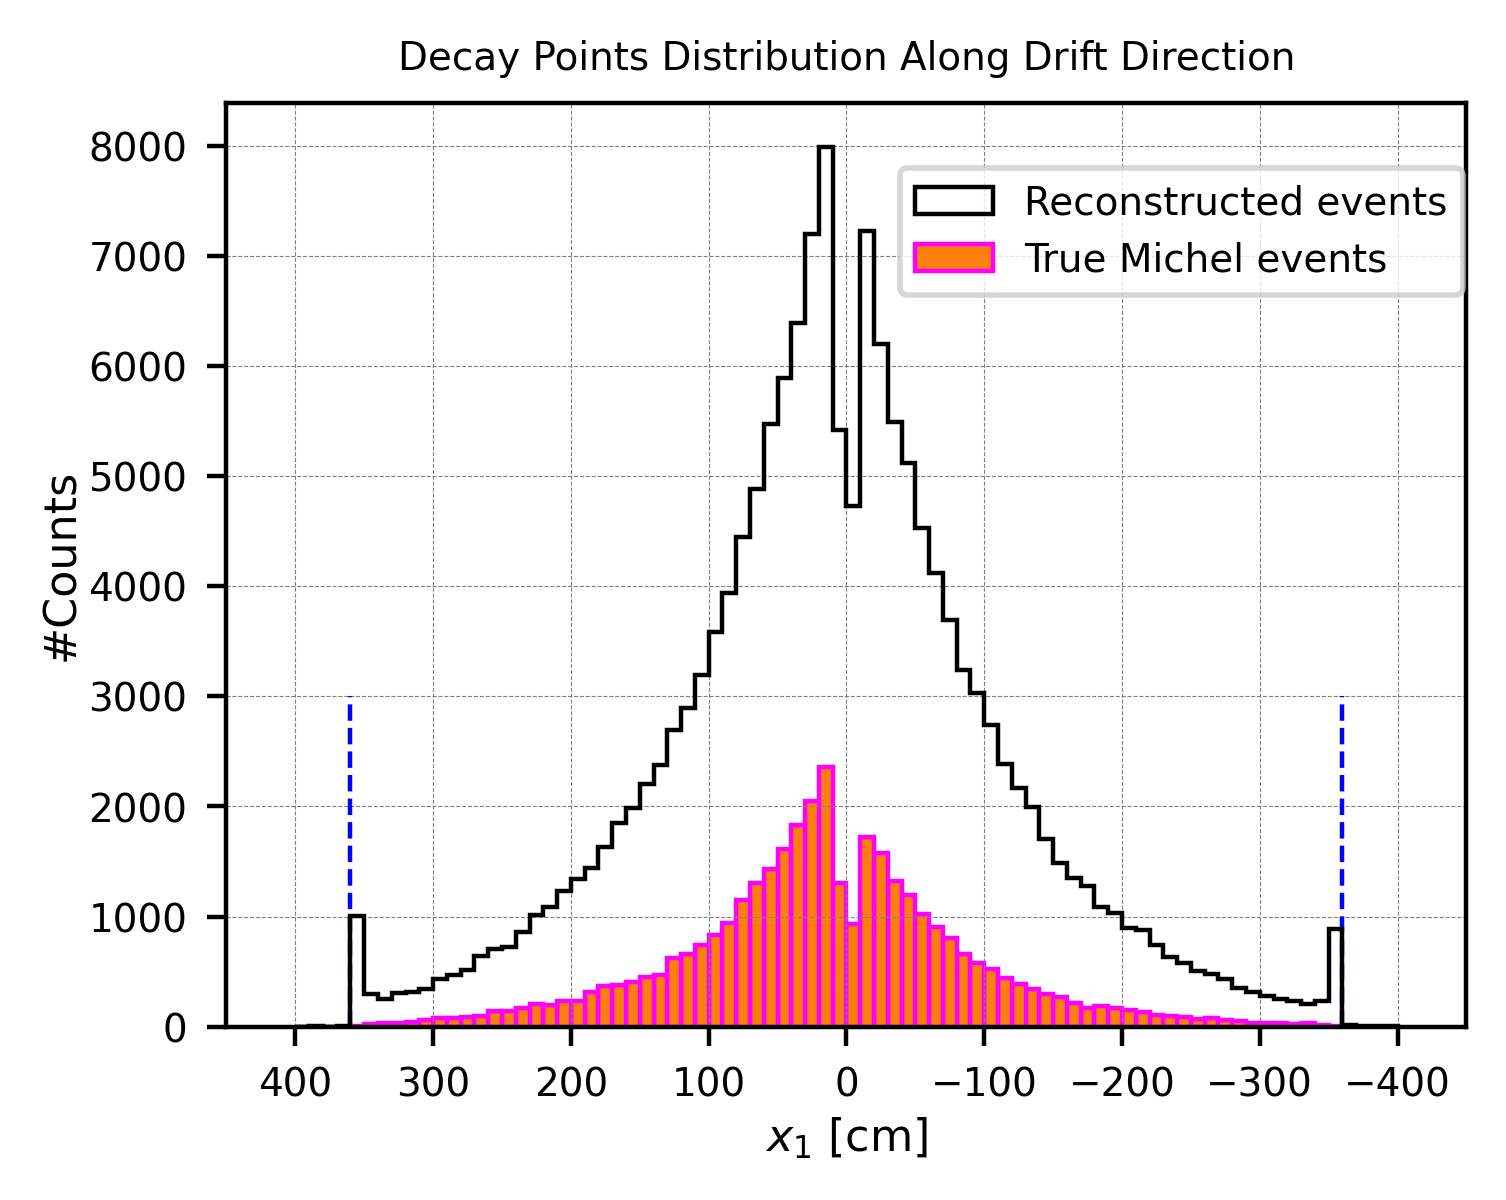

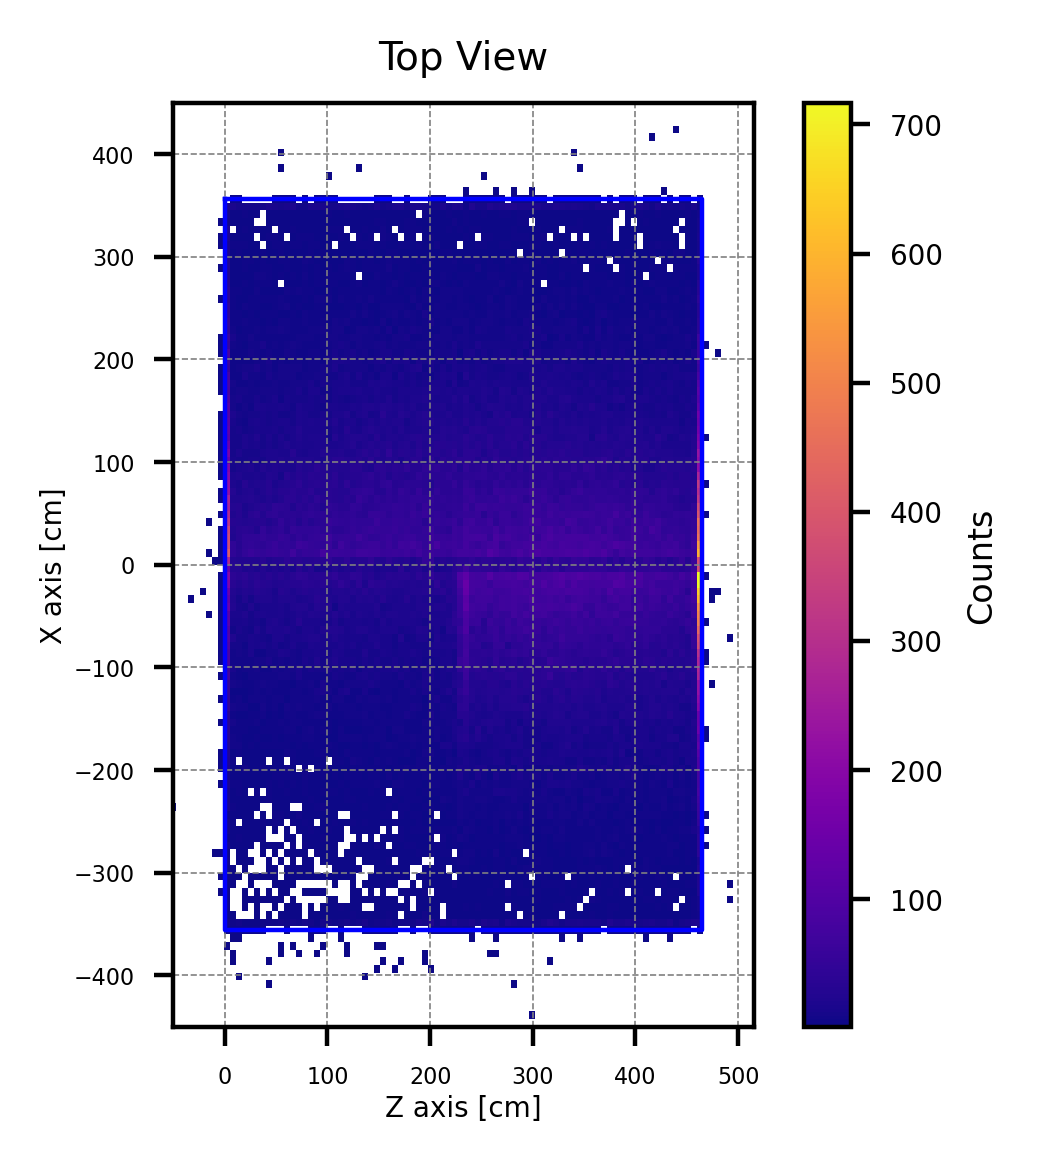

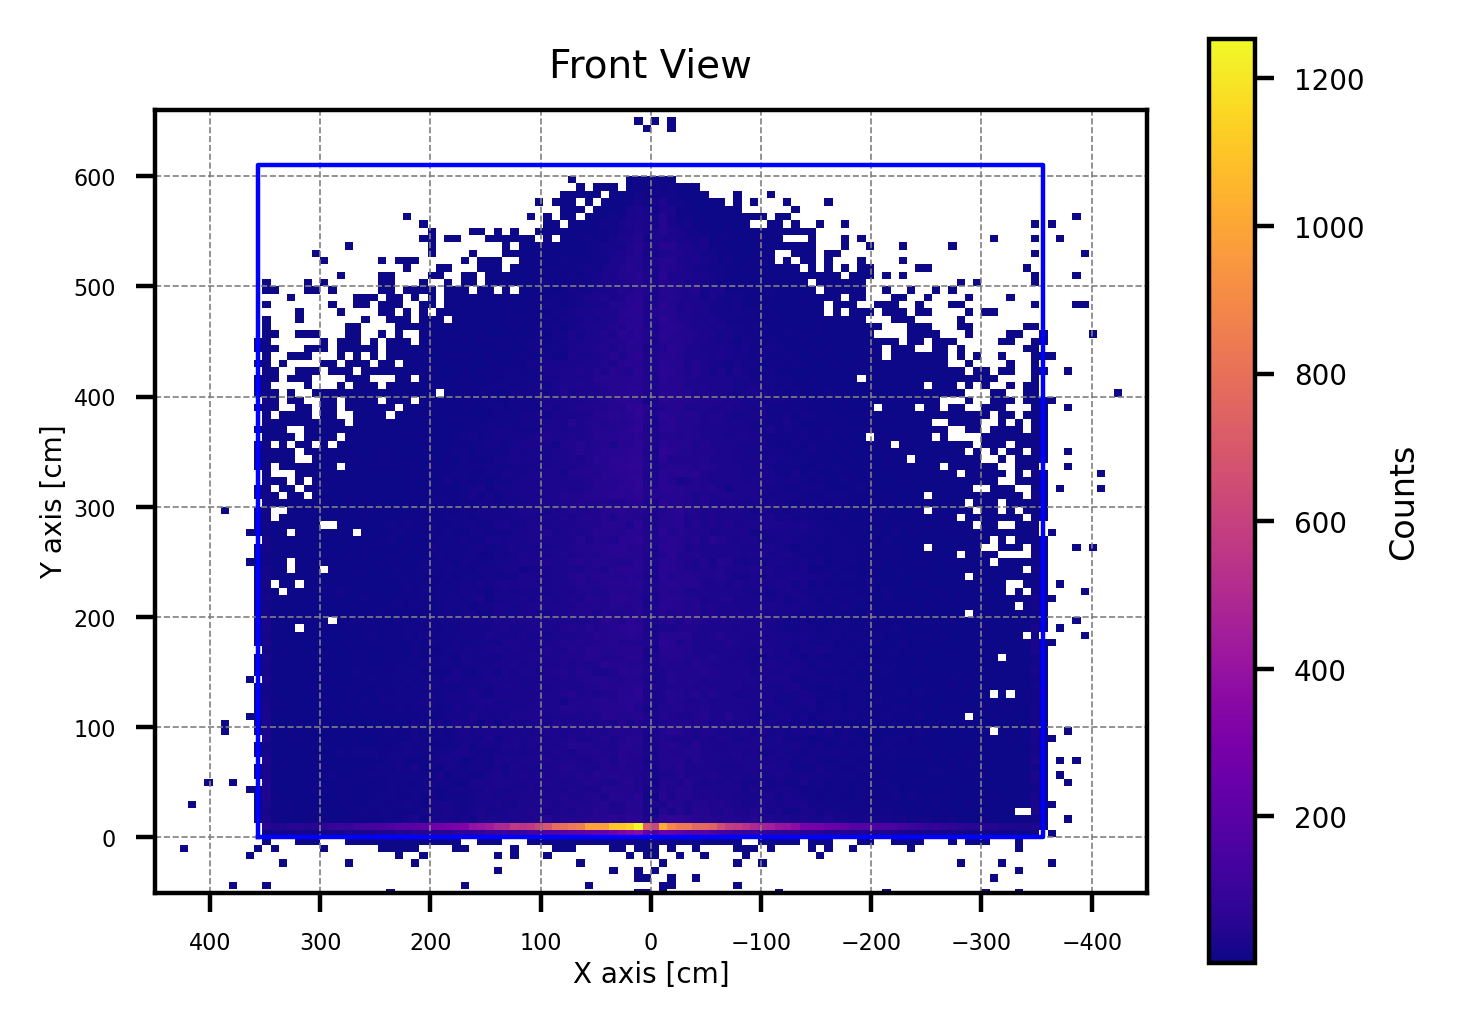

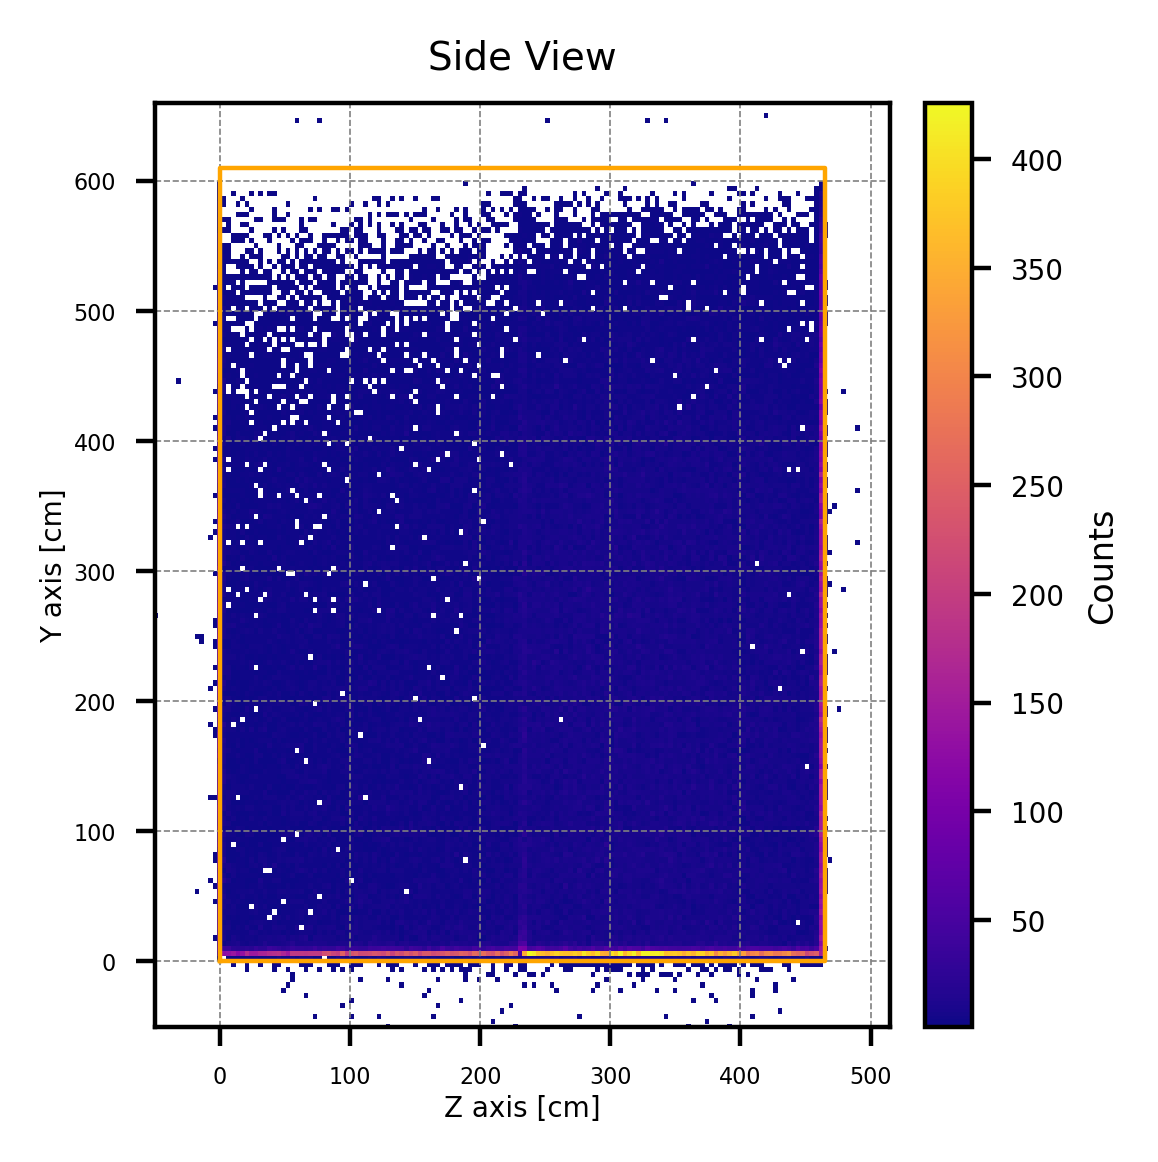


min(vals_MS_initial) 0.0100001
MS>0.1:  81632


<Figure size 1600x1200 with 0 Axes>

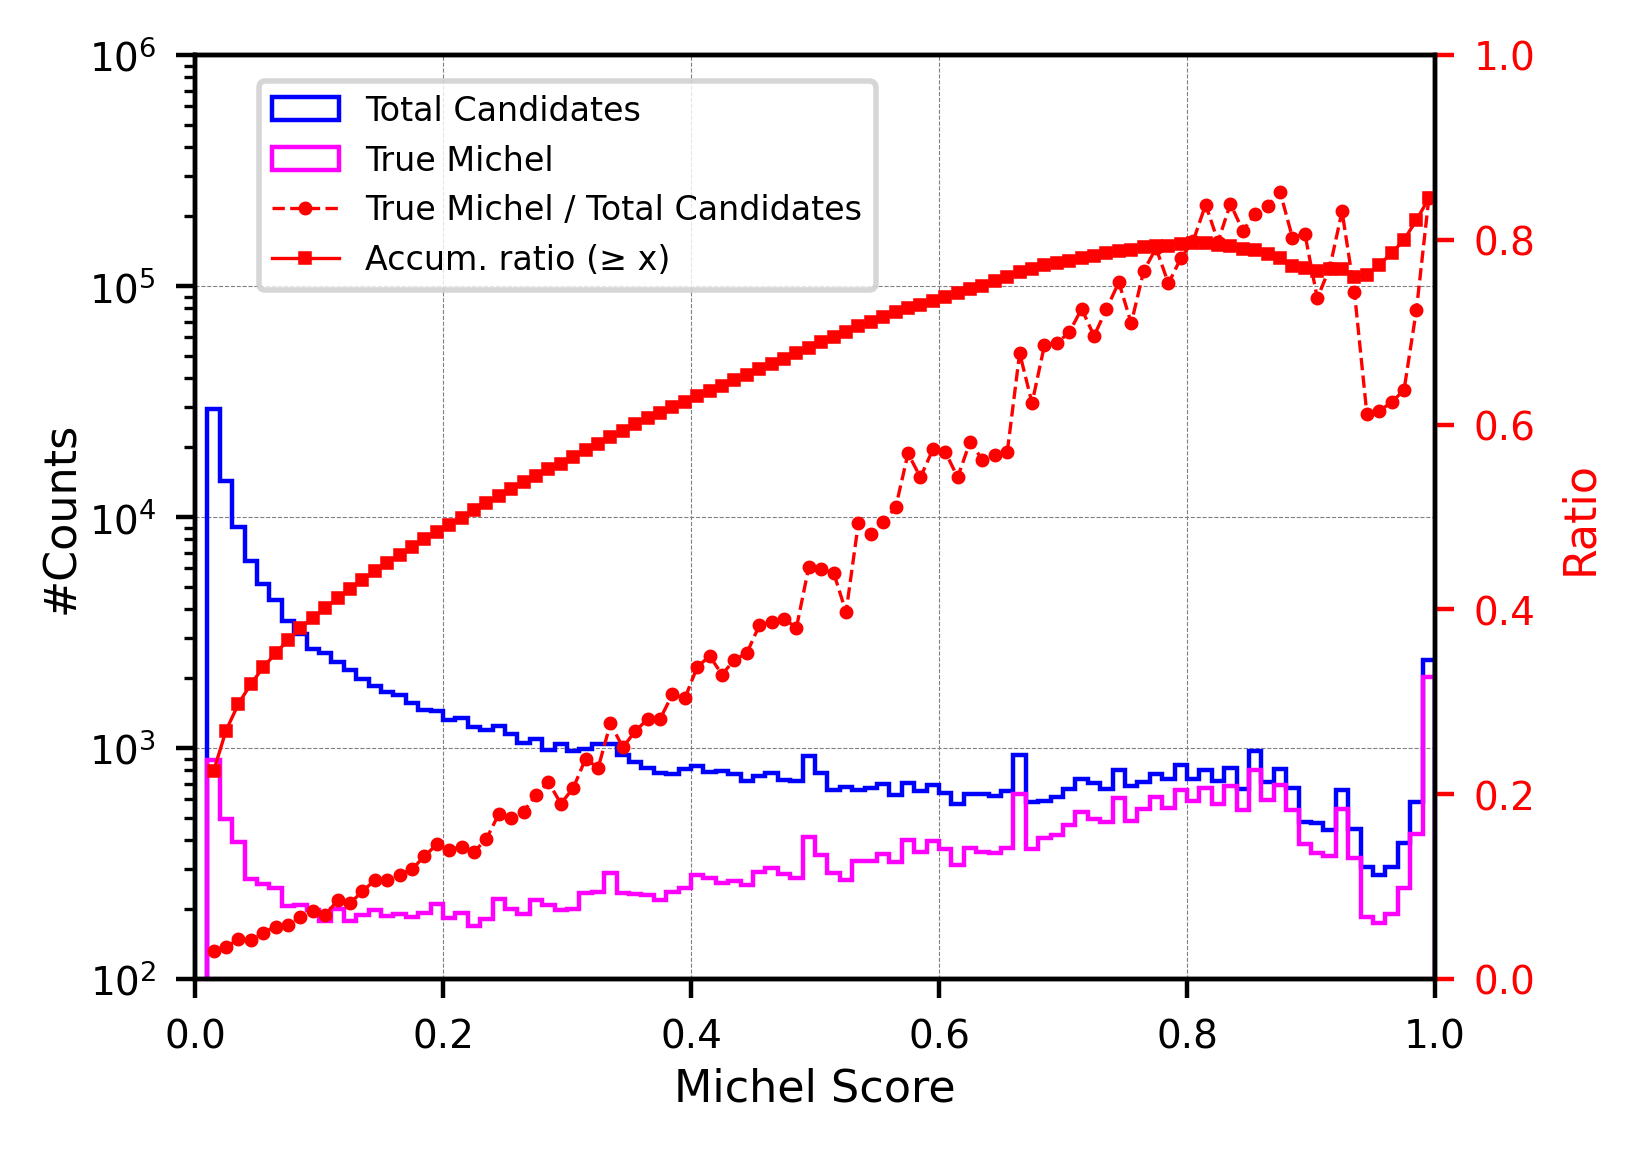

<Figure size 1600x1200 with 0 Axes>

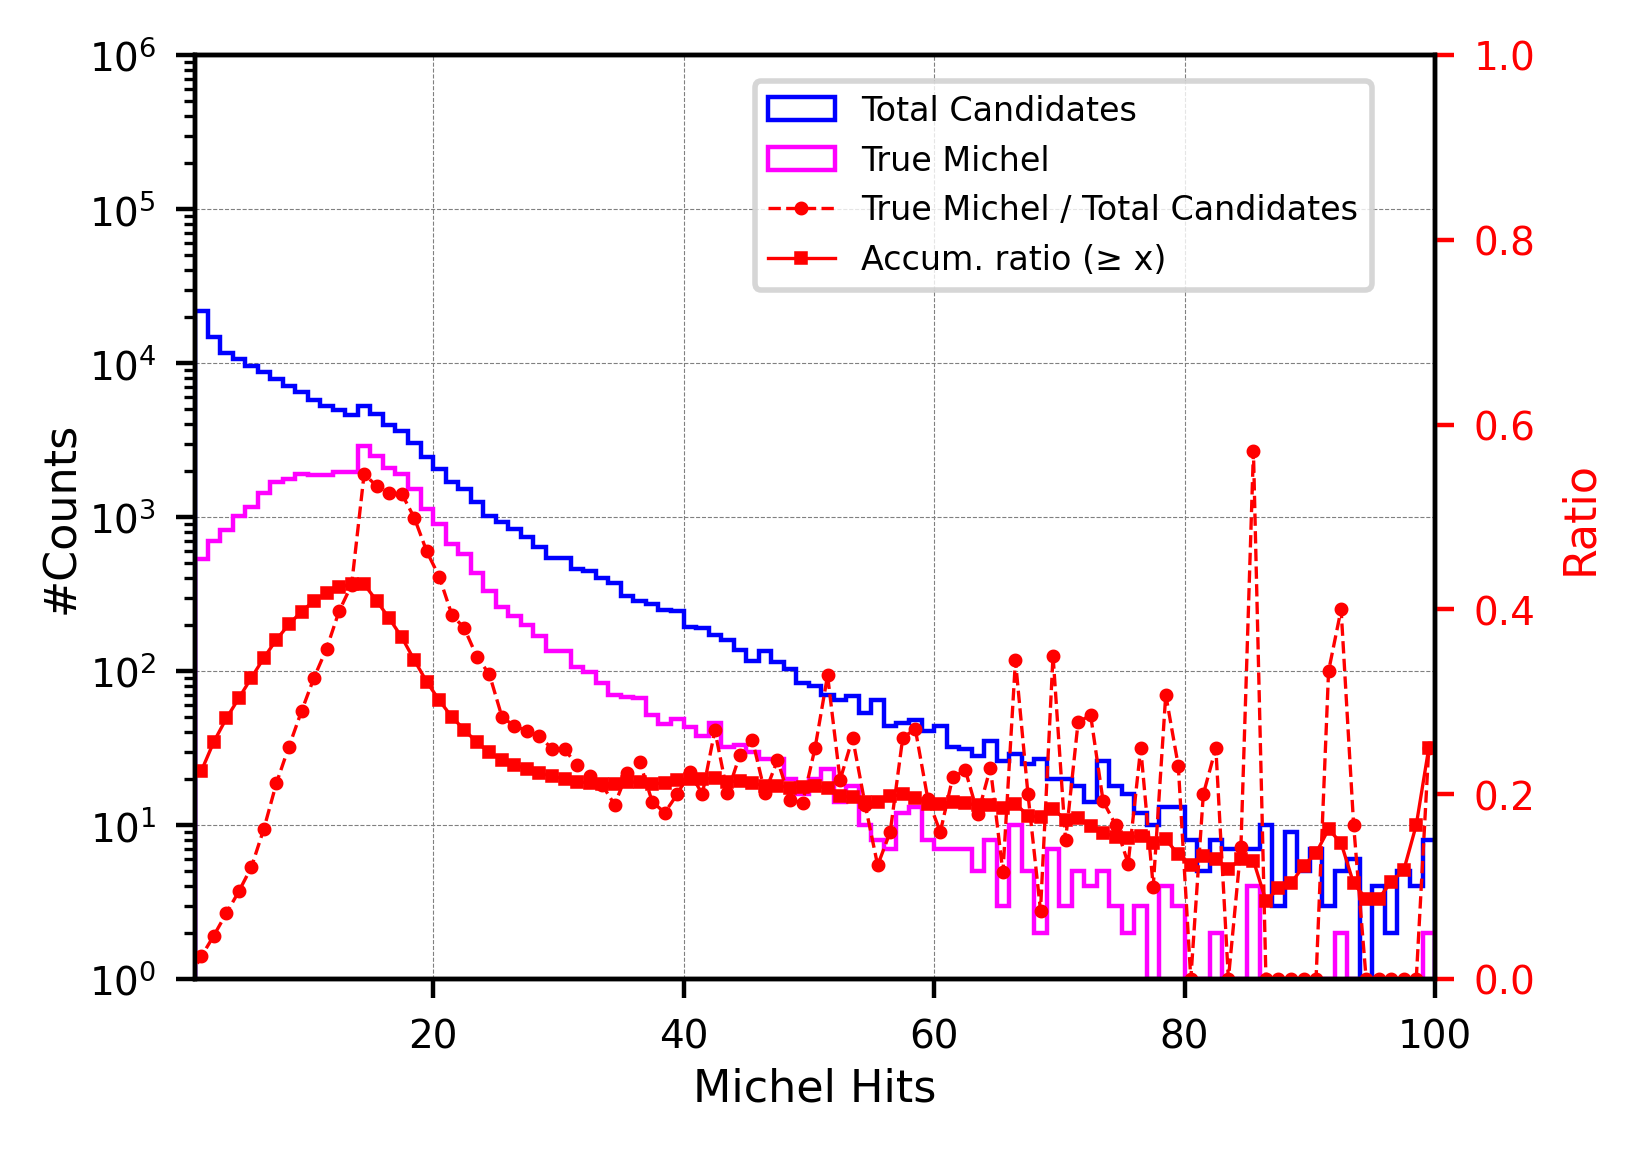

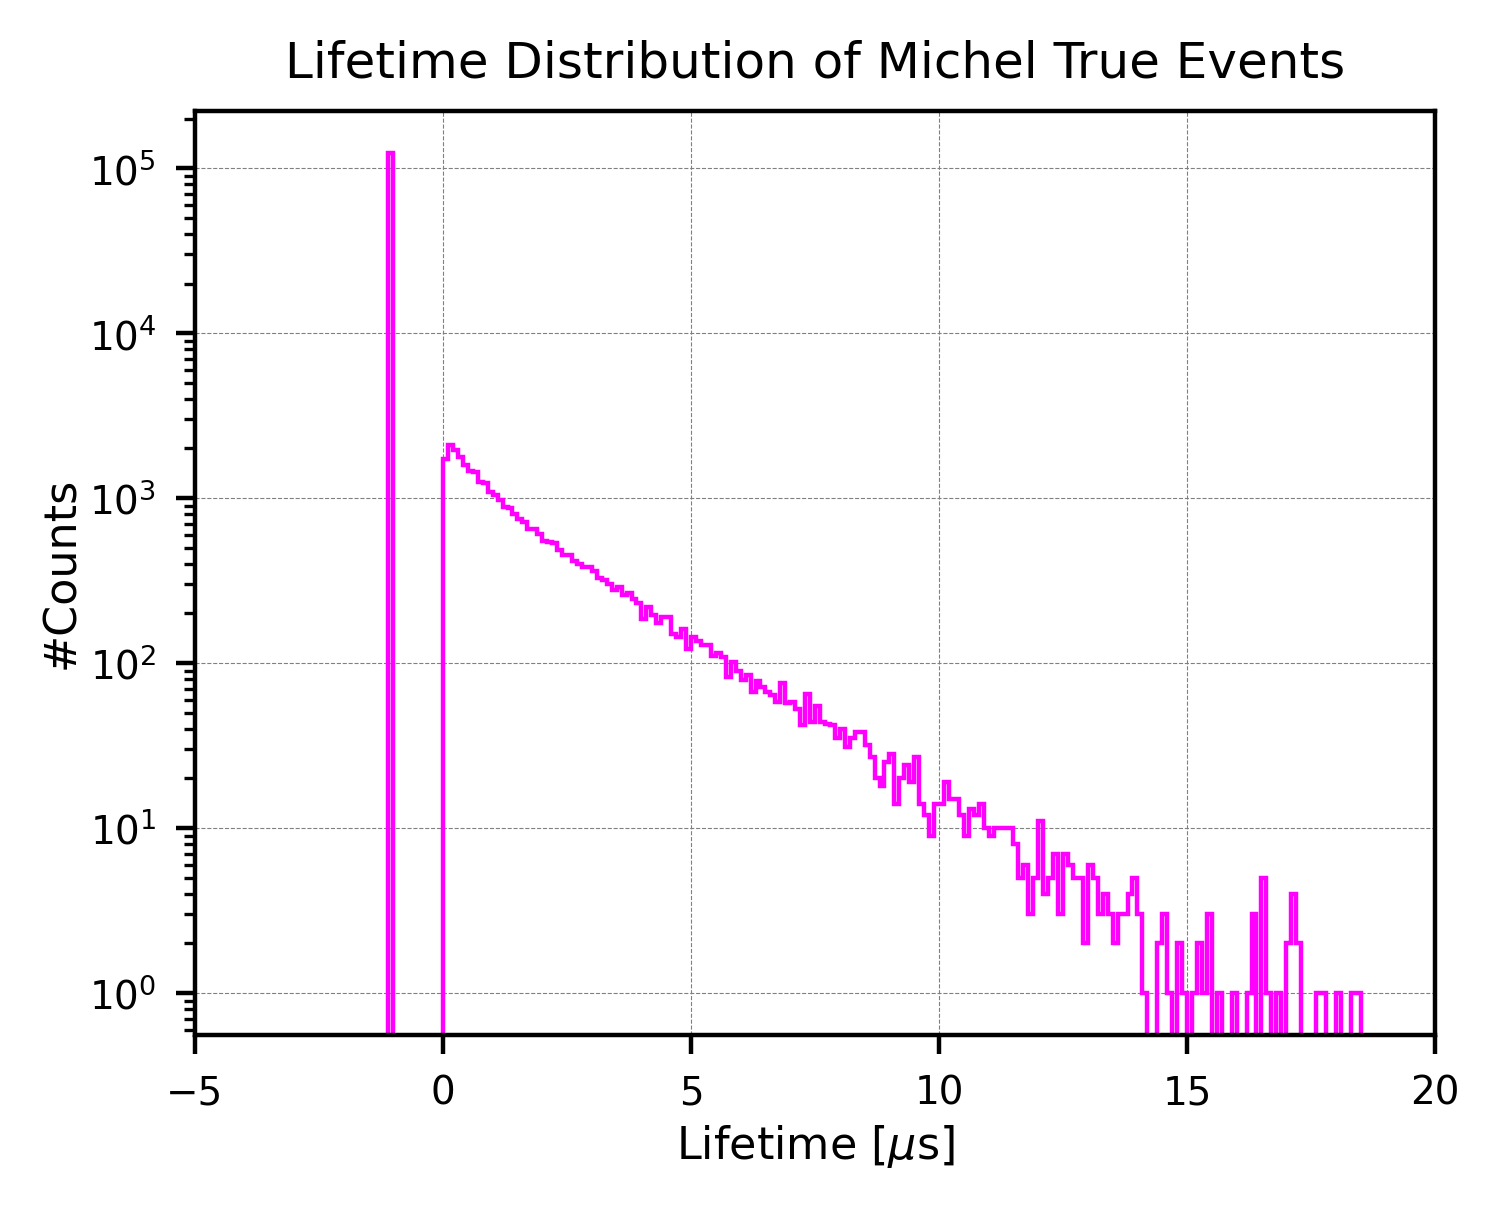

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]
vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco]

vals_decayX_true = [ev.decayX_initial for ev in events_true]
vals_MS_true = [ev.MS_initial for ev in events_true]
vals_MH_true = [ev.MH_initial for ev in events_true]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 30000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x > 0.1)
print("MS>0.1: ", count)



# Define the range and bin width
bin_width = 0.01
range_min = 0.01 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(0.0, 1.0) #(-0.02, 1.02)
ax1.set_ylim(100, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.00)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()









<br />
<br />
<br />
<br />
<br />

## Explore True-Michel distributions:

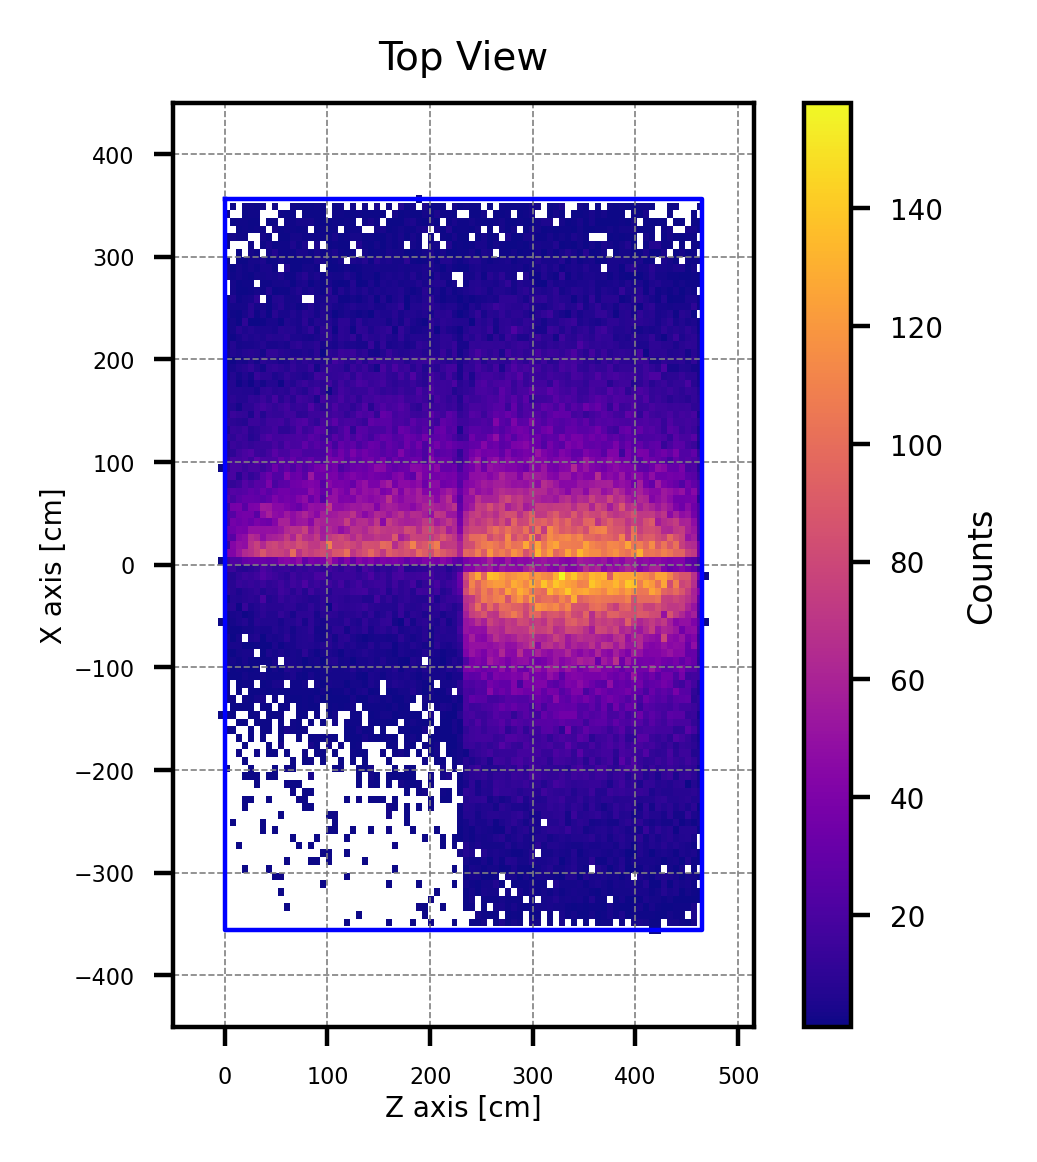

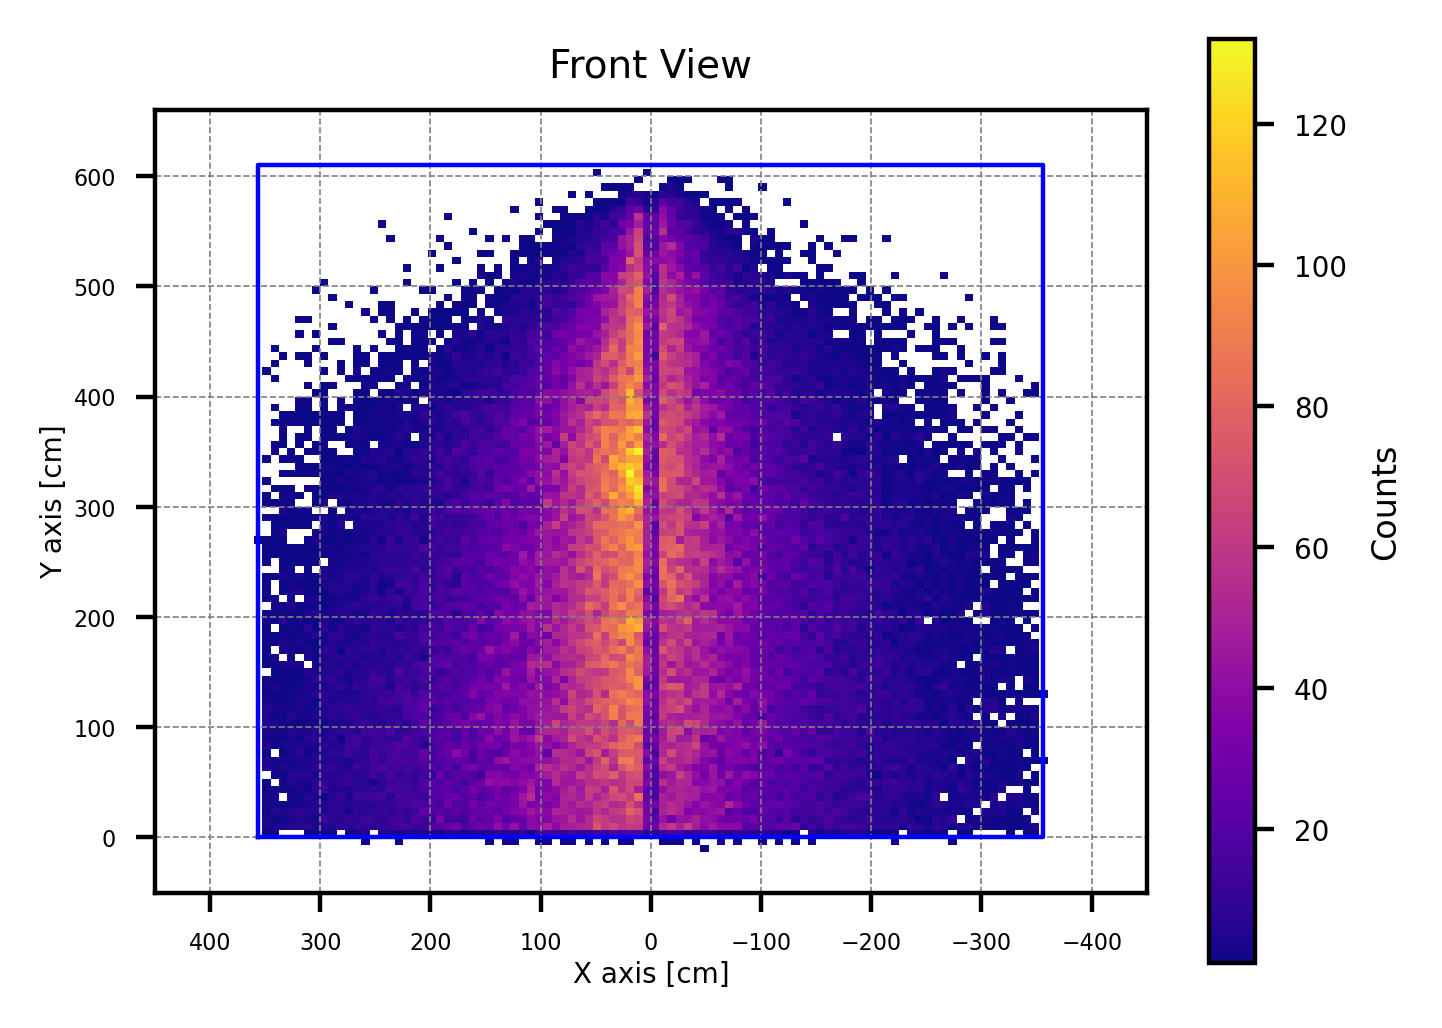

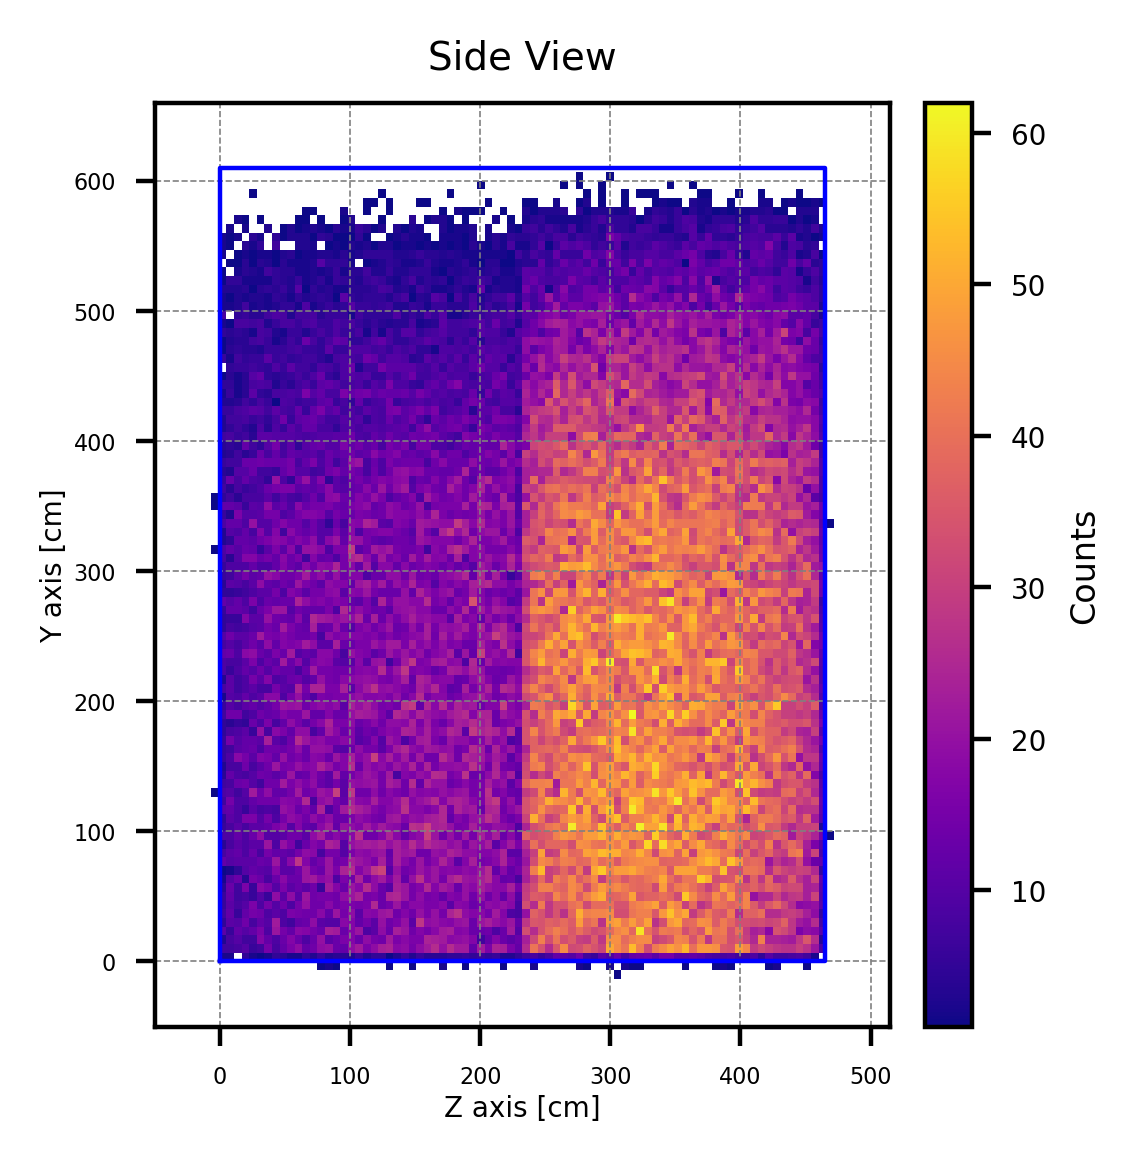

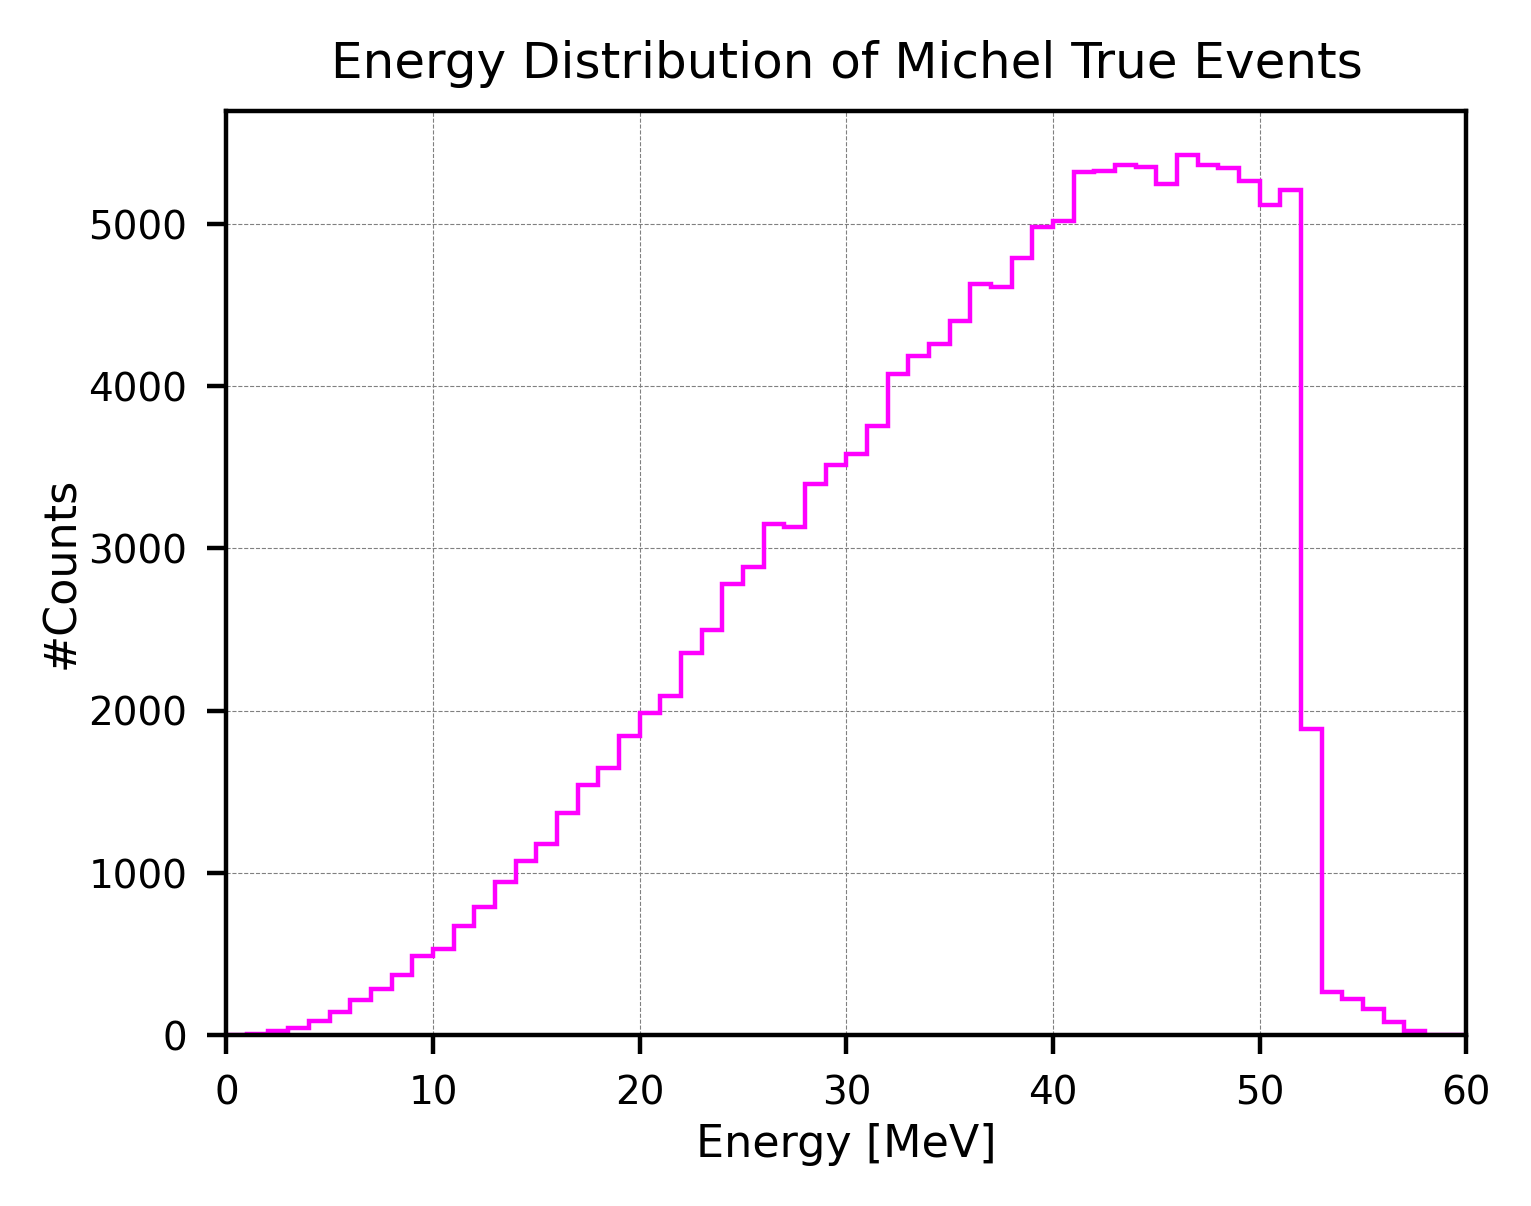

In [58]:
 
vals_decayY_true = [ev.decayY_initial for ev in events_true]
vals_decayZ_true = [ev.decayZ_initial for ev in events_true]
vals_energy_true = [ev.energy_initial for ev in events_true]


#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayX_true, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_true, vals_decayY_true, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayY_true, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  




<br />
<br />
<br />
<br />

## e^+ and e^- quick separation:

In [93]:
import math


# Seperate Michel e^- and e^+------------------------------
life_pM = []
life_nM = []
count_0= 0

events_pM = []#e^+---
events_nM = []

for i in range(0, len(events_true)):
    pdg = events_true[i].pdg_initial
    life = events_true[i].lifetime_initial

    if pdg < 0:
        life_pM.append(life)
        events_pM.append(events_true[i])

    elif pdg > 0:
        life_nM.append(life)
        events_nM.append(events_true[i])



print("\nMichel e^+: ", len(life_pM), "/", len(events_true), "({:.2f}%)".format(len(life_pM)/len(events_true)*100))
print("Michel e^-: ", len(life_nM), "/", len(events_true), "({:.2f}%)".format(len(life_nM)/len(events_true)*100))

print("\n#e^+ / #e^-: ", len(life_pM), "/", len(life_nM), 
      "({:.2f})".format(len(life_pM)/len(life_nM)))




Michel e^+:  123889 / 150372 (82.39%)
Michel e^-:  26483 / 150372 (17.61%)

#e^+ / #e^-:  123889 / 26483 (4.68)


<br />

### Michel e^+, e^- Enenrgy Distribution:

Reminder [20260415]: Make the spetrum difference for e^+ and e^- clear; decay in orbit can have MeV-scale effect?


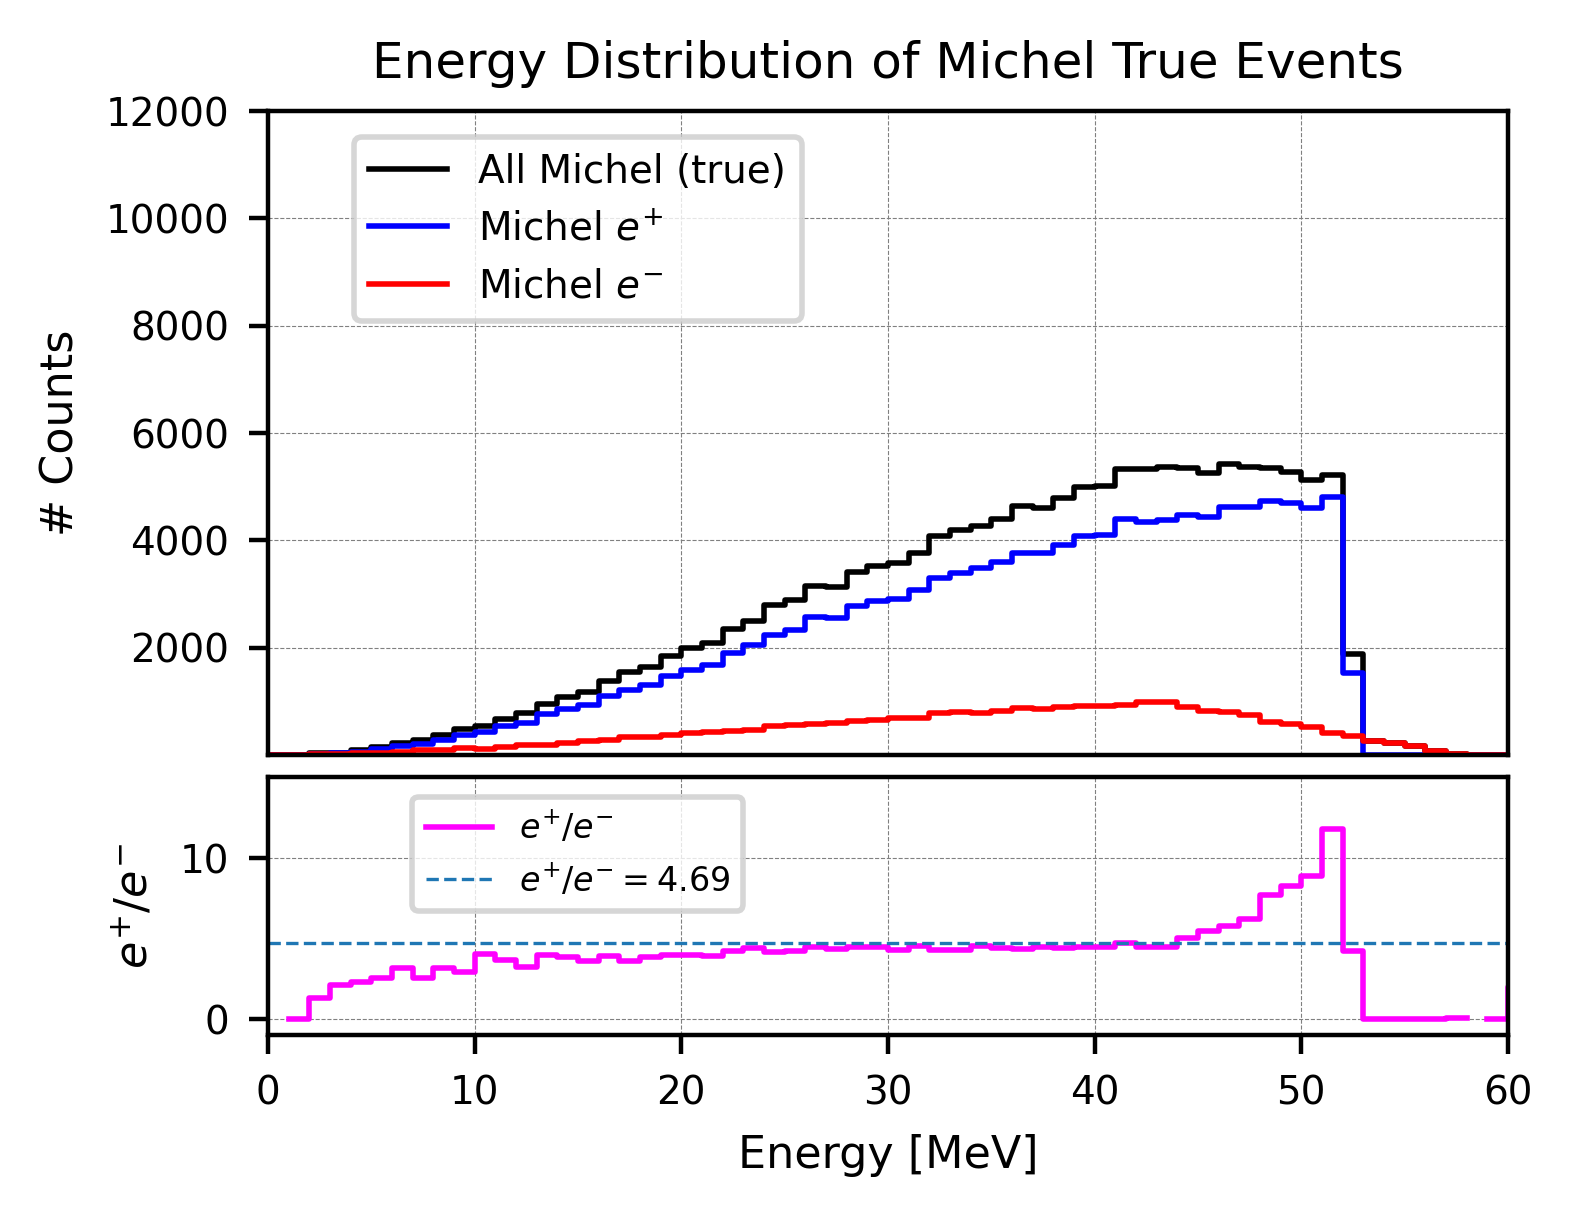

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

print("Reminder [20260415]: Make the spetrum difference for e^+ and e^- clear; decay in orbit can have MeV-scale effect?")

# -------------------------------------------------
# Prepare energy arrays
# -------------------------------------------------
vals_energy_total = np.array([ev.energy_initial for ev in events_true])
vals_energy_pM    = np.array([ev.energy_initial for ev in events_pM])
vals_energy_nM    = np.array([ev.energy_initial for ev in events_nM])

# -------------------------------------------------
# Binning
# -------------------------------------------------
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(bin_centers)

# Counts (explicit)
h_tot, _ = np.histogram(vals_energy_total, bins=bins)
h_pM,  _ = np.histogram(vals_energy_pM,    bins=bins)
h_nM,  _ = np.histogram(vals_energy_nM,    bins=bins)

# Ratio: e+ / e- (skip bins where e- == 0)
ratio = np.full(nb, np.nan, dtype=float)
mask = h_nM > 0
ratio[mask] = h_pM[mask] / h_nM[mask]

# -------------------------------------------------
# Figure: GridSpec two panels (like your lifetime script)
# -------------------------------------------------
fig = plt.figure(figsize=(4, 3), dpi=400)
gs = GridSpec(2, 1, height_ratios=[5, 2], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# -------------------------------------------------
# Top panel: step histograms (use step() so it matches bins exactly)
# -------------------------------------------------
ax_top.step(bins[:-1], h_tot, where='post', color='black', linewidth=1.0, label='All Michel (true)')
ax_top.step(bins[:-1], h_pM,  where='post', color='blue', linewidth=1.0, label='Michel $e^{+}$')
ax_top.step(bins[:-1], h_nM,  where='post', color='red', linewidth=1.0, label='Michel $e^{-}$')

ax_top.set_xlim(0, 60)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.set_ylim(0.9, 12000)
#ax_top.set_yscale('log')
ax_top.set_ylabel('# Counts', fontsize=8)
ax_top.tick_params(labelsize=7)
ax_top.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_top.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})
ax_top.set_title('Energy Distribution of Michel True Events', fontsize=9)



# -------------------------------------------------
# Bottom panel: ratio (step-mid to match histogram bins)
# -------------------------------------------------
ax_bot.plot(bin_centers, ratio, drawstyle='steps-mid', color='magenta', linewidth=1.0, label='$e^{+}/e^{-}$')
ax_bot.axhline(4.69, linestyle='--', linewidth=0.6, label='$e^{+}/e^{-} = 4.69$')

ax_bot.set_xlim(0, 60)
ax_bot.set_ylim(-1, 15)
ax_bot.set_xlabel('Energy [MeV]', fontsize=8)
ax_bot.set_ylabel('$e^{+}/e^{-}$', fontsize=8)
ax_bot.tick_params(labelsize=7)

ax_bot.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_bot.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=6, markerscale=4, ncol=1, prop={'size':6})


plt.show()


<br />
<br />
<br />
<br />
<br />

## True lifetime fitting:


#### Pure Histogram Drawing and Printing:

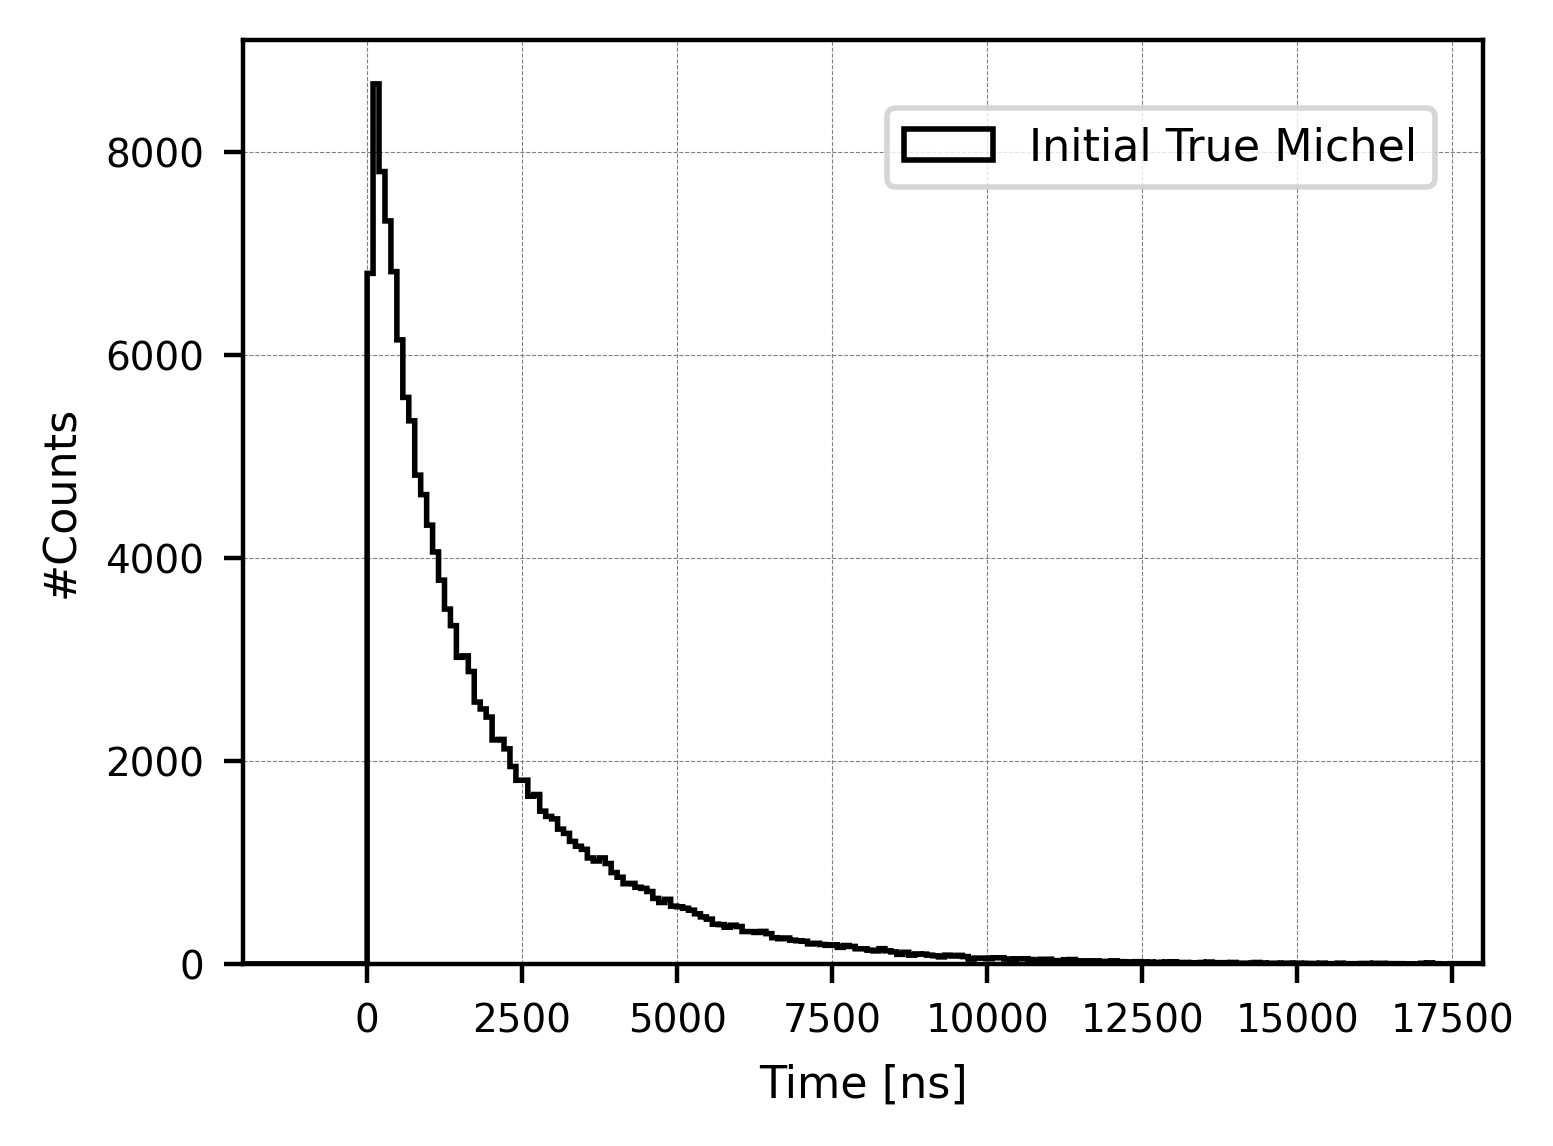

Center =   -95952 ns,  Count =      0
Center =   -95856 ns,  Count =      0
Center =   -95760 ns,  Count =      0
Center =   -95664 ns,  Count =      0
Center =   -95568 ns,  Count =      0
Center =   -95472 ns,  Count =      0
Center =   -95376 ns,  Count =      0
Center =   -95280 ns,  Count =      0
Center =   -95184 ns,  Count =      0
Center =   -95088 ns,  Count =      0
Center =   -94992 ns,  Count =      0
Center =   -94896 ns,  Count =      0
Center =   -94800 ns,  Count =      0
Center =   -94704 ns,  Count =      0
Center =   -94608 ns,  Count =      0
Center =   -94512 ns,  Count =      0
Center =   -94416 ns,  Count =      0
Center =   -94320 ns,  Count =      0
Center =   -94224 ns,  Count =      0
Center =   -94128 ns,  Count =      0
Center =   -94032 ns,  Count =      0
Center =   -93936 ns,  Count =      0
Center =   -93840 ns,  Count =      0
Center =   -93744 ns,  Count =      0
Center =   -93648 ns,  Count =      0
Center =   -93552 ns,  Count =      0
Center =   -

In [61]:
lifetime_trueMichel_initial = [ev.lifetime_initial*1000 for ev in events_true]


# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 96 # Advice 202602-----------------
range_min = -96000
range_max = 96000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_trueMichel_initial, bins=bins, range=(range_min, range_max),
         edgecolor='black', histtype='step', linewidth=1.0,
         label='Initial True Michel')


plt.xlim(-2000, 18000)
#plt.ylim(0, 500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()




# Bin content printing-----------------------
counts, bin_edges = np.histogram(
    lifetime_trueMichel_initial,
    bins=bins,
    range=(range_min, range_max)
)

# Compute bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Print line by line
for i in range(len(counts)):
    print(f"Center = {bin_centers[i]:8.0f} ns,  Count = {counts[i]:6d}")
# -------------------------------------------

# -------------------------------------------
# Save the list---
np.save("trueMichel_initial.npy", lifetime_trueMichel_initial)
print("\n\nLength of trueMichel_initial: ", len(lifetime_trueMichel_initial))
# -------------------------------------------

<br />
<br />

### Bin-integrated fittings (For general decay-rate model): (Best 202510):

##### The initial formula: 
$$
f(t) = \frac{N}{\tau} e^{-t/\tau}
$$
Here:
- $N$ = total number of decays (normalization),
- $\tau$ = lifetime,
- $f(t)\times dt$ = expected number of decays in time interval $dt$.

#### Expected number of decays in a bin $[a,b]$:
$$
\mu(a,b)
= \int_a^b \frac{N}{\tau} e^{-t/\tau}\, dt
= N \left( e^{-a/\tau} - e^{-b/\tau} \right) 
$$



<br />
<br />

### Seperate Fittings:

======E P Counting (lifetime > thre)==================
# Michel e^+ & e^-: 150372
# Michel e^+ / e^-: 123889 / 26483 (467.81%)

========== e⁺ Minuit fit summary ==========
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 96.45 (χ²/ndof = 1.0)      │              Nfcn = 43               │
│ EDM = 7.92e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate    

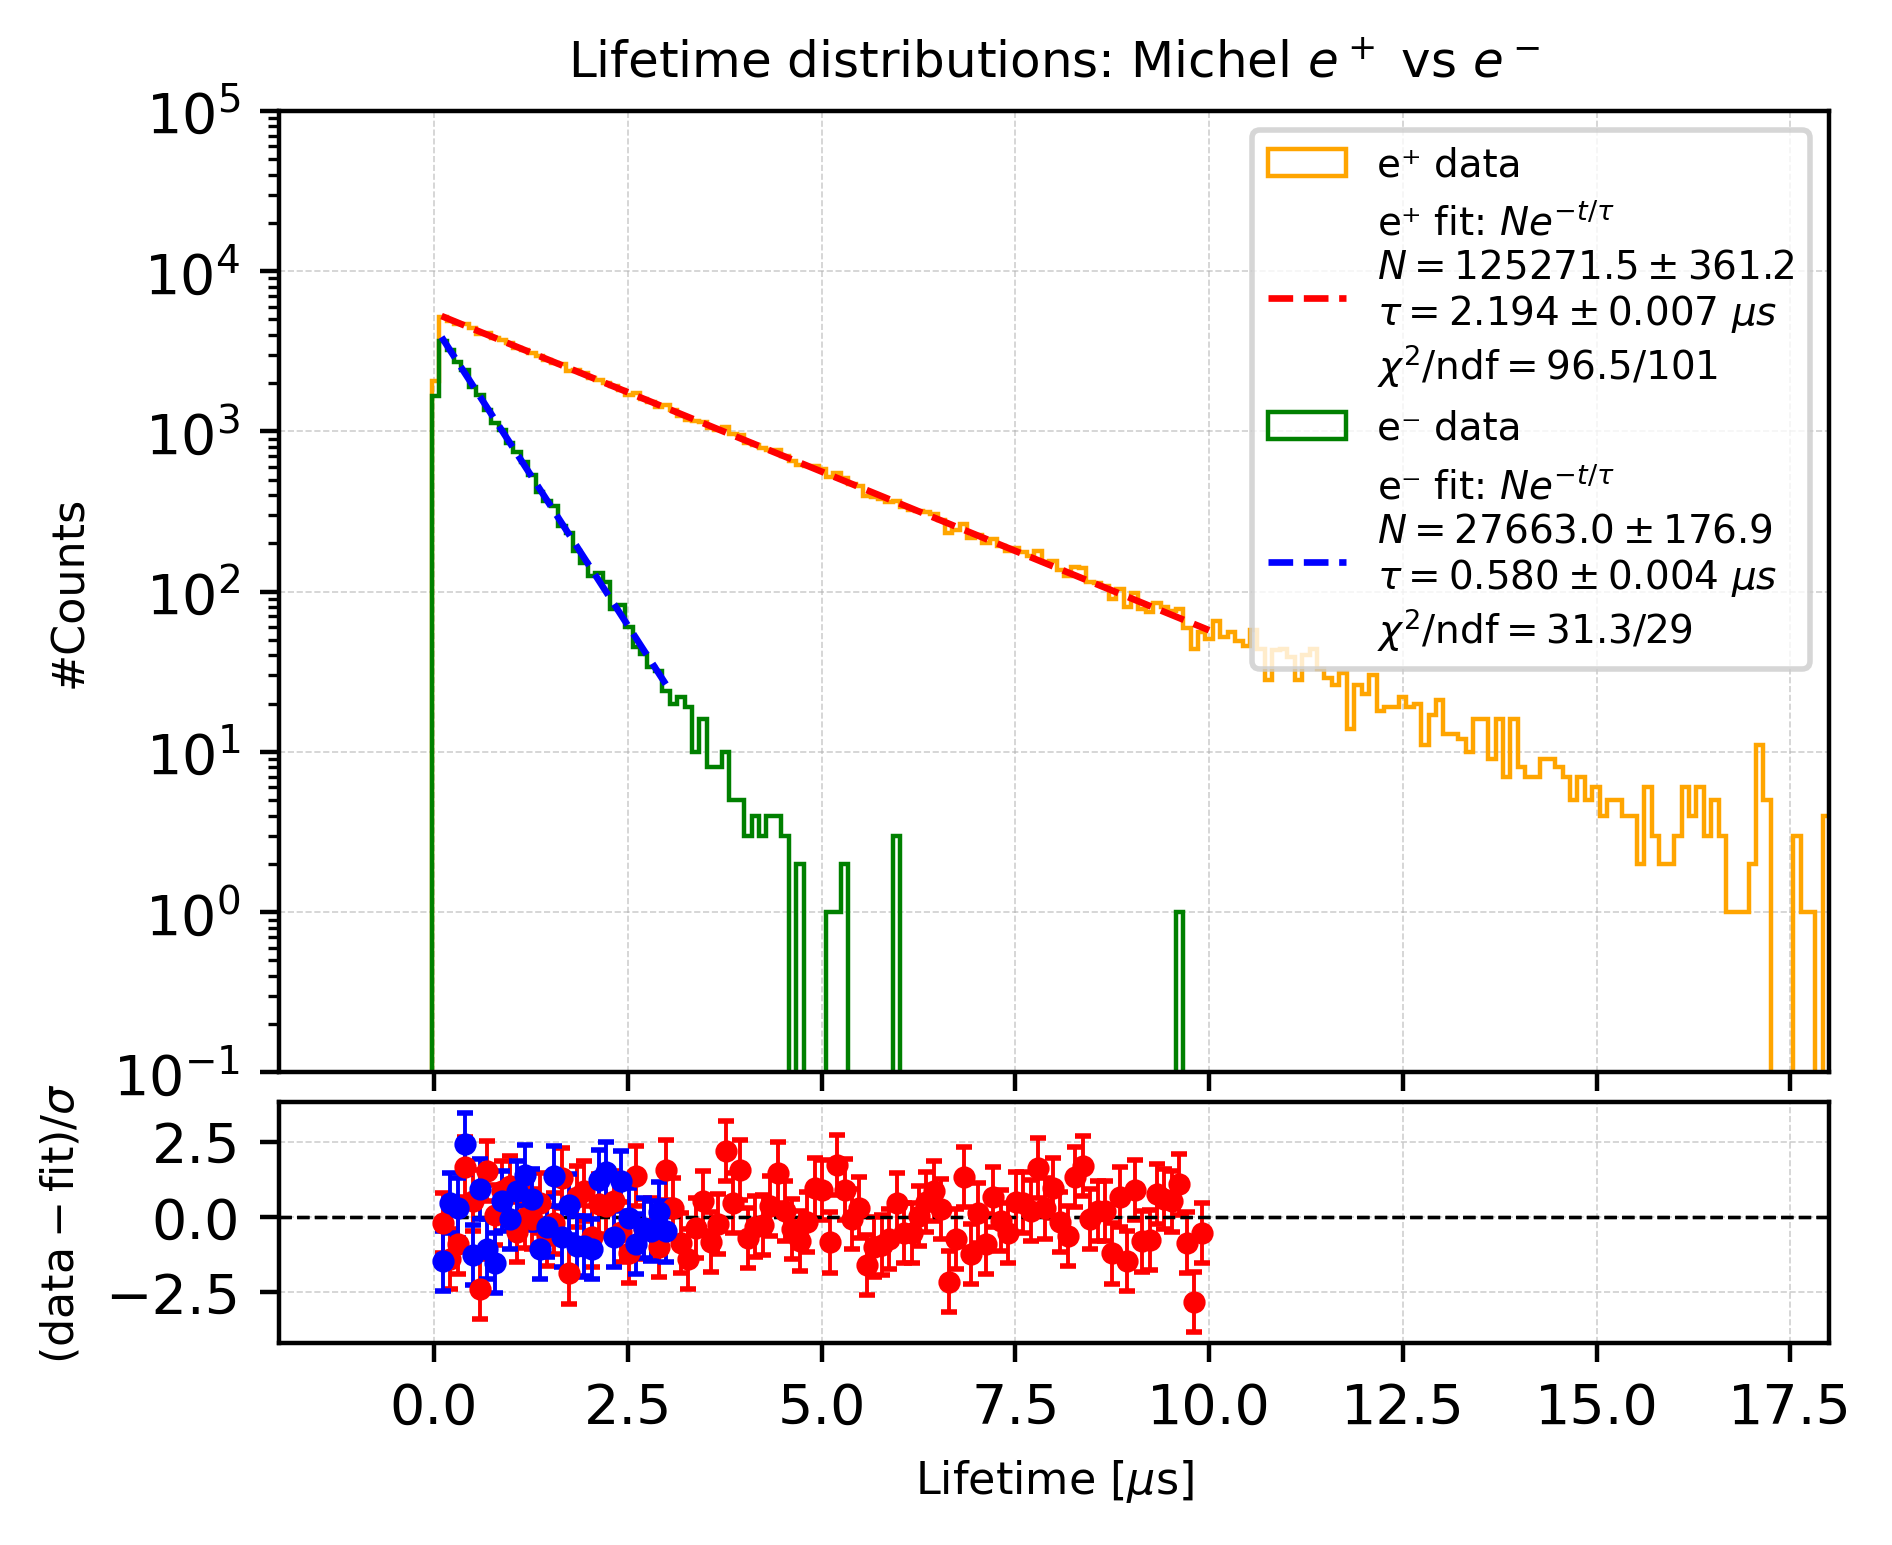

In [99]:
from iminuit import Minuit
from iminuit.cost import LeastSquares
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# Counting of e^+ and e^- under different lifetime cuts
# ==========================================================
thre_count = 0.0   # in unit of us
pM_over_thre = sum(1 for x in life_pM if x > thre_count)
nM_over_thre = sum(1 for x in life_nM if x > thre_count)

print("======E P Counting (lifetime > thre)==================")
print("# Michel e^+ & e^-:", (pM_over_thre + nM_over_thre))
print("# Michel e^+ / e^-:",
      pM_over_thre, "/", nM_over_thre,
      "({:.2f}%)".format(pM_over_thre / nM_over_thre * 100))


# ==========================================================
# Configuration
# ==========================================================
bin_width = 0.096
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)


# ==========================================================
# Bin-integrated model
# ==========================================================
def exp1_integrated(bin_edges, N, tau):
    """
    Expected counts per bin for exponential decay model.

    Model:
        f(t) = (N / tau) * exp(-t / tau)

    Bin expectation in [a, b]:
        mu(a, b) = N * (exp(-a / tau) - exp(-b / tau))

    Parameters
    ----------
    bin_edges : array
        Array of bin edges, length = n_bins + 1
    N : float
        Total normalization
    tau : float
        Lifetime in us

    Returns
    -------
    array
        Expected counts in each bin
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


def exp1_integrated_from_leftedge(x_left, N, tau):
    """
    Wrapper for LeastSquares.

    Here x_left is the LEFT edge of each selected bin.
    Since each bin has width = bin_width, the expected count is

        mu = N * (exp(-a/tau) - exp(-(a + bin_width)/tau))
    """
    a = np.asarray(x_left)
    b = a + bin_width
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


# ==========================================================
# Minuit fitting helper
# ==========================================================
def fit_and_draw(ax, ax_resid, sample, label_prefix,
                 fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # -----------------------------
    # Histogram
    # -----------------------------
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Full histogram draw
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8,
            label=f"{label_prefix} data", color=hist_color)

    # -----------------------------
    # Fit window
    # -----------------------------
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])

    if np.count_nonzero(m) < 3:
        return None

    x_center = centers[m]
    y = counts[m]

    # Convert chosen bins to left edges
    x_left = x_center - 0.5 * bin_width

    # Poisson-like display uncertainty, same as your old script
    sigma = np.sqrt(np.maximum(y, 1.0))

    # -----------------------------
    # Least-squares cost for Minuit
    # -----------------------------
    lsq = LeastSquares(x_left, y, sigma, exp1_integrated_from_leftedge)

    # Initial values
    N0 = np.sum(y)
    tau0 = 2.0

    mfit = Minuit(lsq, N=N0, tau=tau0)

    # Parameter limits
    mfit.limits["N"] = (0.0, None)
    mfit.limits["tau"] = (1e-6, None)

    # Optional stability settings
    mfit.errordef = Minuit.LEAST_SQUARES

    # Minimize
    mfit.migrad()
    mfit.hesse()

    # If needed later:
    # mfit.minos("tau")

    if not mfit.valid:
        print(f"[WARNING] Fit for {label_prefix} is not fully valid.")

    # -----------------------------
    # Fit results
    # -----------------------------
    N_fit = mfit.values["N"]
    tau_fit = mfit.values["tau"]

    N_err = mfit.errors["N"]
    tau_err = mfit.errors["tau"]

    # Model values at fitted bins
    y_model = exp1_integrated_from_leftedge(x_left, N_fit, tau_fit)

    # Pulls
    pulls = (y - y_model) / sigma

    # Chi2 / ndf
    chi2 = mfit.fval
    ndf = len(y) - mfit.nfit

    # -----------------------------
    # Smooth curve for visualization
    # -----------------------------
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau_fit) * np.exp(-x_smooth / tau_fit) * bin_width

    # -----------------------------
    # Draw fit curve
    # -----------------------------
    ax.plot(
        x_smooth, y_smooth,
        color=fit_color, linestyle="--", linewidth=1.2,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
               + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    # -----------------------------
    # Residuals / pulls
    # -----------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        x_center, pulls, yerr=np.ones_like(pulls), fmt='o',
        color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # -----------------------------
    # Print summary
    # -----------------------------
    print("")
    print(f"========== {label_prefix} Minuit fit summary ==========")
    print(mfit)
    print("")
    print("Covariance matrix:")
    print(mfit.covariance)
    print("")

    return tau_fit, tau_err, chi2, ndf


# ==========================================================
# Plot with residual panel
# ==========================================================
fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+
fit_and_draw(
    ax, ax_resid,
    np.asarray(life_pM),
    "e⁺",
    fit_range=(0.096, 10.0),
    hist_color="orange",
    fit_color="red"
)

# Fit e-
fit_and_draw(
    ax, ax_resid,
    np.asarray(life_nM),
    "e⁻",
    fit_range=(0.096, 3.0),
    hist_color="green",
    fit_color="blue"
)

# ==========================================================
# Style top plot
# ==========================================================
ax.set_ylim(0.1, 100000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# ==========================================================
# Style residuals
# ==========================================================
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />
<br />


### Initial  Decay model and integrated formulism:
$$
f(t) = \frac{N}{\tau_1} e^{-t/\tau_1} \;+\; \frac{N r}{\tau_2} e^{-t/\tau_2}
$$

#### For bin [a, b]:
$$
\mu(a,b) = 
N \left( e^{-a/\tau_1} - e^{-b/\tau_1} \right)
+ N r \left( e^{-a/\tau_2} - e^{-b/\tau_2} \right)
$$

<br />

### Combined fitting (fluctuating $r$) (Current MAIN result):

##### minuit minimization model applied


In [64]:
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare sample
# ============================================================
lifetime_trueMichel_initial = [ev.lifetime_initial * 1000 for ev in events_true]


# ============================================================
# 3. Define model and fitting helper
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    """
    Expected bin counts for the model:
        f(t) = N * [ exp(-t/tau1)/tau1 + ratio * exp(-t/tau2)/tau2 ]
    Integrated over each bin [a,b]:
        mu = N * [ (e^{-a/tau1} - e^{-b/tau1}) + ratio*(e^{-a/tau2} - e^{-b/tau2}) ]
    Here N is the normalization of the PDF component (not simply total counts).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)


#### Previous Least Square Fitting method:

In [66]:
# Default Least Square Fitting---

def fit_and_draw(ax, ax_resid, sample, label_prefix,
                 fit_range=(400, 10000),
                 hist_color="black", fit_color="red",
                 ratio_init=4.0, tau2=2197.0,
                 print_chi2_per_bin=True, top_bins=15):
    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m]
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]
    sigma = np.sqrt(np.maximum(y, 1.0))

    # Initial guesses
    N0 = np.sum(y)
    tau1_0 = 500.0
    ratio_0 = ratio_init

    # Fit (ratio free, tau2 fixed)
    popt, pcov = curve_fit(
        lambda edges, N, tau1, ratio: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y,
        p0=[N0, tau1_0, ratio_0],
        sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf])
    )
    N_fit, tau1_fit, ratio_fit = popt
    N_err, tau1_err, ratio_err = np.sqrt(np.diag(pcov))

    # χ² / ndf
    y_model = exp2_integrated(edges_fit, *popt, tau2=tau2)
    pulls = (y - y_model) / sigma
    chi2_bins = pulls**2
    chi2 = np.sum(chi2_bins)
    ndf = len(y) - len(popt)

    # --- NEW: print chi2 contribution per bin ---
    if print_chi2_per_bin:
        # reconstruct the x/edges for the fitted bins
        fit_idx = np.where(m)[0]                 # indices into the full histogram bins
        fit_centers = centers[m]                 # centers for fitted bins
        left_edges = bin_edges[fit_idx]
        right_edges = bin_edges[fit_idx + 1]

        print(f"\n[{label_prefix}] Per-bin χ² contributions (fit window only):")
        print("  idx   [left, right]      center    n_i     mu_i    sigma    pull     chi2_i")
        for k in range(len(y)):
            print(f"  {k:3d}  [{left_edges[k]:7.1f},{right_edges[k]:7.1f}]"
                  f"  {fit_centers[k]:7.1f}  {y[k]:6.0f}  {y_model[k]:7.2f}  {sigma[k]:6.2f}"
                  f"  {pulls[k]:7.2f}  {chi2_bins[k]:8.3f}")

        # also show the top contributors
        order = np.argsort(chi2_bins)[::-1]
        nshow = min(top_bins, len(order))
        print(f"\n[{label_prefix}] Top {nshow} bins by χ² contribution:")
        for rank in range(nshow):
            k = order[rank]
            print(f"  #{rank+1:2d}: idx={k:3d}  center={fit_centers[k]:7.1f} ns"
                  f"  n={y[k]:.0f}  mu={y_model[k]:.2f}  pull={pulls[k]:.2f}  chi2_i={chi2_bins[k]:.3f}")

        print(f"\n[{label_prefix}] Sum χ² over fit bins = {chi2:.3f} (ndf={ndf})")

    # Smooth curve for visualization
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_fast = (N_fit / tau1_fit) * np.exp(-x_smooth / tau1_fit) * bin_width
    y_slow = (N_fit * ratio_fit / tau2) * np.exp(-x_smooth / tau2) * bin_width
    y_smooth = y_fast + y_slow

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    ax.plot(x_smooth, y_smooth,
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.1f}\pm{ratio_err:.1f}$" + "\n"
                   + rf"$\tau_2={tau2}$ ns (fixed)" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"))

    # components
    ax.plot(x_smooth, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"{label_prefix} fast: $(N/\tau_1)e^{{-t/\tau_1}}$")

    ax.plot(x_smooth, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"{label_prefix} slow: $(Nr/\tau_2)e^{{-t/\tau_2}}$")

    # Residuals
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results:")
    print(f"    τ₁ = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r  = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    χ²/ndf = {chi2:.1f}/{ndf}")

    return tau1_fit, tau1_err, ratio_fit, ratio_err, chi2, ndf


#### MINUIT Model:

In [67]:
from iminuit import Minuit

# Binned maximum-likelihood (Poisson deviance) fitting using MINUIT (MIGRAD) ===
def fit_and_draw_binnedML_minuit(ax, ax_resid, sample, label_prefix,
                                fit_range=(400, 10000),
                                hist_color="black", fit_color="red",
                                tau1_init=1000.0, ratio_init=4.0, tau2=2197.0):

    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]

    # --- Binned Poisson deviance (PDG Eq. 40.16) ---
    # D(theta) = 2 * sum_i [ mu_i - n_i + n_i * ln(n_i/mu_i) ]
    # convention: n_i ln(n_i/mu_i) = 0 for n_i = 0
    eps = 1e-12

    def mu_model(N, tau1, ratio):
        mu = exp2_integrated(edges_fit, N, tau1, ratio, tau2=tau2)
        return np.maximum(mu, eps)

    def deviance(N, tau1, ratio):
        mu = mu_model(N, tau1, ratio)
        n = y
        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])
        return 2.0 * np.sum(mu - n + term)


    # Initial guesses--------------------------------------------
    N0 = float(np.sum(y)) / (1.0 + ratio_init)
    tau1_0 = float(tau1_init)
    ratio_0 = float(ratio_init)
    # -----------------------------------------------------------

    # --- MINUIT minimization (MIGRAD) ---
    mnt = Minuit(deviance, N=N0, tau1=tau1_0, ratio=ratio_0)

    # Limits (bounds)
    mnt.limits["N"] = (0.0, None)
    mnt.limits["tau1"] = (1e-6, None)
    mnt.limits["ratio"] = (0.0, None)

    # Recommended in HEP for -2 ln L functions:
    # errordef = 1 means 1-sigma corresponds to Δf = 1
    # Here f = D = -2 ln L, so errordef should be 1.
    mnt.errordef = 1.0

    migrad_res = mnt.migrad()
    if not migrad_res.valid:
        print(f"[{label_prefix}] MINUIT MIGRAD failed or not valid.")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Covariance / HESSE errors
    mnt.hesse()

    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = mnt.covariance  # iminuit covariance object (from HESSE)

    print("\n[Minuit] Parameter order:", mnt.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- correlation matrix (often more interpretable) ---
        print("\n[Minuit] Correlation matrix:")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov.correlation()[p1, p2]: .3f}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- highlight correlations with tau1 (what you care most) ---
        print("\n[Minuit] Correlations with tau1:")
        corr = cov.correlation()
        for p in mnt.parameters:
            if p == "tau1":
                continue
            print(f"  corr(tau1, {p}) = {corr['tau1', p]: .3f}")





    # Fitted values and errors
    N_fit = float(mnt.values["N"])
    tau1_fit = float(mnt.values["tau1"])
    ratio_fit = float(mnt.values["ratio"])

    N_err = float(mnt.errors["N"]) if mnt.errors["N"] is not None else np.nan
    tau1_err = float(mnt.errors["tau1"]) if mnt.errors["tau1"] is not None else np.nan
    ratio_err = float(mnt.errors["ratio"]) if mnt.errors["ratio"] is not None else np.nan

    # Goodness-of-fit-like number: deviance at min
    D_min = float(mnt.fval)
    ndf = len(y) - 3

    # Residuals: signed deviance residuals (Poisson-appropriate)
    mu_fit_bins = mu_model(N_fit, tau1_fit, ratio_fit)
    n = y
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu_fit_bins[nz] - n[nz] + n[nz] * np.log(n[nz] / mu_fit_bins[nz]))
    di[~nz] = 2.0 * mu_fit_bins[~nz]
    pulls = np.sign(n - mu_fit_bins) * np.sqrt(np.maximum(di, 0.0))

    # Smooth curve for visualization (consistent with integrated model)
    x_edges_plot = bins  # use the SAME bin edges as the histogram
    mu_plot = exp2_integrated(x_edges_plot, N_fit, tau1_fit, ratio_fit, tau2=tau2)
    x_centers_plot = 0.5 * (x_edges_plot[:-1] + x_edges_plot[1:])

    # Components (pdf-like * bin width; OK for visualization)
    # If you want fully consistent "integrated components", tell me and I’ll provide that version.
    x_dense = np.linspace(fit_range[0], fit_range[1], 400)
    y_fast = (N_fit / tau1_fit) * np.exp(-x_dense / tau1_fit) * bin_width
    y_slow = (N_fit * ratio_fit / tau2) * np.exp(-x_dense / tau2) * bin_width

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    fit_min, fit_max = fit_range
    mask_plot = (x_centers_plot >= fit_min) & (x_centers_plot <= fit_max)
    ax.plot(x_centers_plot[mask_plot], mu_plot[mask_plot],
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.2f}\pm{ratio_err:.2f}$" + "\n"
                   + rf"$\tau_2={tau2}$ ns (fixed)" + "\n"
                   + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"))

    ax.plot(x_dense, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"$\mu^-$ term: $(N/\tau_1)e^{{-t/\tau_1}}$")

    ax.plot(x_dense, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"$\mu^+$ term: $(Nr/\tau_2)e^{{-t/\tau_2}}$")

    # Residuals panel
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT/MIGRAD + HESSE):")
    print(f"    τ₁ = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r  = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return tau1_fit, tau1_err, ratio_fit, ratio_err, D_min, ndf

#### Running & Fitting


[Minuit] Parameter order: ('N', 'tau1', 'ratio')

[Minuit] Covariance matrix (HESSE):
       N:  3.5997e+05   6.1678e+03  -7.0433e+01
    tau1:  6.1678e+03   2.5124e+02  -1.2653e+00
   ratio: -7.0433e+01  -1.2653e+00   1.4004e-02

[Minuit] Correlation matrix:
       N:  1.000   0.649  -0.992
    tau1:  0.649   1.000  -0.675
   ratio: -0.992  -0.675   1.000

[Minuit] Correlations with tau1:
  corr(tau1, N) =  0.649
  corr(tau1, ratio) = -0.675

[Combined] Fit range = (96, 12500) ns
  Number of events in fit range: 143128
  Fit results (MINUIT/MIGRAD + HESSE):
    τ₁ = 594.244 ± 15.850 ns
    r  = 4.509 ± 0.118
    D/ndf = 118.1/126


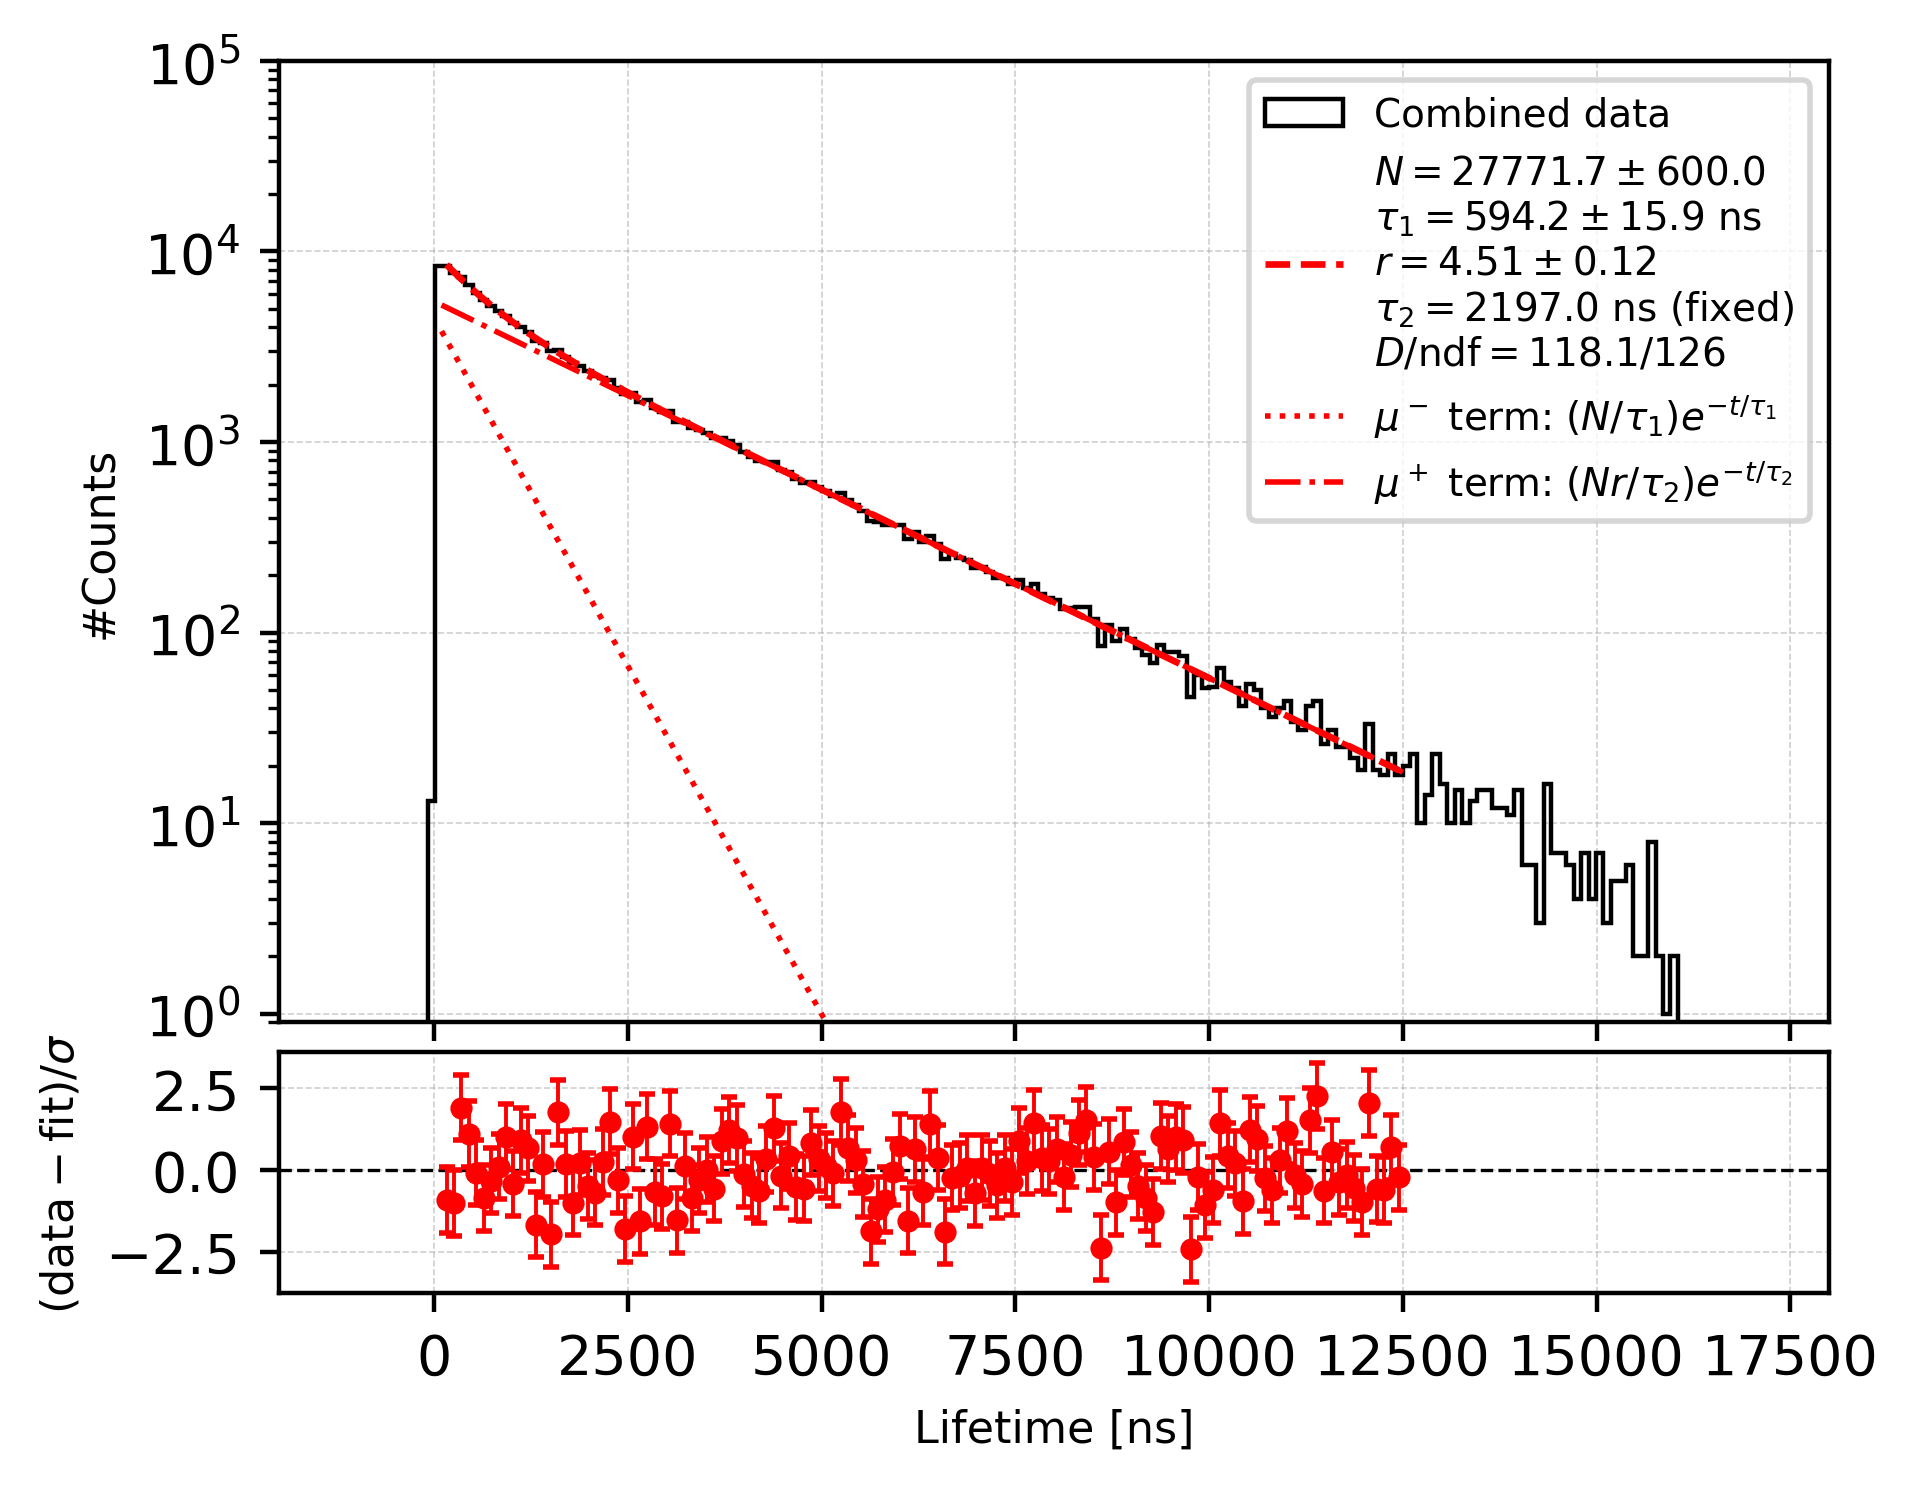

In [95]:
# ============================================================
# 4. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)



# Least Sqaure Method----------------------
#fit_and_draw(ax, ax_resid, np.asarray(lifetime_trueMichel_initial), "Combined",
#             fit_range=(400, 12500), #Fitting range================================================
#             hist_color="black", fit_color="red",
#             ratio_init=4.0, tau2=2197.0)


# Maximum Likelihood Method------------------
fit_and_draw_binnedML_minuit(ax, ax_resid, np.asarray(lifetime_trueMichel_initial), "Combined",
             fit_range=(96, 12500), #Fitting range================================================
             hist_color="black", fit_color="red",
             tau1_init=1000.0, ratio_init=5.0, tau2=2197.0)





# ============================================================
# 5. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />

### Combined fitting (fluctuating $r$ and $\tau_2$):

In [69]:
# ============================================================
# 3. Define model and fitting helper
# ============================================================
def exp2_integrated_tau2(bin_edges, N, tau1, ratio, tau2):
    """
    Expected bin counts for the model:
        f(t) = N * [ exp(-t/tau1)/tau1 + ratio * exp(-t/tau2)/tau2 ]
    Integrated over each bin [a,b]:
        mu = N * [ (e^{-a/tau1} - e^{-b/tau1}) + ratio*(e^{-a/tau2} - e^{-b/tau2}) ]
    Here N is the normalization of the PDF component (not simply total counts).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    # Safety guards (important once tau2 is a fit parameter)
    eps = 1e-12
    tau1 = max(float(tau1), eps)
    tau2 = max(float(tau2), eps)

    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    
    return N * (term1 + ratio * term2)

#### MINUIT Model:

In [70]:
from iminuit import Minuit
import numpy as np

# Binned maximum-likelihood (Poisson deviance) fitting using MINUIT (MIGRAD) ===
def fit_and_draw_binnedML_minuit_tau2(ax, ax_resid, sample, label_prefix,
                                      fit_range=(400, 10000),
                                      hist_color="black", fit_color="red",
                                      tau1_init = 1000.0, ratio_init=4.0, tau2_init=2197.0):

    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]

    # --- Binned Poisson deviance (PDG Eq. 40.16) ---
    eps = 1e-12

    def mu_model(N, tau1, ratio, tau2):
        mu = exp2_integrated_tau2(edges_fit, N, tau1, ratio, tau2)
        return np.maximum(mu, eps)

    def deviance(N, tau1, ratio, tau2):
        # Hard-bounds safety (helps Minuit avoid weird probes)
        if (N < 0.0) or (tau1 <= 0.0) or (ratio < 0.0) or (tau2 <= 0.0):
            return 1e50

        mu = mu_model(N, tau1, ratio, tau2)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)


    # -----------------------------------------------------------
    # Initial guesses
    # -----------------------------------------------------------
    N0 = float(np.sum(y)) / (1.0 + float(ratio_init))
    tau1_0 = float(tau1_init)
    ratio_0 = float(ratio_init)
    tau2_0 = float(tau2_init)


    # --- MINUIT minimization (MIGRAD) ---
    mnt = Minuit(deviance, N=N0, tau1=tau1_0, ratio=ratio_0, tau2=tau2_0)

    # Limits (bounds)  ---- you can tighten these if physics suggests it
    mnt.limits["N"] = (0.0, None)
    mnt.limits["tau1"] = (1e-6, None)
    mnt.limits["ratio"] = (0.0, None)
    mnt.limits["tau2"] = (1e-6, None)

    # For -2 ln L / deviance: 1σ corresponds to Δf = 1
    mnt.errordef = 1.0

    # Optional but often helps stability with 4 parameters:
    # provide reasonable step sizes (NOT the final errors)
    mnt.errors["N"] = max(1.0, np.sqrt(max(N0, 1.0)))
    mnt.errors["tau1"] = 50.0
    mnt.errors["ratio"] = max(0.1, 0.2 * ratio_0)
    mnt.errors["tau2"] = 50.0

    migrad_res = mnt.migrad()
    if not migrad_res.valid:
        print(f"[{label_prefix}] MINUIT MIGRAD failed or not valid.")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Covariance / HESSE errors (symmetric, curvature-based)
    mnt.hesse()


    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = mnt.covariance  # iminuit covariance object (from HESSE)

    print("\n[Minuit] Parameter order:", mnt.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- correlation matrix (often more interpretable) ---
        print("\n[Minuit] Correlation matrix:")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov.correlation()[p1, p2]: .3f}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- highlight correlations with tau1 (what you care most) ---
        print("\n[Minuit] Correlations with tau1:")
        corr = cov.correlation()
        for p in mnt.parameters:
            if p == "tau1":
                continue
            print(f"  corr(tau1, {p}) = {corr['tau1', p]: .3f}")



    # Fitted values and errors
    N_fit = float(mnt.values["N"])
    tau1_fit = float(mnt.values["tau1"])
    ratio_fit = float(mnt.values["ratio"])
    tau2_fit = float(mnt.values["tau2"])

    N_err = float(mnt.errors["N"]) if mnt.errors["N"] is not None else np.nan
    tau1_err = float(mnt.errors["tau1"]) if mnt.errors["tau1"] is not None else np.nan
    ratio_err = float(mnt.errors["ratio"]) if mnt.errors["ratio"] is not None else np.nan
    tau2_err = float(mnt.errors["tau2"]) if mnt.errors["tau2"] is not None else np.nan

    # Goodness-of-fit-like number: deviance at min
    D_min = float(mnt.fval)
    ndf = len(y) - 4

    # Residuals: signed deviance residuals (Poisson-appropriate)
    mu_fit_bins = mu_model(N_fit, tau1_fit, ratio_fit, tau2_fit)
    n = y

    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu_fit_bins[nz] - n[nz] + n[nz] * np.log(n[nz] / mu_fit_bins[nz]))
    di[~nz] = 2.0 * mu_fit_bins[~nz]
    pulls = np.sign(n - mu_fit_bins) * np.sqrt(np.maximum(di, 0.0))

    # Smooth curve for visualization (integrated model, consistent)
    x_edges_plot = bins  # NOTE: if "bins" is an int, replace with bin_edges!
    # Safer:
    # x_edges_plot = bin_edges

    if np.isscalar(x_edges_plot):
        x_edges_plot = bin_edges

    mu_plot = exp2_integrated_tau2(x_edges_plot, N_fit, tau1_fit, ratio_fit, tau2_fit)
    x_centers_plot = 0.5 * (x_edges_plot[:-1] + x_edges_plot[1:])

    # Component curves for visualization (better: integrated components)
    x_dense_edges = np.linspace(fit_range[0], fit_range[1], 801)
    x_dense = 0.5 * (x_dense_edges[:-1] + x_dense_edges[1:])
    dense_bw = x_dense_edges[1] - x_dense_edges[0]

    comp_fast = N_fit * (np.exp(-x_dense_edges[:-1] / tau1_fit) - np.exp(-x_dense_edges[1:] / tau1_fit))
    comp_slow = N_fit * ratio_fit * (np.exp(-x_dense_edges[:-1] / tau2_fit) - np.exp(-x_dense_edges[1:] / tau2_fit))

    # Convert dense-bin integrals to "counts per histogram bin" for plotting
    y_fast = (comp_fast / dense_bw) * bin_width
    y_slow = (comp_slow / dense_bw) * bin_width

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    fit_min, fit_max = fit_range
    mask_plot = (x_centers_plot >= fit_min) & (x_centers_plot <= fit_max)

    ax.plot(x_centers_plot[mask_plot], mu_plot[mask_plot],
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.2f}\pm{ratio_err:.2f}$" + "\n"
                   + rf"$\tau_2={tau2_fit:.1f}\pm{tau2_err:.1f}$ ns" + "\n"
                   + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"))

    ax.plot(x_dense, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"fast: $N e^{{-t/\tau_1}}$")

    ax.plot(x_dense, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"slow: $Nr e^{{-t/\tau_2}}$")

    # Residuals panel
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT/MIGRAD + HESSE):")
    print(f"    N    = {N_fit:.3f} ± {N_err:.3f}")
    print(f"    τ₁   = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r    = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    τ₂   = {tau2_fit:.3f} ± {tau2_err:.3f} ns")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return N_fit, N_err, tau1_fit, tau1_err, ratio_fit, ratio_err, tau2_fit, tau2_err, D_min, ndf

#### Fitting and Drawing:


[Minuit] Parameter order: ('N', 'tau1', 'ratio', 'tau2')

[Minuit] Covariance matrix (HESSE):
       N:  1.5315e+06   2.4271e+04  -2.8002e+02   1.5636e+04
    tau1:  2.4271e+04   5.2963e+02  -4.4924e+00   2.4083e+02
   ratio: -2.8002e+02  -4.4924e+00   5.1408e-02  -2.8709e+00
    tau2:  1.5636e+04   2.4083e+02  -2.8709e+00   2.1244e+02

[Minuit] Correlation matrix:
       N:  1.000   0.852  -0.998   0.867
    tau1:  0.852   1.000  -0.861   0.718
   ratio: -0.998  -0.861   1.000  -0.869
    tau2:  0.867   0.718  -0.869   1.000

[Minuit] Correlations with tau1:
  corr(tau1, N) =  0.852
  corr(tau1, ratio) = -0.861
  corr(tau1, tau2) =  0.718

[Combined] Fit range = (96, 12500) ns
  Number of events in fit range: 143128
  Fit results (MINUIT/MIGRAD + HESSE):
    N    = 28915.258 ± 1237.531
    τ₁   = 611.903 ± 23.014 ns
    r    = 4.290 ± 0.227
    τ₂   = 2212.655 ± 14.575 ns
    D/ndf = 116.9/125


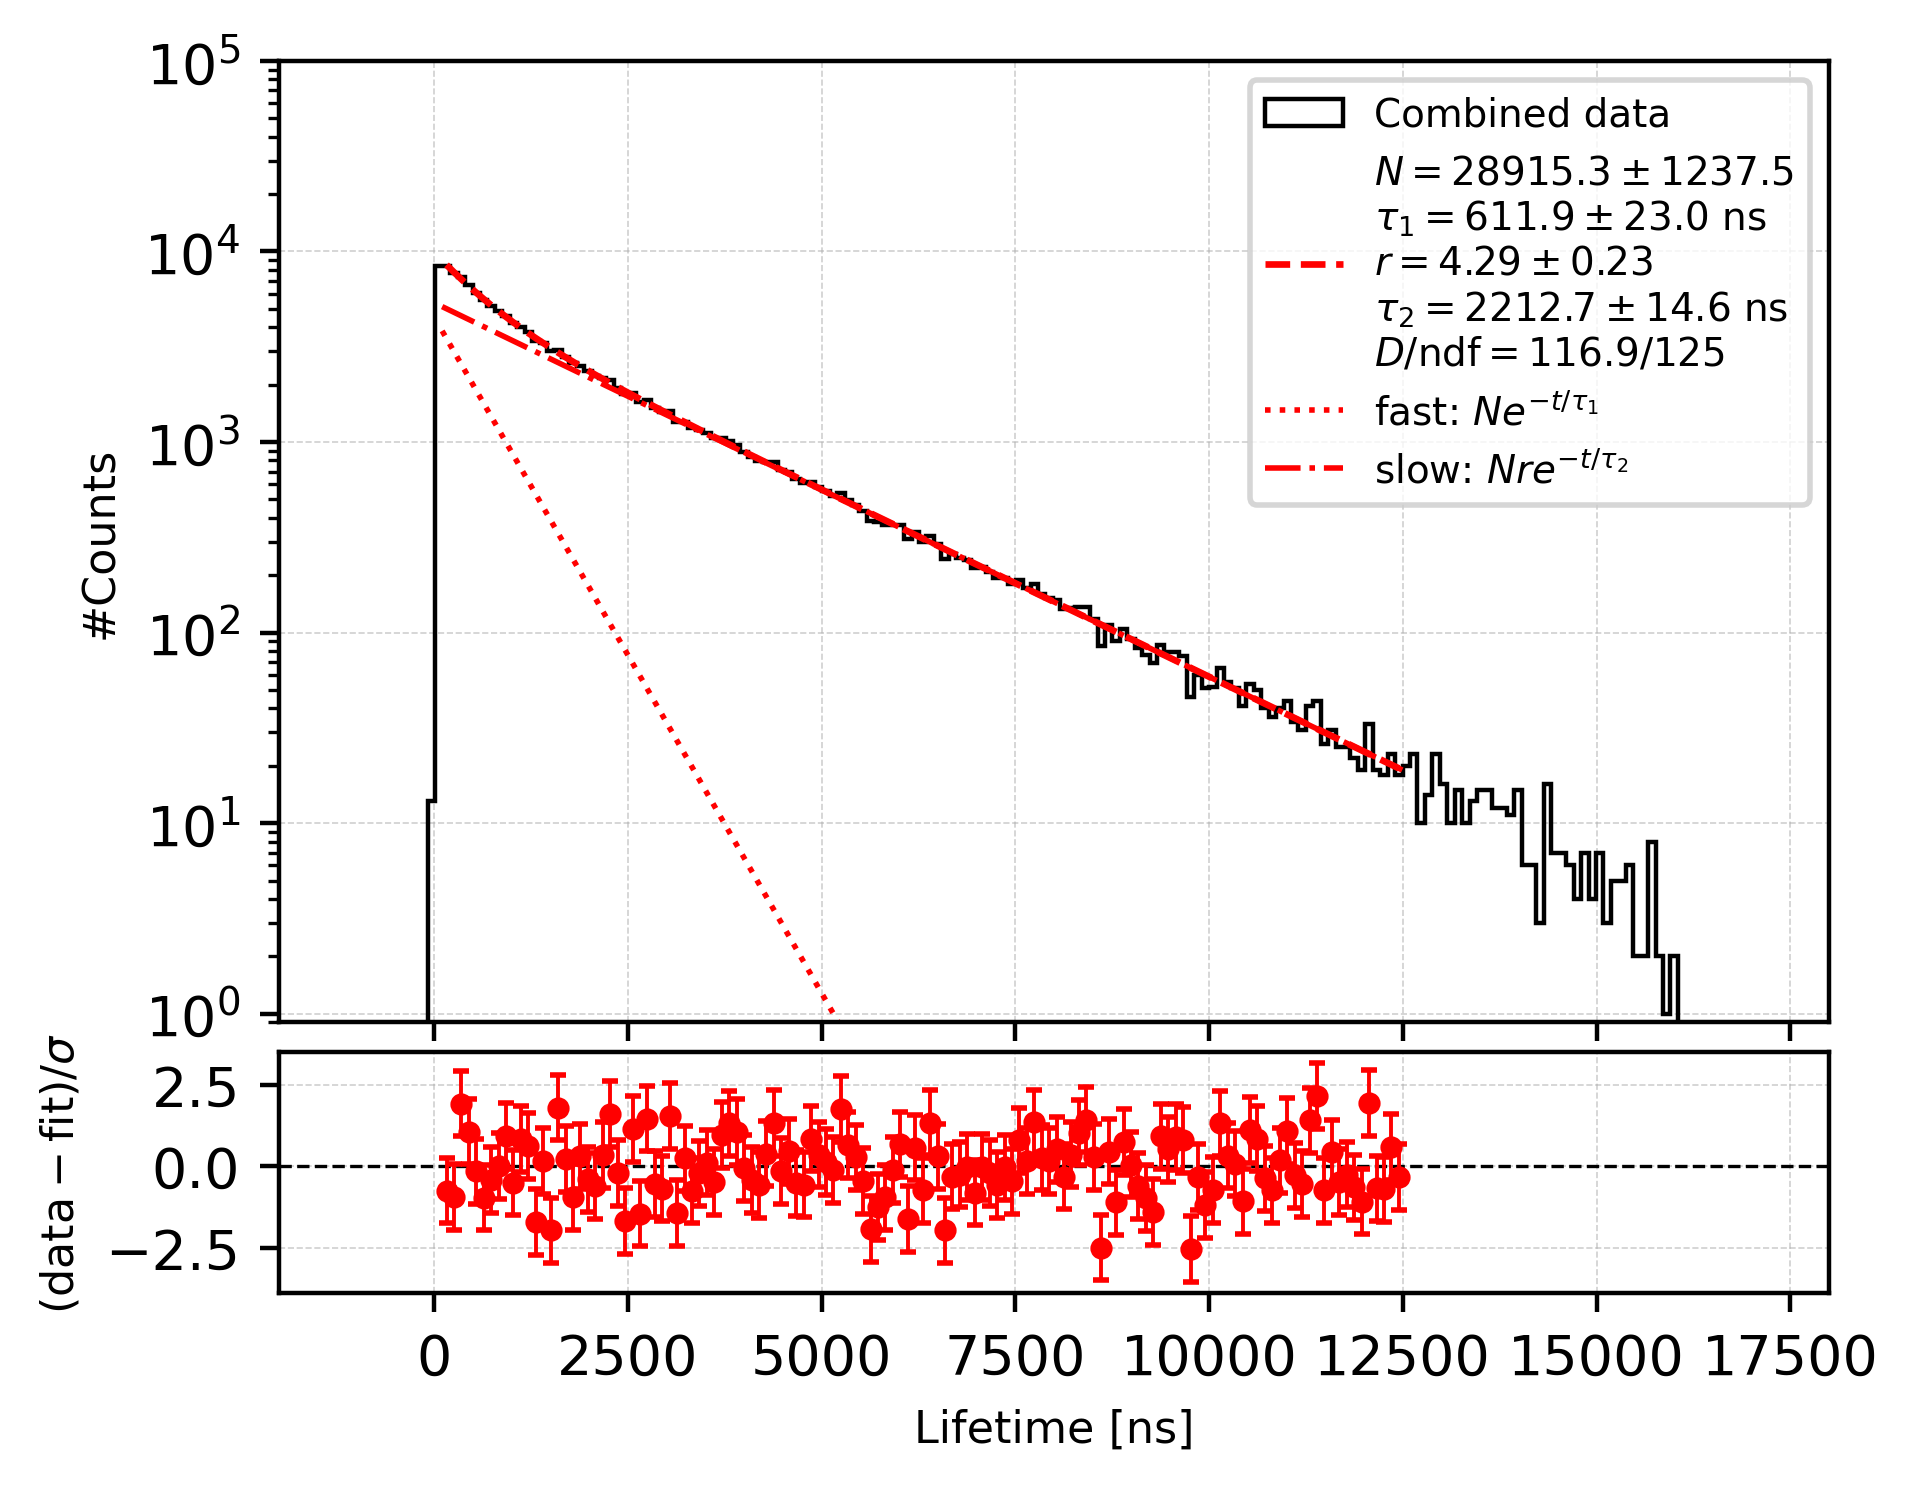

In [71]:
# ============================================================
# 4. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)



# Maximum Likelihood Method------------------
# Maximum Likelihood Method (tau2 floating) ------------------
fit_and_draw_binnedML_minuit_tau2(
    ax, ax_resid,
    np.asarray(lifetime_trueMichel_initial),
    "Combined",
    fit_range=(96, 12500),     # Fitting range
    hist_color="black",
    fit_color="red",
    tau1_init=1000.0,
    ratio_init=3.0,
    tau2_init=2597.0            # initial guess for tau2 (now a fit parameter)
)





# ============================================================
# 5. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## NEW fitting functions: (CURRENT BEST; 20251104)

Decay rate model:

$$
f(t) = N^{+} \cdot 
\left[
\frac{1}{\tau_{\mu^{+}}} \, e^{-t / \tau_{\mu^{+}}}
+ \frac{Q}{\tau_{\mu^{+}} \, R_{\mu}} \, e^{-t / \tau_{\mu^{-}}}
\right]
$$

**Where:**

- \( N^{+} \): initial number of positive muons (\( \mu^{+} \))  
- \( \tau_{\mu^{+}} = 2.197~\mu\text{s} \): lifetime of free positive muons  
- \( Q \): Huff factor (captures nuclear capture probability effects)  
- \( R_{\mu} \): ratio between positive and negative muons (\( \mu^{+} / \mu^{-} \))  
- \( \tau_{\mu^{-}} \): effective lifetime of negative muons in the medium  


<br />

**For fitting range [a, b]:**


$$
F_{[a,b]}=\int_{a}^{b} f(t)\,dt
$$

$$
\int_a^b \frac{1}{\tau_{\mu^{+}}}e^{-t/\tau_{\mu^{+}}}\,dt
= e^{-a/\tau_{\mu^{+}}}-e^{-b/\tau_{\mu^{+}}}
$$

$$
\int_a^b \frac{Q}{\tau_{\mu^{+}}R_{\mu}}e^{-t/\tau_{\mu^{-}}}\,dt
=
\frac{Q\,\tau_{\mu^{-}}}{\tau_{\mu^{+}}R_{\mu}}
\left(
e^{-a/\tau_{\mu^{-}}}-e^{-b/\tau_{\mu^{-}}}
\right)
$$

$$
\boxed{
F_{[a,b]}
=
N^{+}\left[
\left(
e^{-a/\tau_{\mu^{+}}}-e^{-b/\tau_{\mu^{+}}}
\right)
+
\frac{Q\,\tau_{\mu^{-}}}{\tau_{\mu^{+}}R_{\mu}}
\left(
e^{-a/\tau_{\mu^{-}}}-e^{-b/\tau_{\mu^{-}}}
\right)
\right]
}
$$



<br />

### FITTING I (Fix Q, R, tau2, only fluctuating N and tau1):

In [72]:
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare sample
# ============================================================
# Convert µs → ns and remove negative/nonphysical times
lifetime_trueMichel_initial = np.array([ev.lifetime_initial * 1000 for ev in events_true])
lifetime_trueMichel_initial = lifetime_trueMichel_initial[lifetime_trueMichel_initial > 0]


#np.save("lifetime_trueMichel_initial.npy", lifetime_trueMichel_initial)
print("\n\nLength of lifetime_trueMichel_initial: ", len(lifetime_trueMichel_initial))


# ============================================================
# 2. Physics constants
# ============================================================
tau_mu_plus = 2197.0   # ns (2.197 µs)
Q = 0.988 #0.988
R_mu = 1.2

# ============================================================
# 3. Define bin-integrated physics model
# ============================================================
def michel_integrated_newFunc(bin_edges, N_plus, tau_mu_minus):
    """
    Integrated expected counts per bin for Michel e± from muon decays.

    Differential model:
      N(t) = N⁺ * [ (1/τ⁺) e^{-t/τ⁺} + (Q/(τ⁺ Rµ)) e^{-t/τ⁻} ]

    Bin-integrated over [a,b]:
      ΔN = N⁺ * [ (e^{-a/τ⁺} - e^{-b/τ⁺})
                  + (Q τ⁻ / (Rµ τ⁺)) (e^{-a/τ⁻} - e^{-b/τ⁻}) ].
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    term_plus  = np.exp(-a / tau_mu_plus)  - np.exp(-b / tau_mu_plus)
    term_minus = np.exp(-a / tau_mu_minus) - np.exp(-b / tau_mu_minus)

    return N_plus * (term_plus + (Q * tau_mu_minus) / (R_mu * tau_mu_plus) * term_minus)








Length of lifetime_trueMichel_initial:  150372


#### Binned Maximum Likelihood + MINUIT:

In [73]:
# Maximum likelihood fitting (binned Poisson deviance) with MINUIT (iminuit)
# + MINOS profile-likelihood errors (ΔD = 1, i.e. Δ(-2 ln L) = 1)

import numpy as np
from iminuit import Minuit


def fit_and_draw_binnedML_newFunc(ax, ax_resid, sample, label_prefix,
                                 fit_range=(200, 8000),
                                 hist_color="black", fit_color="red",
                                 show_components=True,
                                 tau1_init=1000.0):

    # Histogram in the global (range_min, range_max) window
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width_local = (bin_edges[1] - bin_edges[0])  # should equal your global bin_width if consistent

    # Select fitting window (based on bin centers)
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    # Edges spanning the fit region
    i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
    edges_fit = bin_edges[i0:i1 + 2]

    eps = 1e-12

    def mu_model(N_plus, tau_mu_minus):
        mu = michel_integrated_newFunc(edges_fit, N_plus, tau_mu_minus)
        return np.maximum(mu, eps)

    # Poisson deviance D = 2 Σ [μ - n + n ln(n/μ)]  (with convention n ln(n/μ)=0 for n=0)
    def deviance_N_tau(N_plus, tau_mu_minus):
        if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0):
            return 1e50  # a huge penalty; Minuit dislikes np.inf
        mu = mu_model(N_plus, tau_mu_minus)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)

    # -------------------------
    # MINUIT fit (MIGRAD + HESSE + MINOS)
    # -----------------------------------------------------------------
    # initial values---
    N0 = float(np.sum(y))
    tau0 = float(tau1_init)
    # -----------------------------------------------------------------

    # Reasonable step sizes for Minuit
    N_err0 = max(1.0, np.sqrt(max(N0, 1.0)))
    tau_err0 = 50.0

    minuit = Minuit(deviance_N_tau, N_plus=N0, tau_mu_minus=tau0)
    minuit.errordef = 1.0  # because we minimize D = -2 ln L (up to constant), so ΔD=1 for 1σ (1 parameter)

    # Bounds / limits
    minuit.limits["N_plus"] = (0.0, None)
    minuit.limits["tau_mu_minus"] = (100.0, 2000.0)

    # Initial step sizes
    minuit.errors["N_plus"] = N_err0
    minuit.errors["tau_mu_minus"] = tau_err0

    # Run minimization
    mres = minuit.migrad()
    if (not mres.valid) or (not np.isfinite(minuit.fval)):
        print(f"[{label_prefix}] MINUIT MIGRAD failed/invalid")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Optional: refine covariance with HESSE
    minuit.hesse()



    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = minuit.covariance

    print("\n[Minuit] Parameter order:", minuit.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        params = list(minuit.parameters)
        namew = max(len(p) for p in params)

        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- correlation matrix ---
        print("\n[Minuit] Correlation matrix:")
        corr = cov.correlation()
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{corr[p1, p2]: .3f}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- highlight correlations with tau_mu_minus ---
        target = "tau_mu_minus"
        if target in params:
            print(f"\n[Minuit] Correlations with {target}:")
            for p in params:
                if p == target:
                    continue
                print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")




    N_plus_fit = float(minuit.values["N_plus"])
    tau_mu_minus_fit = float(minuit.values["tau_mu_minus"])
    D_min = float(minuit.fval)
    ndf = len(y) - 2

    # MINOS profile-likelihood errors (asymmetric in general)
    # This uses the same criterion: ΔFCN = 1 (because errordef=1).
    N_plus_err = np.nan
    tau_mu_minus_err = np.nan

    try:
        minuit.minos("N_plus", "tau_mu_minus")
        # minuit.merrors[param] gives (lower, upper) errors (negative, positive)
        if "N_plus" in minuit.merrors:
            e = minuit.merrors["N_plus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                N_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))  # symmetric summary
        if "tau_mu_minus" in minuit.merrors:
            e = minuit.merrors["tau_mu_minus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_minus_err = 0.5 * (abs(e.lower) + abs(e.upper))
    except Exception as ex:
        print(f"[{label_prefix}] MINOS failed: {ex}")

    # -------------------------
    # Model expectation in the *fit bins* (for residuals)
    # -------------------------
    y_model = michel_integrated_newFunc(edges_fit, N_plus_fit, tau_mu_minus_fit)

    # Signed deviance residuals (Poisson)
    n = y
    mu = np.maximum(y_model, eps)
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu[nz] - n[nz] + n[nz] * np.log(n[nz] / mu[nz]))
    di[~nz] = 2.0 * mu[~nz]
    pulls = np.sign(n - mu) * np.sqrt(np.maximum(di, 0.0))

    # -------------------------
    # Draw data histogram
    # -------------------------
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    # -------------------------
    # Draw fitted model as a smooth curve with correct normalization
    # -------------------------
    fine_edges = np.linspace(fit_range[0], fit_range[1], 801)  # 800 tiny bins
    fine_centers = 0.5 * (fine_edges[:-1] + fine_edges[1:])
    fine_bin_width = fine_edges[1] - fine_edges[0]

    y_fine_total = michel_integrated_newFunc(fine_edges, N_plus_fit, tau_mu_minus_fit)
    # convert to "counts per original hist bin width"
    y_curve_total = (y_fine_total / fine_bin_width) * bin_width

    ax.plot(
        fine_centers, y_curve_total,
        color=fit_color, linestyle='--', linewidth=1.2,
        label=(
            r"Fit: Michel model" "\n"
            + rf"$Q = {Q:.3f}$" "\n"
            + rf"$R_\mu = {R_mu:.2f}$" "\n"
            + rf"$\tau_+ = {tau_mu_plus:.0f}\,\mathrm{{ns}}$" "\n"
            + rf"$\tau_- = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$N^+ = {N_plus_fit:.0f} \pm {N_plus_err:.0f}$ (Fit)" "\n"
            + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"
        )
    )

    # Optional: draw the two component curves
    if show_components:
        comp_plus_fine = N_plus_fit * (
            np.exp(-fine_edges[:-1] / tau_mu_plus) - np.exp(-fine_edges[1:] / tau_mu_plus)
        )
        comp_minus_fine = N_plus_fit * (Q * tau_mu_minus_fit) / (R_mu * tau_mu_plus) * (
            np.exp(-fine_edges[:-1] / tau_mu_minus_fit) - np.exp(-fine_edges[1:] / tau_mu_minus_fit)
        )

        comp_plus_curve = (comp_plus_fine / fine_bin_width) * bin_width
        comp_minus_curve = (comp_minus_fine / fine_bin_width) * bin_width

        ax.plot(fine_centers, comp_plus_curve,
                linestyle=':', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_+$ term")

        ax.plot(fine_centers, comp_minus_curve,
                linestyle='-.', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_-$ term")

    # -------------------------
    # Residuals panel
    # -------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        centers[i0:i1 + 1], pulls,
        yerr=np.ones_like(pulls),
        fmt='o', color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT):")
    print(f"    τ(μ⁻) = {tau_mu_minus_fit:.3f} ± {tau_mu_minus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    N^+   = {N_plus_fit:.1f} ± {N_plus_err:.1f} (MINOS, ΔD=1)")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return N_plus_fit, N_plus_err, tau_mu_minus_fit, tau_mu_minus_err, D_min, ndf

#### Running and drawing:


[Minuit] Parameter order: ('N_plus', 'tau_mu_minus')

[Minuit] Covariance matrix (HESSE):
        N_plus:  5.1976e+05  -9.0420e+03
  tau_mu_minus: -9.0420e+03   2.1588e+02

[Minuit] Correlation matrix:
        N_plus:  1.000  -0.854
  tau_mu_minus: -0.854   1.000

[Minuit] Correlations with tau_mu_minus:
  corr(tau_mu_minus, N_plus) = -0.854

[Combined] Fit range = (480, 12500) ns
  Number of events in fit range: 112508
  Fit results (MINUIT):
    τ(μ⁻) = 586.739 ± 14.698 ns (MINOS, ΔD=1)
    N^+   = 125383.9 ± 721.1 (MINOS, ΔD=1)
    D/ndf = 111.2/123


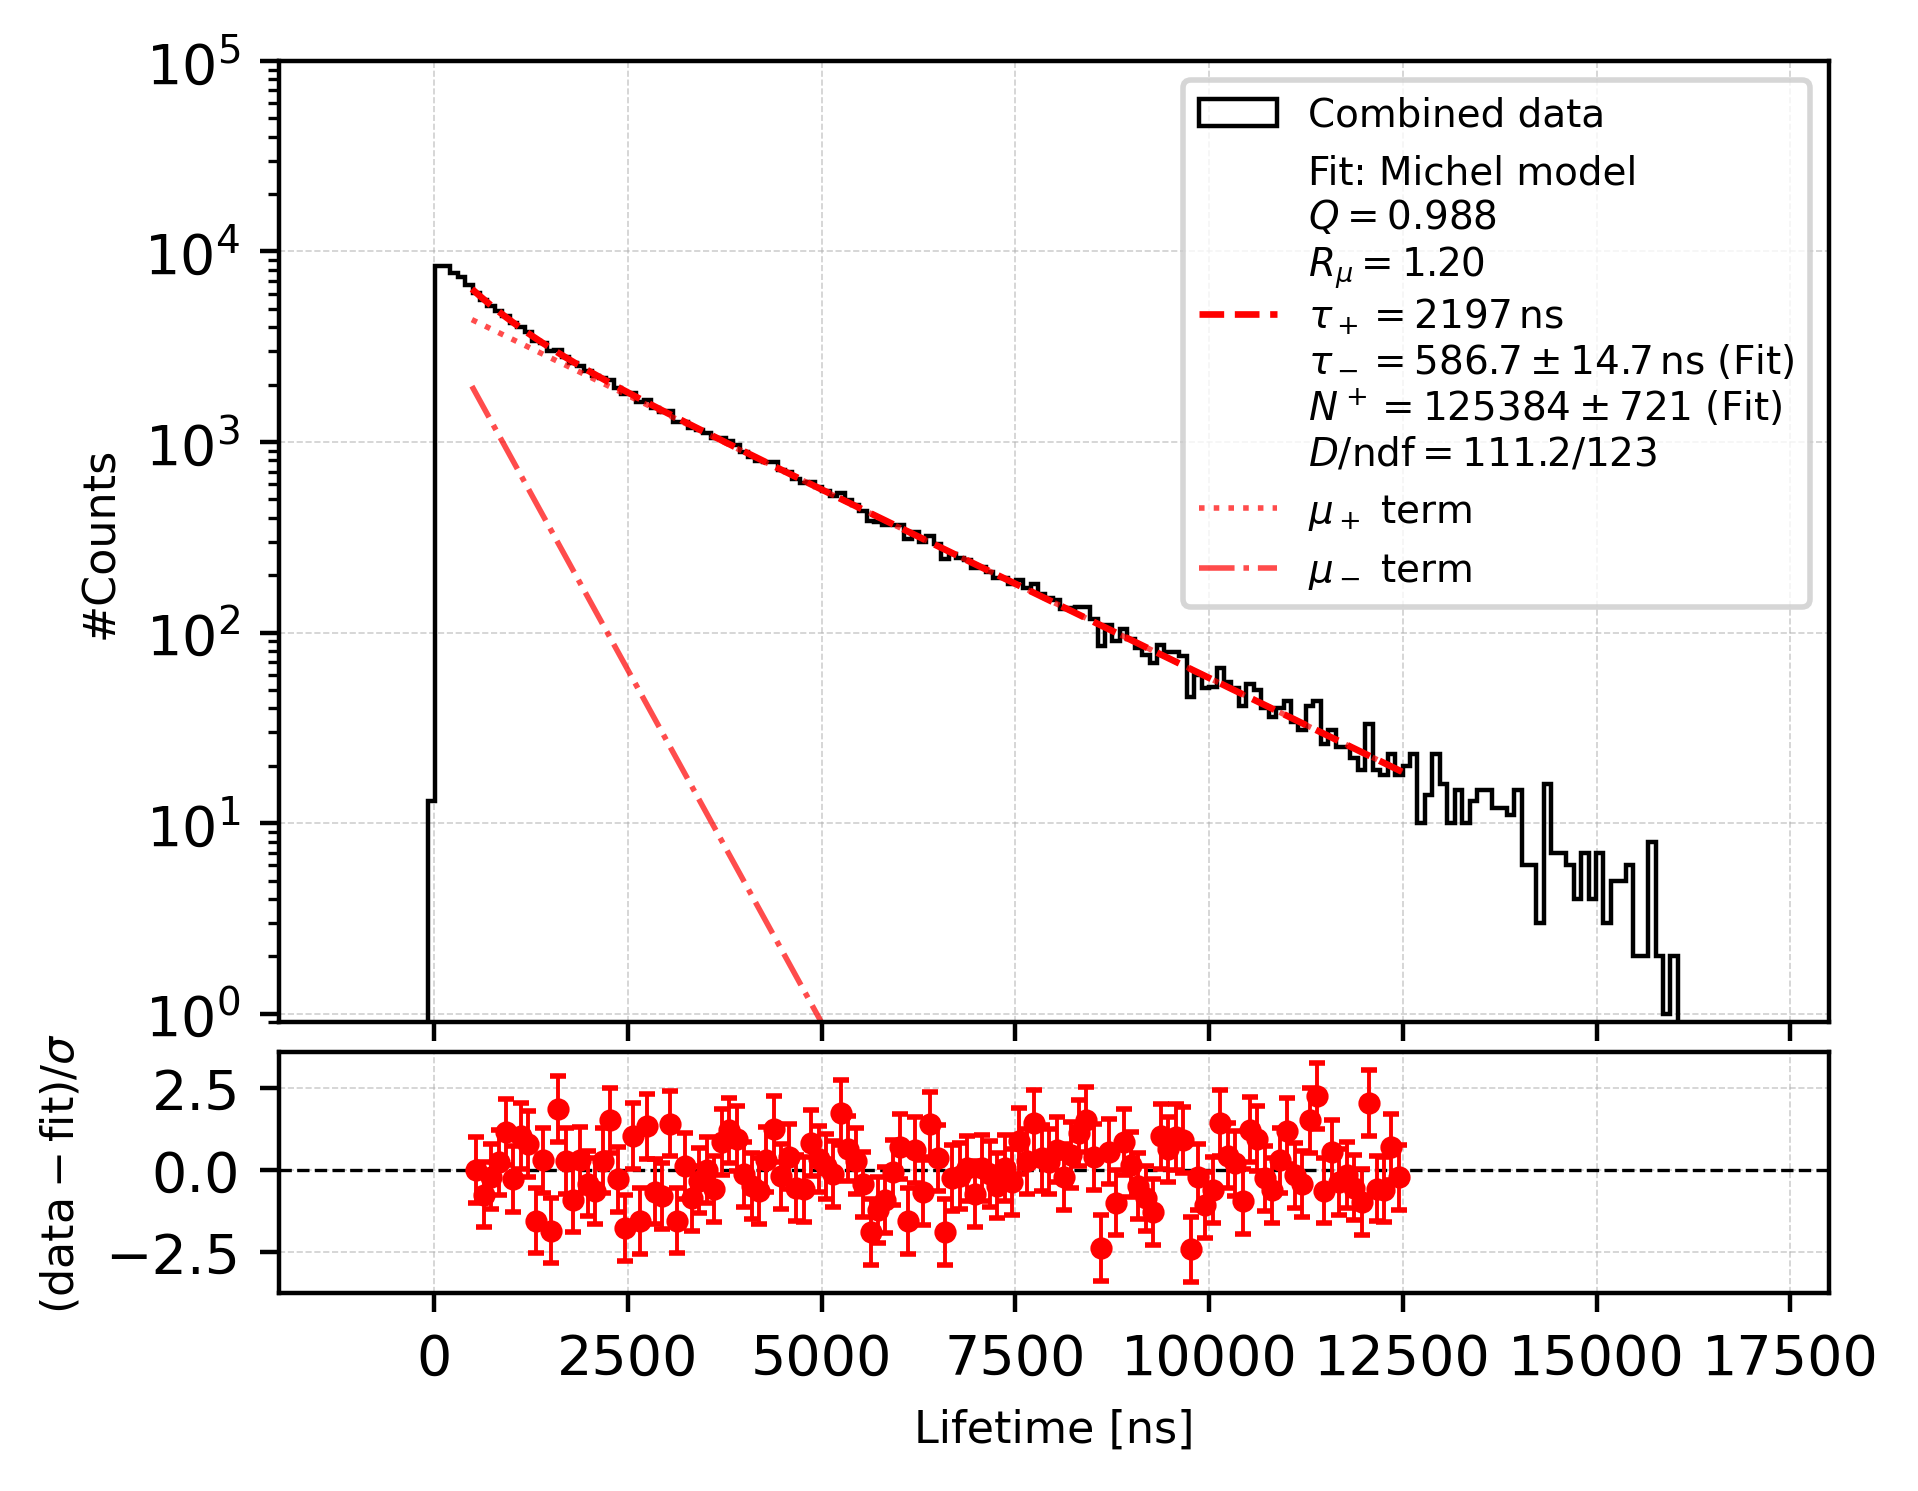

In [75]:


# ============================================================
# 5. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

fit_and_draw_binnedML_newFunc(ax, ax_resid, lifetime_trueMichel_initial, "Combined",
             fit_range=(480, 12500),#Fitting range=======================================================
             hist_color="black", fit_color="red", show_components=True,
             tau1_init=1000.0)

# ============================================================
# 6. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
legend = ax.legend(
    loc='upper right',
    fontsize=7
)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />

### FITTING II (Fix R, tau2, only fluctuating N, tau1 and Q):

In [76]:
# ============================================================
# 3. Define bin-integrated physics model (Q floating)
# ============================================================
def michel_integrated_newFunc_Q(bin_edges, N_plus, tau_mu_minus, Q_fit,
                        tau_mu_plus=2197.0, R_mu=1.2):
    """
    Integrated expected counts per bin for Michel e± from muon decays.

    Differential model:
      N(t) = N⁺ * [ (1/τ⁺) e^{-t/τ⁺} + (Q/(τ⁺ Rµ)) e^{-t/τ⁻} ]

    Bin-integrated over [a,b]:
      ΔN = N⁺ * [ (e^{-a/τ⁺} - e^{-b/τ⁺})
                  + (Q τ⁻ / (Rµ τ⁺)) (e^{-a/τ⁻} - e^{-b/τ⁻}) ].

    Parameters
    ----------
    N_plus      : normalization (mu+ decays)
    tau_mu_minus: mu- effective lifetime (fit)
    Q_fit       : mu- survival / capture factor (fit)
    tau_mu_plus : fixed mu+ lifetime (default 2197 ns)
    R_mu        : fixed ratio factor (default 1.2)
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    eps = 1e-12
    tau_mu_minus = np.maximum(float(tau_mu_minus), eps)

    term_plus  = np.exp(-a / tau_mu_plus)    - np.exp(-b / tau_mu_plus)
    term_minus = np.exp(-a / tau_mu_minus)  - np.exp(-b / tau_mu_minus)

    return N_plus * (term_plus + (Q_fit * tau_mu_minus) / (R_mu * tau_mu_plus) * term_minus)

#### Binned Maximum Likelihood + MINUIT:

In [78]:

# ============================================================
# Maximum likelihood fitting (binned Poisson deviance) with MINUIT (iminuit)
# + MINOS profile-likelihood errors (ΔD = 1)
# ============================================================
import numpy as np
from iminuit import Minuit


def fit_and_draw_binnedML_newFunc_Q(ax, ax_resid, sample, label_prefix,
                                 fit_range=(200, 8000),
                                 hist_color="black", fit_color="red",
                                 show_components=True,
                                 tau1_init=1000.0,
                                 Q_init=0.988):

    # Histogram in the global (range_min, range_max) window
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width_local = (bin_edges[1] - bin_edges[0])

    # Select fitting window (based on bin centers)
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    # Edges spanning the fit region
    i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
    edges_fit = bin_edges[i0:i1 + 2]

    eps = 1e-12

    def mu_model(N_plus, tau_mu_minus, Q_fit):
        mu = michel_integrated_newFunc_Q(edges_fit, N_plus, tau_mu_minus, Q_fit,
                                         tau_mu_plus=tau_mu_plus, R_mu=R_mu)
        return np.maximum(mu, eps)

    # Poisson deviance D = 2 Σ [μ - n + n ln(n/μ)]
    def deviance(N_plus, tau_mu_minus, Q_fit):
        # hard bounds safety
        if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0) or (Q_fit < 0.0) or (Q_fit > 1.2):
            return 1e50

        mu = mu_model(N_plus, tau_mu_minus, Q_fit)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)

    # -------------------------
    # MINUIT fit (MIGRAD + HESSE + MINOS)
    # -------------------------
    N0 = float(np.sum(y))
    tau0 = float(tau1_init)
    Q0 = float(Q_init)

    # Reasonable step sizes for Minuit
    N_err0 = max(1.0, np.sqrt(max(N0, 1.0)))
    tau_err0 = 50.0
    Q_err0 = 0.02

    minuit = Minuit(deviance, N_plus=N0, tau_mu_minus=tau0, Q_fit=Q0)
    minuit.errordef = 1.0  # ΔD=1 corresponds to 1σ (1 parameter)

    # Bounds / limits
    minuit.limits["N_plus"] = (0.0, None)
    minuit.limits["tau_mu_minus"] = (100.0, 2000.0)
    # Q is physically near [0,1]; allow a bit above 1 for robustness if desired
    minuit.limits["Q_fit"] = (0.0, 1.2)

    # Initial step sizes (NOT final uncertainties)
    minuit.errors["N_plus"] = N_err0
    minuit.errors["tau_mu_minus"] = tau_err0
    minuit.errors["Q_fit"] = Q_err0

    # Run minimization
    mres = minuit.migrad()
    if (not mres.valid) or (not np.isfinite(minuit.fval)):
        print(f"[{label_prefix}] MINUIT MIGRAD failed/invalid")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Optional: refine covariance with HESSE
    minuit.hesse()

    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = minuit.covariance

    print("\n[Minuit] Parameter order:", minuit.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        params = list(minuit.parameters)
        namew = max(len(p) for p in params)

        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- correlation matrix ---
        print("\n[Minuit] Correlation matrix:")
        corr = cov.correlation()
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{corr[p1, p2]: .3f}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- highlight correlations with tau_mu_minus (physics) ---
        target = "tau_mu_minus"
        if target in params:
            print(f"\n[Minuit] Correlations with {target}:")
            for p in params:
                if p == target:
                    continue
                print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")

        # --- highlight correlations with Q_fit (often also interesting) ---
        target = "Q_fit"
        if target in params:
            print(f"\n[Minuit] Correlations with {target}:")
            for p in params:
                if p == target:
                    continue
                print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")







    N_plus_fit = float(minuit.values["N_plus"])
    tau_mu_minus_fit = float(minuit.values["tau_mu_minus"])
    Q_fit_best = float(minuit.values["Q_fit"])

    D_min = float(minuit.fval)
    ndf = len(y) - 3

    # MINOS profile-likelihood errors (asymmetric in general)
    N_plus_err = np.nan
    tau_mu_minus_err = np.nan
    Q_fit_err = np.nan

    try:
        minuit.minos("N_plus", "tau_mu_minus", "Q_fit")

        if "N_plus" in minuit.merrors:
            e = minuit.merrors["N_plus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                N_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "tau_mu_minus" in minuit.merrors:
            e = minuit.merrors["tau_mu_minus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_minus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "Q_fit" in minuit.merrors:
            e = minuit.merrors["Q_fit"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                Q_fit_err = 0.5 * (abs(e.lower) + abs(e.upper))

    except Exception as ex:
        print(f"[{label_prefix}] MINOS failed: {ex}")

    # -------------------------
    # Model expectation in the *fit bins* (for residuals)
    # -------------------------
    y_model = michel_integrated_newFunc_Q(edges_fit, N_plus_fit, tau_mu_minus_fit, Q_fit_best,
                                          tau_mu_plus=tau_mu_plus, R_mu=R_mu)

    # Signed deviance residuals (Poisson)
    n = y
    mu = np.maximum(y_model, eps)
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu[nz] - n[nz] + n[nz] * np.log(n[nz] / mu[nz]))
    di[~nz] = 2.0 * mu[~nz]
    pulls = np.sign(n - mu) * np.sqrt(np.maximum(di, 0.0))

    # -------------------------
    # Draw data histogram
    # -------------------------
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    # -------------------------
    # Draw fitted model as a smooth curve with correct normalization
    # -------------------------
    fine_edges = np.linspace(fit_range[0], fit_range[1], 801)  # 800 tiny bins
    fine_centers = 0.5 * (fine_edges[:-1] + fine_edges[1:])
    fine_bin_width = fine_edges[1] - fine_edges[0]

    y_fine_total = michel_integrated_newFunc_Q(fine_edges, N_plus_fit, tau_mu_minus_fit, Q_fit_best,
                                               tau_mu_plus=tau_mu_plus, R_mu=R_mu)
    y_curve_total = (y_fine_total / fine_bin_width) * bin_width

    ax.plot(
        fine_centers, y_curve_total,
        color=fit_color, linestyle='--', linewidth=1.2,
        label=(
            r"Fit: Michel model" "\n"
            + rf"$Q = {Q_fit_best:.3f} \pm {Q_fit_err:.3f}$ (Fit)" "\n"
            + rf"$R_\mu = {R_mu:.2f}$" "\n"
            + rf"$\tau_+ = {tau_mu_plus:.0f}\,\mathrm{{ns}}$" "\n"
            + rf"$\tau_- = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$N^+ = {N_plus_fit:.0f} \pm {N_plus_err:.0f}$ (Fit)" "\n"
            + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"
        )
    )

    # Optional: draw the two component curves (now using Q_fit_best)
    if show_components:
        comp_plus_fine = N_plus_fit * (
            np.exp(-fine_edges[:-1] / tau_mu_plus) - np.exp(-fine_edges[1:] / tau_mu_plus)
        )

        comp_minus_fine = N_plus_fit * (Q_fit_best * tau_mu_minus_fit) / (R_mu * tau_mu_plus) * (
            np.exp(-fine_edges[:-1] / tau_mu_minus_fit) - np.exp(-fine_edges[1:] / tau_mu_minus_fit)
        )

        comp_plus_curve = (comp_plus_fine / fine_bin_width) * bin_width
        comp_minus_curve = (comp_minus_fine / fine_bin_width) * bin_width

        ax.plot(fine_centers, comp_plus_curve,
                linestyle=':', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_+$ term")

        ax.plot(fine_centers, comp_minus_curve,
                linestyle='-.', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_-$ term")

    # -------------------------
    # Residuals panel
    # -------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        centers[i0:i1 + 1], pulls,
        yerr=np.ones_like(pulls),
        fmt='o', color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT):")
    print(f"    Q      = {Q_fit_best:.6f} ± {Q_fit_err:.6f} (MINOS, ΔD=1)")
    print(f"    τ(μ⁻)  = {tau_mu_minus_fit:.3f} ± {tau_mu_minus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    N^+    = {N_plus_fit:.1f} ± {N_plus_err:.1f} (MINOS, ΔD=1)")
    print(f"    D/ndf  = {D_min:.1f}/{ndf}")

    return (
        N_plus_fit, N_plus_err,
        tau_mu_minus_fit, tau_mu_minus_err,
        Q_fit_best, Q_fit_err,
        D_min, ndf
    )

### Run & draw:


[Minuit] Parameter order: ('N_plus', 'tau_mu_minus', 'Q_fit')

[Minuit] Covariance matrix (HESSE):
        N_plus:  4.8113e+05  -7.3506e+03  -3.4489e+00
  tau_mu_minus: -7.3506e+03   2.5161e+02  -1.3963e-01
         Q_fit: -3.4489e+00  -1.3963e-01   4.4161e-04

[Minuit] Correlation matrix:
        N_plus:  1.000  -0.668  -0.237
  tau_mu_minus: -0.668   1.000  -0.419
         Q_fit: -0.237  -0.419   1.000

[Minuit] Correlations with tau_mu_minus:
  corr(tau_mu_minus, N_plus) = -0.668
  corr(tau_mu_minus, Q_fit) = -0.419

[Minuit] Correlations with Q_fit:
  corr(Q_fit, N_plus) = -0.237
  corr(Q_fit, tau_mu_minus) = -0.419

[Combined] Fit range = (96, 12500) ns
  Number of events in fit range: 143128
  Fit results (MINUIT):
    Q      = 0.984044 ± 0.021017 (MINOS, ΔD=1)
    τ(μ⁻)  = 594.262 ± 15.865 ns (MINOS, ΔD=1)
    N^+    = 125213.4 ± 693.8 (MINOS, ΔD=1)
    D/ndf  = 118.1/126


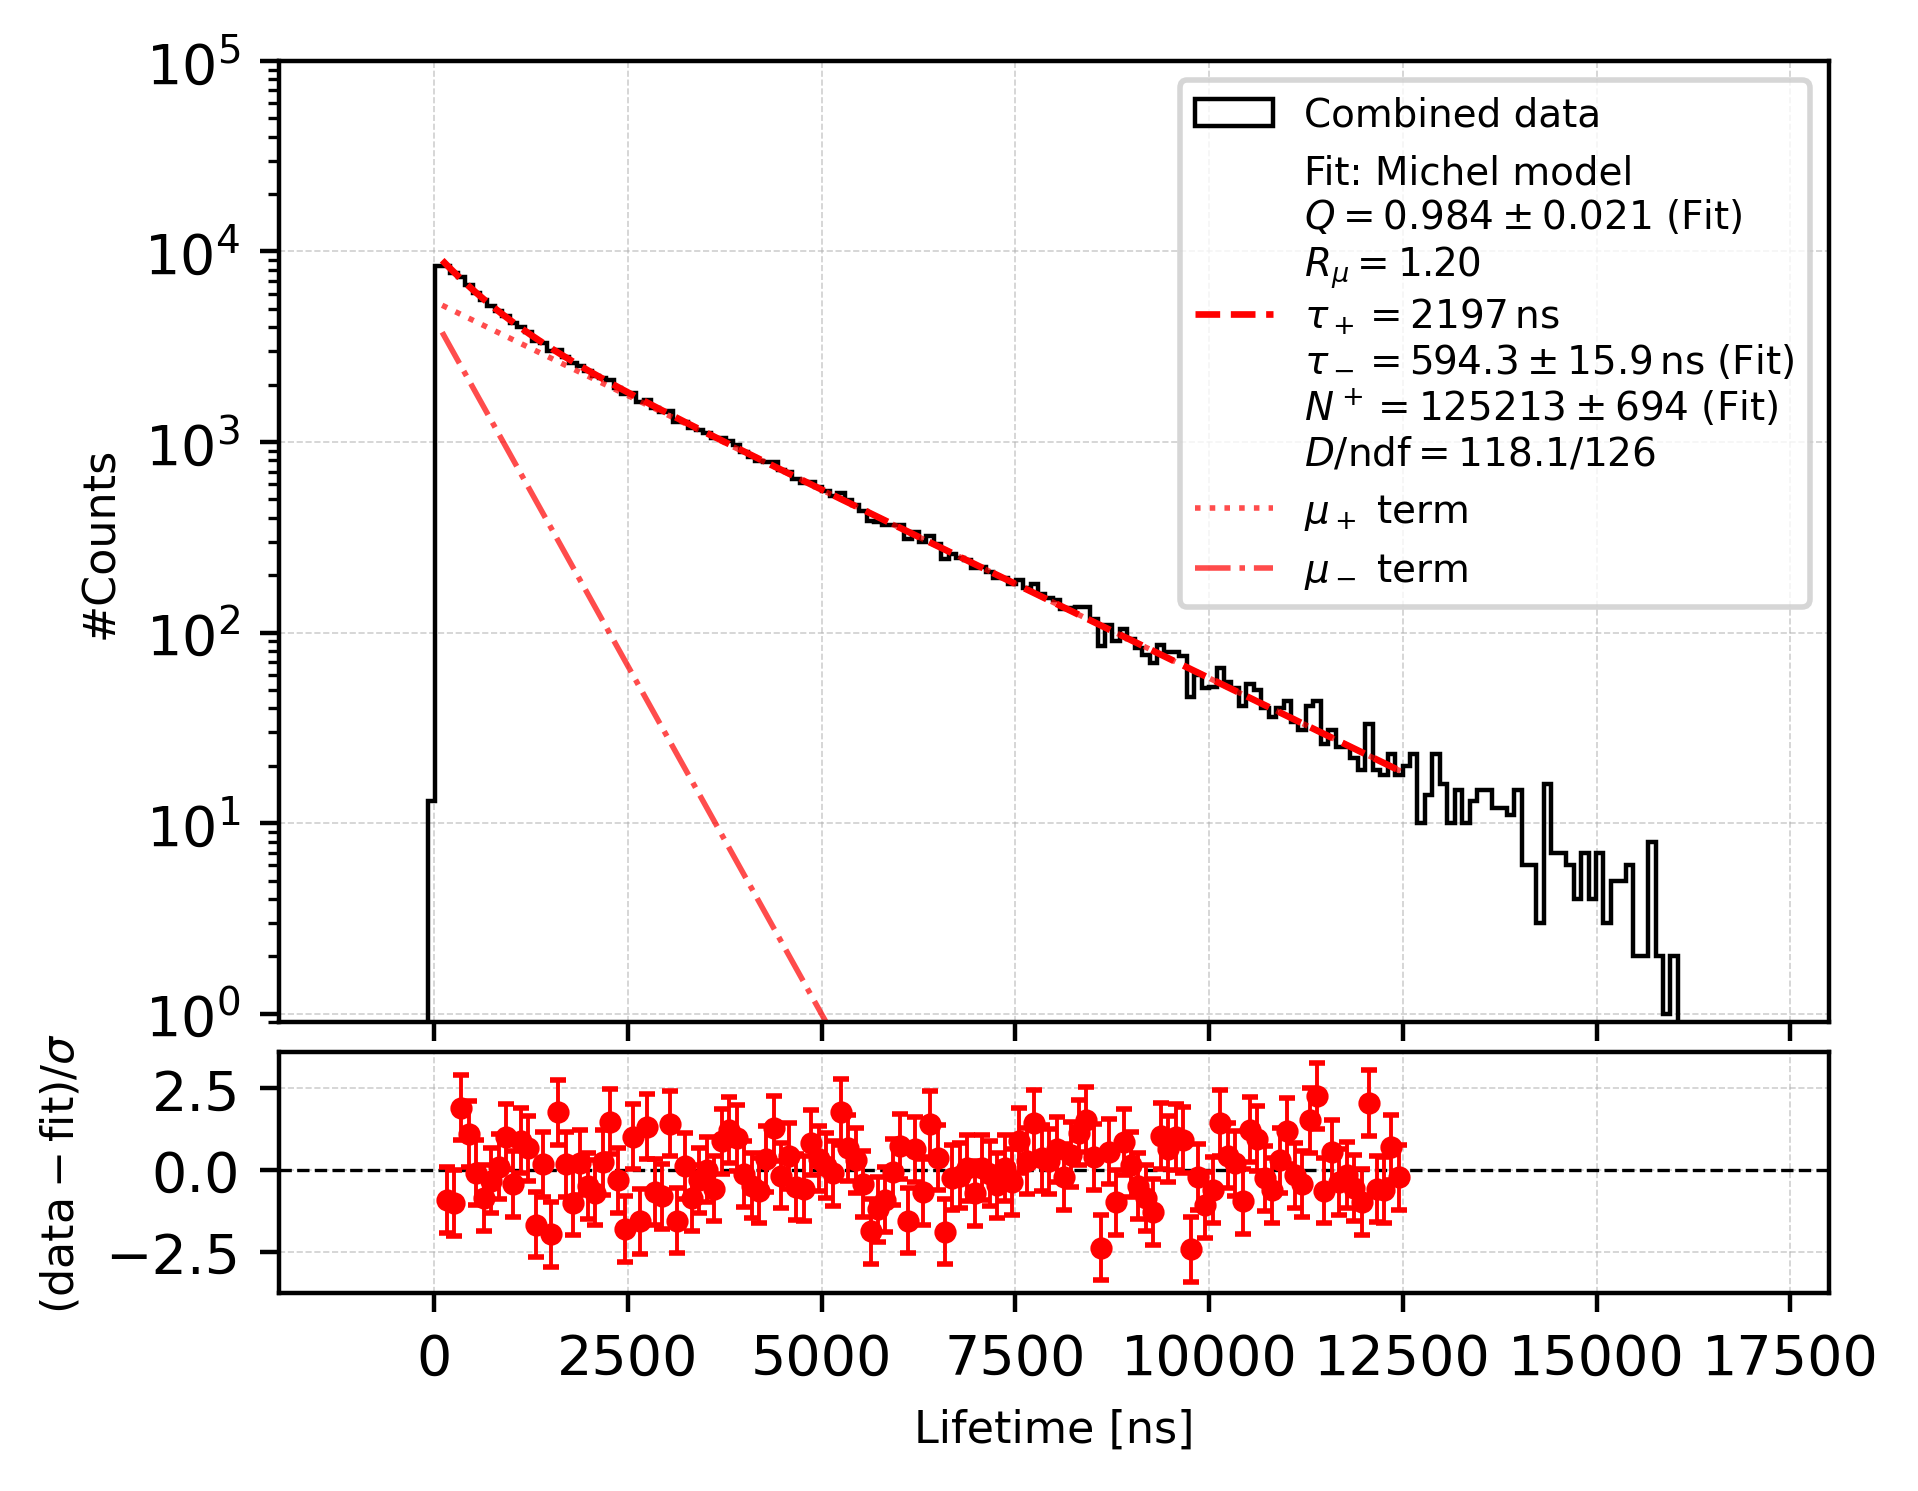

In [80]:
# ============================================================
# 5. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

fit_and_draw_binnedML_newFunc_Q(
    ax, ax_resid,
    np.asarray(lifetime_trueMichel_initial),
    "Combined",
    fit_range=(96, 12500),     # Fitting range
    hist_color="black",
    fit_color="red",
    show_components=True,
    tau1_init=1000.0,
    Q_init=0.8                # initial guess for Q (now a fit parameter)
)

# ============================================================
# 6. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
legend = ax.legend(
    loc='upper right',
    fontsize=7
)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />

### FITTING III (Fix R, only fluctuating N, tau1 and Q, tau2):

In [82]:
# ============================================================
# 3. Define bin-integrated physics model (Q and tau_mu_plus floating)
# ============================================================
def michel_integrated_newFunc_Q_tauplus(bin_edges, N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit,
                                        R_mu=1.2):
    """
    Integrated expected counts per bin for Michel e± from muon decays.

    Differential model:
      N(t) = N⁺ * [ (1/τ⁺) e^{-t/τ⁺} + (Q/(τ⁺ Rµ)) e^{-t/τ⁻} ]

    Bin-integrated over [a,b]:
      ΔN = N⁺ * [ (e^{-a/τ⁺} - e^{-b/τ⁺})
                  + (Q τ⁻ / (Rµ τ⁺)) (e^{-a/τ⁻} - e^{-b/τ⁻}) ].

    Parameters
    ----------
    N_plus          : normalization (mu+ decays)
    tau_mu_minus    : mu- effective lifetime (fit)
    Q_fit           : mu- survival / capture factor (fit)
    tau_mu_plus_fit : mu+ effective lifetime (now fit parameter)
    R_mu            : fixed ratio factor (default 1.2)
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    eps = 1e-12
    tau_mu_minus = np.maximum(float(tau_mu_minus), eps)
    tau_mu_plus_fit = np.maximum(float(tau_mu_plus_fit), eps)

    term_plus  = np.exp(-a / tau_mu_plus_fit)   - np.exp(-b / tau_mu_plus_fit)
    term_minus = np.exp(-a / tau_mu_minus)      - np.exp(-b / tau_mu_minus)

    return N_plus * (term_plus + (Q_fit * tau_mu_minus) / (R_mu * tau_mu_plus_fit) * term_minus)

#### Binned Maximum Likelihood + MINUIT:

In [83]:
# ============================================================
# Maximum likelihood fitting (binned Poisson deviance) with MINUIT (iminuit)
# + MINOS profile-likelihood errors (ΔD = 1)
# ============================================================
import numpy as np
from iminuit import Minuit


def fit_and_draw_binnedML_newFunc_Q_tauplus(ax, ax_resid, sample, label_prefix,
                                 fit_range=(200, 8000),
                                 hist_color="black", fit_color="red",
                                 show_components=True,
                                 tau1_init=1000.0,
                                 Q_init=0.988,
                                 tau_plus_init=2197.0):

    # Histogram in the global (range_min, range_max) window
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width_local = (bin_edges[1] - bin_edges[0])

    # Select fitting window (based on bin centers)
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    # Edges spanning the fit region
    i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
    edges_fit = bin_edges[i0:i1 + 2]

    eps = 1e-12

    def mu_model(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit):
        mu = michel_integrated_newFunc_Q_tauplus(edges_fit, N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit,
                                         R_mu=R_mu)
        return np.maximum(mu, eps)

    # Poisson deviance D = 2 Σ [μ - n + n ln(n/μ)]
    def deviance(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit):
        # hard bounds safety
        if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0):
            return 1e50
        if (Q_fit < 0.0) or (Q_fit > 1.2):
            return 1e50
        if (tau_mu_plus_fit < 1500.0) or (tau_mu_plus_fit > 3000.0):
            return 1e50

        mu = mu_model(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)

    # -------------------------
    # MINUIT fit (MIGRAD + HESSE + MINOS)
    # -------------------------
    N0 = float(np.sum(y))
    tau0 = float(tau1_init)
    Q0 = float(Q_init)
    taup0 = float(tau_plus_init)

    # Reasonable step sizes for Minuit
    N_err0 = max(1.0, np.sqrt(max(N0, 1.0)))
    tau_err0 = 50.0
    Q_err0 = 0.02
    taup_err0 = 20.0

    minuit = Minuit(deviance, N_plus=N0, tau_mu_minus=tau0, Q_fit=Q0, tau_mu_plus_fit=taup0)
    minuit.errordef = 1.0  # ΔD=1 corresponds to 1σ (1 parameter)

    # Bounds / limits
    minuit.limits["N_plus"] = (0.0, None)
    minuit.limits["tau_mu_minus"] = (100.0, 2000.0)
    minuit.limits["Q_fit"] = (0.0, 1.2)
    # mu+ lifetime is known precisely; keep it in a tight physics range for stability
    minuit.limits["tau_mu_plus_fit"] = (1500.0, 3000.0)

    # Initial step sizes (NOT final uncertainties)
    minuit.errors["N_plus"] = N_err0
    minuit.errors["tau_mu_minus"] = tau_err0
    minuit.errors["Q_fit"] = Q_err0
    minuit.errors["tau_mu_plus_fit"] = taup_err0

    # Run minimization
    mres = minuit.migrad()
    if (not mres.valid) or (not np.isfinite(minuit.fval)):
        print(f"[{label_prefix}] MINUIT MIGRAD failed/invalid")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None



    # Optional: refine covariance with HESSE
    minuit.hesse()

    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = minuit.covariance

    print("\n[Minuit] Parameter order:", minuit.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        params = list(minuit.parameters)
        namew = max(len(p) for p in params)

        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- correlation matrix ---
        print("\n[Minuit] Correlation matrix:")
        corr = cov.correlation()
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{corr[p1, p2]: .3f}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- highlight correlations with physics parameters ---
        for target in ("tau_mu_minus", "Q_fit", "tau_mu_plus_fit"):
            if target in params:
                print(f"\n[Minuit] Correlations with {target}:")
                for p in params:
                    if p == target:
                        continue
                    print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")






    N_plus_fit = float(minuit.values["N_plus"])
    tau_mu_minus_fit = float(minuit.values["tau_mu_minus"])
    Q_fit_best = float(minuit.values["Q_fit"])
    tau_mu_plus_fit = float(minuit.values["tau_mu_plus_fit"])

    D_min = float(minuit.fval)
    ndf = len(y) - 4

    # MINOS profile-likelihood errors (asymmetric in general)
    N_plus_err = np.nan
    tau_mu_minus_err = np.nan
    Q_fit_err = np.nan
    tau_mu_plus_err = np.nan

    try:
        minuit.minos("N_plus", "tau_mu_minus", "Q_fit", "tau_mu_plus_fit")

        if "N_plus" in minuit.merrors:
            e = minuit.merrors["N_plus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                N_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "tau_mu_minus" in minuit.merrors:
            e = minuit.merrors["tau_mu_minus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_minus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "Q_fit" in minuit.merrors:
            e = minuit.merrors["Q_fit"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                Q_fit_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "tau_mu_plus_fit" in minuit.merrors:
            e = minuit.merrors["tau_mu_plus_fit"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))

    except Exception as ex:
        print(f"[{label_prefix}] MINOS failed: {ex}")

    # -------------------------
    # Model expectation in the *fit bins* (for residuals)
    # -------------------------
    y_model = michel_integrated_newFunc_Q_tauplus(edges_fit, N_plus_fit, tau_mu_minus_fit, Q_fit_best, tau_mu_plus_fit,
                                          R_mu=R_mu)

    # Signed deviance residuals (Poisson)
    n = y
    mu = np.maximum(y_model, eps)
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu[nz] - n[nz] + n[nz] * np.log(n[nz] / mu[nz]))
    di[~nz] = 2.0 * mu[~nz]
    pulls = np.sign(n - mu) * np.sqrt(np.maximum(di, 0.0))

    # -------------------------
    # Draw data histogram
    # -------------------------
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    # -------------------------
    # Draw fitted model as a smooth curve with correct normalization
    # -------------------------
    fine_edges = np.linspace(fit_range[0], fit_range[1], 801)  # 800 tiny bins
    fine_centers = 0.5 * (fine_edges[:-1] + fine_edges[1:])
    fine_bin_width = fine_edges[1] - fine_edges[0]

    y_fine_total = michel_integrated_newFunc_Q_tauplus(fine_edges, N_plus_fit, tau_mu_minus_fit, Q_fit_best, tau_mu_plus_fit,
                                               R_mu=R_mu)
    y_curve_total = (y_fine_total / fine_bin_width) * bin_width

    ax.plot(
        fine_centers, y_curve_total,
        color=fit_color, linestyle='--', linewidth=1.2,
        label=(
            r"Fit: Michel model" "\n"
            + rf"$Q = {Q_fit_best:.3f} \pm {Q_fit_err:.3f}$ (Fit)" "\n"
            + rf"$R_\mu = {R_mu:.2f}$" "\n"
            + rf"$\tau_+ = {tau_mu_plus_fit:.1f} \pm {tau_mu_plus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$\tau_- = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$N^+ = {N_plus_fit:.0f} \pm {N_plus_err:.0f}$ (Fit)" "\n"
            + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"
        )
    )

    # Optional: draw the two component curves (now using fitted tau_mu_plus_fit and Q_fit_best)
    if show_components:
        comp_plus_fine = N_plus_fit * (
            np.exp(-fine_edges[:-1] / tau_mu_plus_fit) - np.exp(-fine_edges[1:] / tau_mu_plus_fit)
        )

        comp_minus_fine = N_plus_fit * (Q_fit_best * tau_mu_minus_fit) / (R_mu * tau_mu_plus_fit) * (
            np.exp(-fine_edges[:-1] / tau_mu_minus_fit) - np.exp(-fine_edges[1:] / tau_mu_minus_fit)
        )

        comp_plus_curve = (comp_plus_fine / fine_bin_width) * bin_width
        comp_minus_curve = (comp_minus_fine / fine_bin_width) * bin_width

        ax.plot(fine_centers, comp_plus_curve,
                linestyle=':', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_+$ term")

        ax.plot(fine_centers, comp_minus_curve,
                linestyle='-.', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_-$ term")

    # -------------------------
    # Residuals panel
    # -------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        centers[i0:i1 + 1], pulls,
        yerr=np.ones_like(pulls),
        fmt='o', color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT):")
    print(f"    Q       = {Q_fit_best:.6f} ± {Q_fit_err:.6f} (MINOS, ΔD=1)")
    print(f"    τ(μ⁺)   = {tau_mu_plus_fit:.3f} ± {tau_mu_plus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    τ(μ⁻)   = {tau_mu_minus_fit:.3f} ± {tau_mu_minus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    N^+     = {N_plus_fit:.1f} ± {N_plus_err:.1f} (MINOS, ΔD=1)")
    print(f"    D/ndf   = {D_min:.1f}/{ndf}")

    return (
        N_plus_fit, N_plus_err,
        tau_mu_minus_fit, tau_mu_minus_err,
        Q_fit_best, Q_fit_err,
        tau_mu_plus_fit, tau_mu_plus_err,
        D_min, ndf
    )

#### Fir and Run


[Minuit] Parameter order: ('N_plus', 'tau_mu_minus', 'Q_fit', 'tau_mu_plus_fit')

[Minuit] Covariance matrix (HESSE):
           N_plus:  2.0618e+06  -4.1352e+04  -7.8242e+00  -1.8876e+04
     tau_mu_minus: -4.1352e+04   1.1216e+03  -5.1441e-01   3.7026e+02
            Q_fit: -7.8242e+00  -5.1441e-01   2.0060e-03   1.7262e-01
  tau_mu_plus_fit: -1.8876e+04   3.7026e+02   1.7262e-01   2.3528e+02

[Minuit] Correlation matrix:
           N_plus:  1.000  -0.860  -0.122  -0.857
     tau_mu_minus: -0.860   1.000  -0.343   0.721
            Q_fit: -0.122  -0.343   1.000   0.251
  tau_mu_plus_fit: -0.857   0.721   0.251   1.000

[Minuit] Correlations with tau_mu_minus:
  corr(tau_mu_minus, N_plus) = -0.860
  corr(tau_mu_minus, Q_fit) = -0.343
  corr(tau_mu_minus, tau_mu_plus_fit) =  0.721

[Minuit] Correlations with Q_fit:
  corr(Q_fit, N_plus) = -0.122
  corr(Q_fit, tau_mu_minus) = -0.343
  corr(Q_fit, tau_mu_plus_fit) =  0.251

[Minuit] Correlations with tau_mu_plus_fit:
  corr(tau_mu_plus_

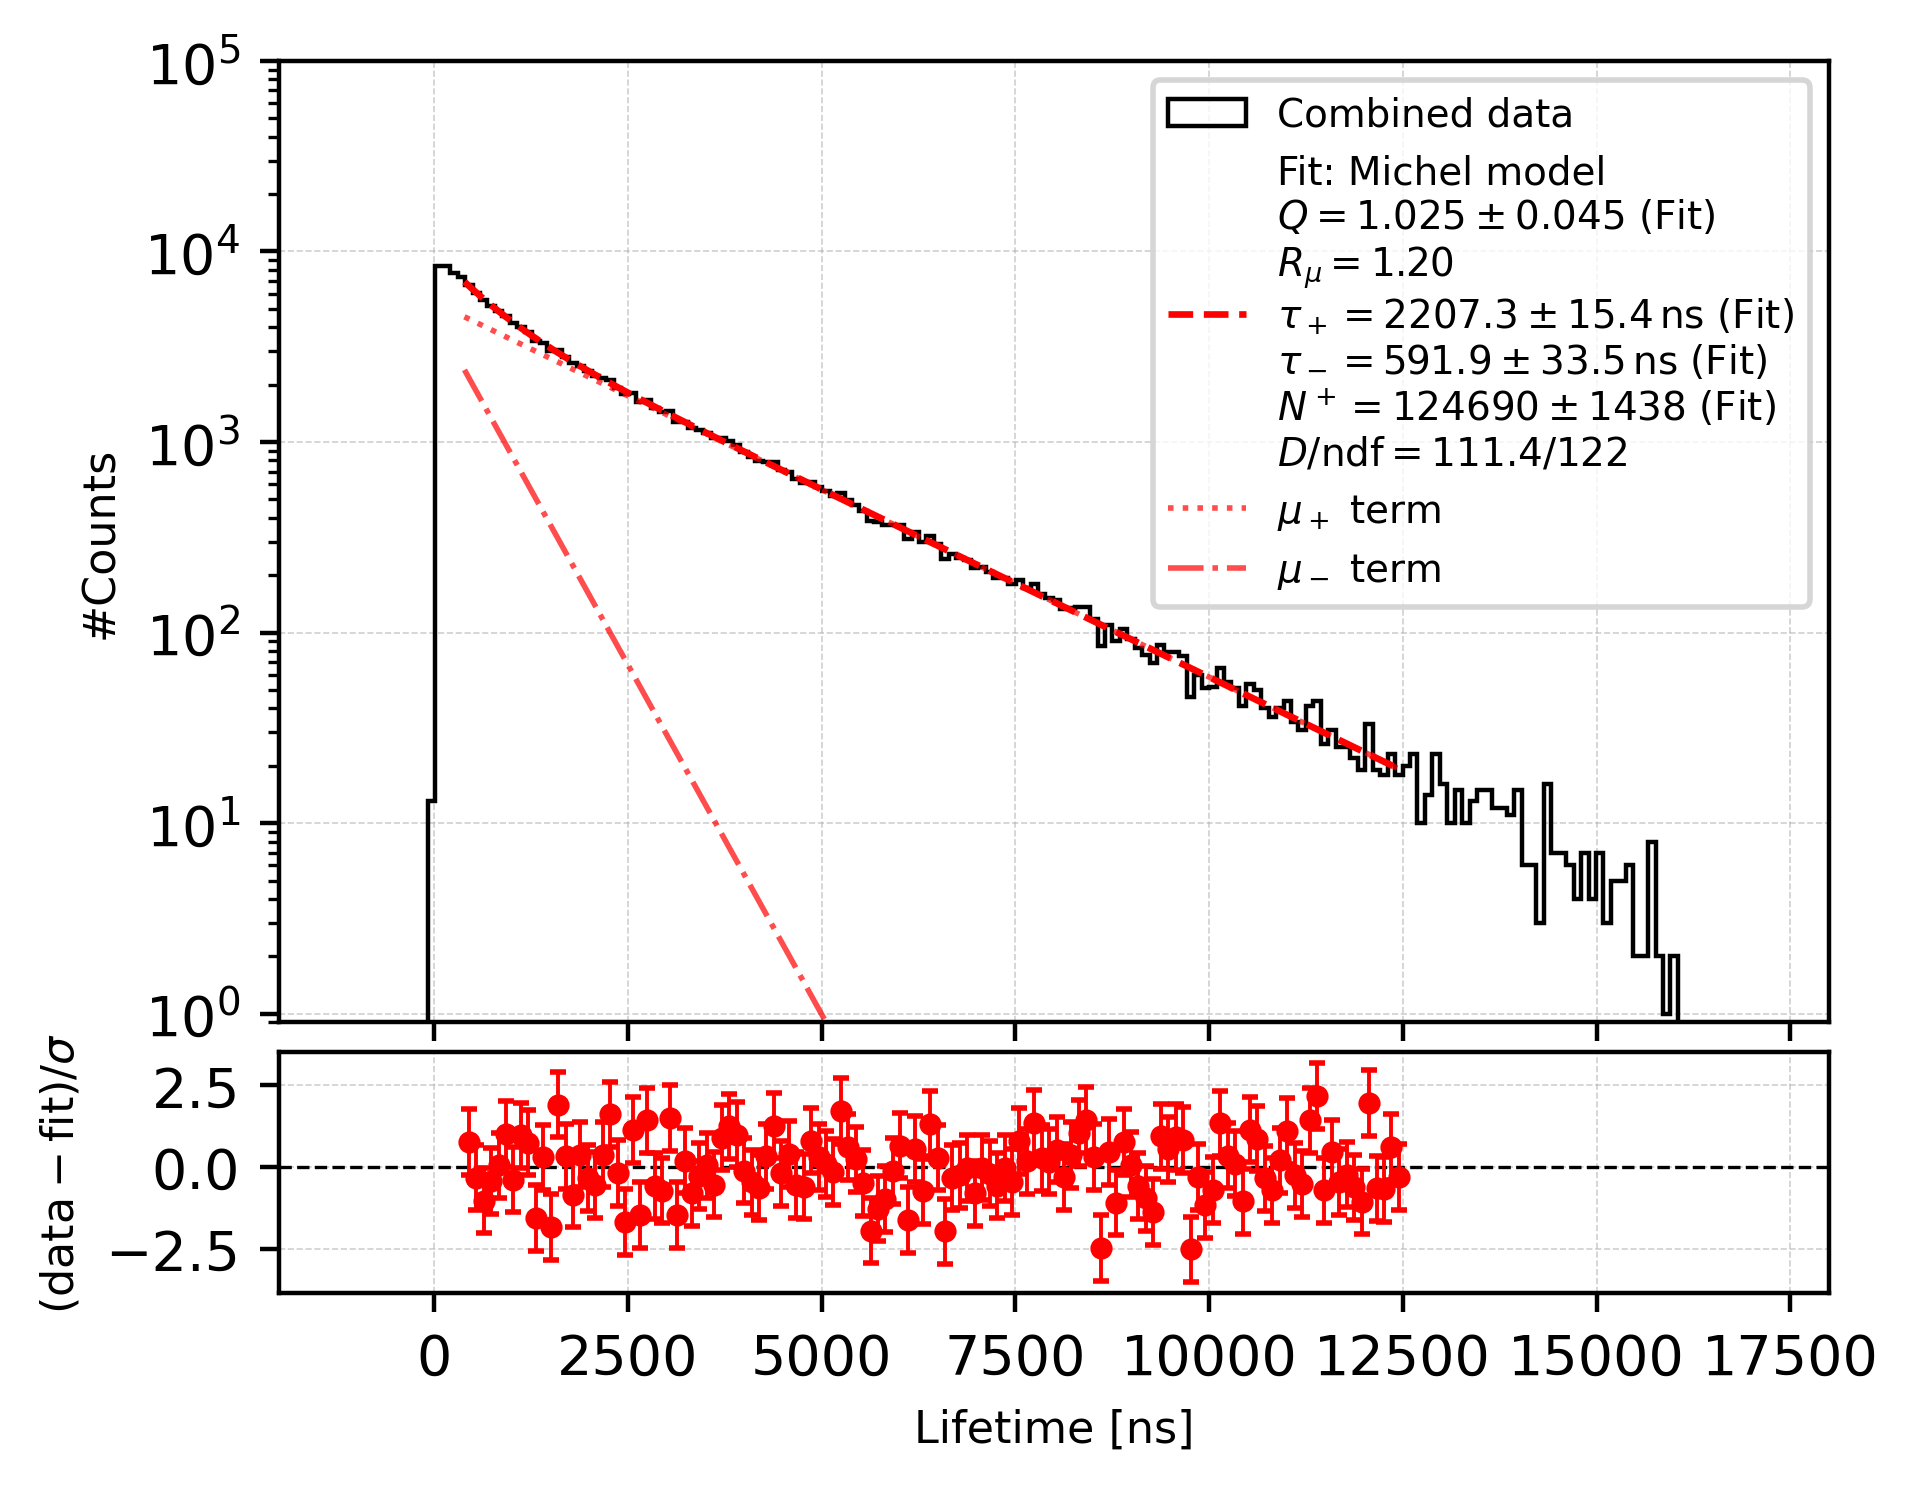

In [84]:

# ============================================================
# 5. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

fit_and_draw_binnedML_newFunc_Q_tauplus(
    ax, ax_resid,
    np.asarray(lifetime_trueMichel_initial),
    "Combined",
    fit_range=(384, 12500),     # Fitting range
    hist_color="black",
    fit_color="red",
    show_components=True,
    tau1_init=1000.0,
    Q_init=0.8,                 # initial guess for Q (fit parameter)
    tau_plus_init=3000.0        # initial guess for tau_mu_plus (fit parameter)
)

# ============================================================
# 6. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
legend = ax.legend(
    loc='upper right',
    fontsize=7
)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)
plt.show()


<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [86]:
initial_MS_reco = []#To be consistent with data---
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---

initial_MS_true = []
Space_events_true = []
MS_events_true = []
MH_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

    if 0.01 < MS:
        initial_MS_reco.append(ev)
        if E > 0:
            initial_MS_true.append(ev)

        #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
        if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
            Space_events_reco.append(ev)
            if E > 0:
                Space_events_true.append(ev)

            if  MS > 0.2: #(Michel score cut)---
                MS_events_reco.append(ev)
                if E > 0:
                    MS_events_true.append(ev)
            
                if MH > 2: #Michel hits cut---                
                    MH_events_reco.append(ev)
                    if E > 0:
                        MH_events_true.append(ev) 
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))
print("True events (initial): ", len(events_true), "({:.2f}%)".format(len(events_true)/len(events_reco)*100))

print("\nReco events (MS>0.1): ", len(initial_MS_reco))
print("True events (MS>0.1): ", len(initial_MS_true), "({:.2f}%)".format(len(initial_MS_true)/len(initial_MS_reco)*100))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))
print("True events (Space cut): ", len(Space_events_true), "({:.2f}%)".format(len(Space_events_true)/len(Space_events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))
print("True events (Space & MS cuts): ", len(MS_events_true), "({:.2f}%)".format(len(MS_events_true)/len(MS_events_reco)*100))


print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(MH_events_true), "({:.2f}%)".format(len(MH_events_true)/len(MH_events_reco)*100))








Reco events (initial):  664738
True events (initial):  150372 (22.62%)

Reco events (MS>0.1):  664738
True events (MS>0.1):  150372 (22.62%)

Reco events (Space cut):  324729 (48.85%)
True events (Space cut):  130365 (40.15%)

Reco events (Space & MS cuts):  160873 (24.20%)
True events (Space & MS cuts):  112708 (70.06%)

Reco events (Space & MS & MH cuts):  150427 (22.63%)
True events (Space & MS & MH cuts):  109858 (73.03%)



### Apply all cuts:

In [100]:

TPC_events_reco = [] # After Space & MS & MH cuts---

TPC_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.3 < MS: #(Michel score cut)---
            
            if 3 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)
                if E > 0:
                    TPC_events_true.append(ev) 



print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(TPC_events_true), 
      "({:.2f}%)".format(len(TPC_events_true)/len(TPC_events_reco)*100))





Reco events (Space & MS & MH cuts):  125185 (18.83%)
True events (Space & MS & MH cuts):  100678 (80.42%)


Decay points distribution (After TPC cut): 
# of X < 0 :  60709 (40.358%)
# of X >= 0:  89718 (59.642%)

#decayX_TPC (total):  150427
#decayX_apa1:  5867 (3.90%)
#decayX_apa2:  54842 (36.46%)
#decayX_apa3:  38472 (25.58%)
#decayX_apa4:  51246 (34.07%)


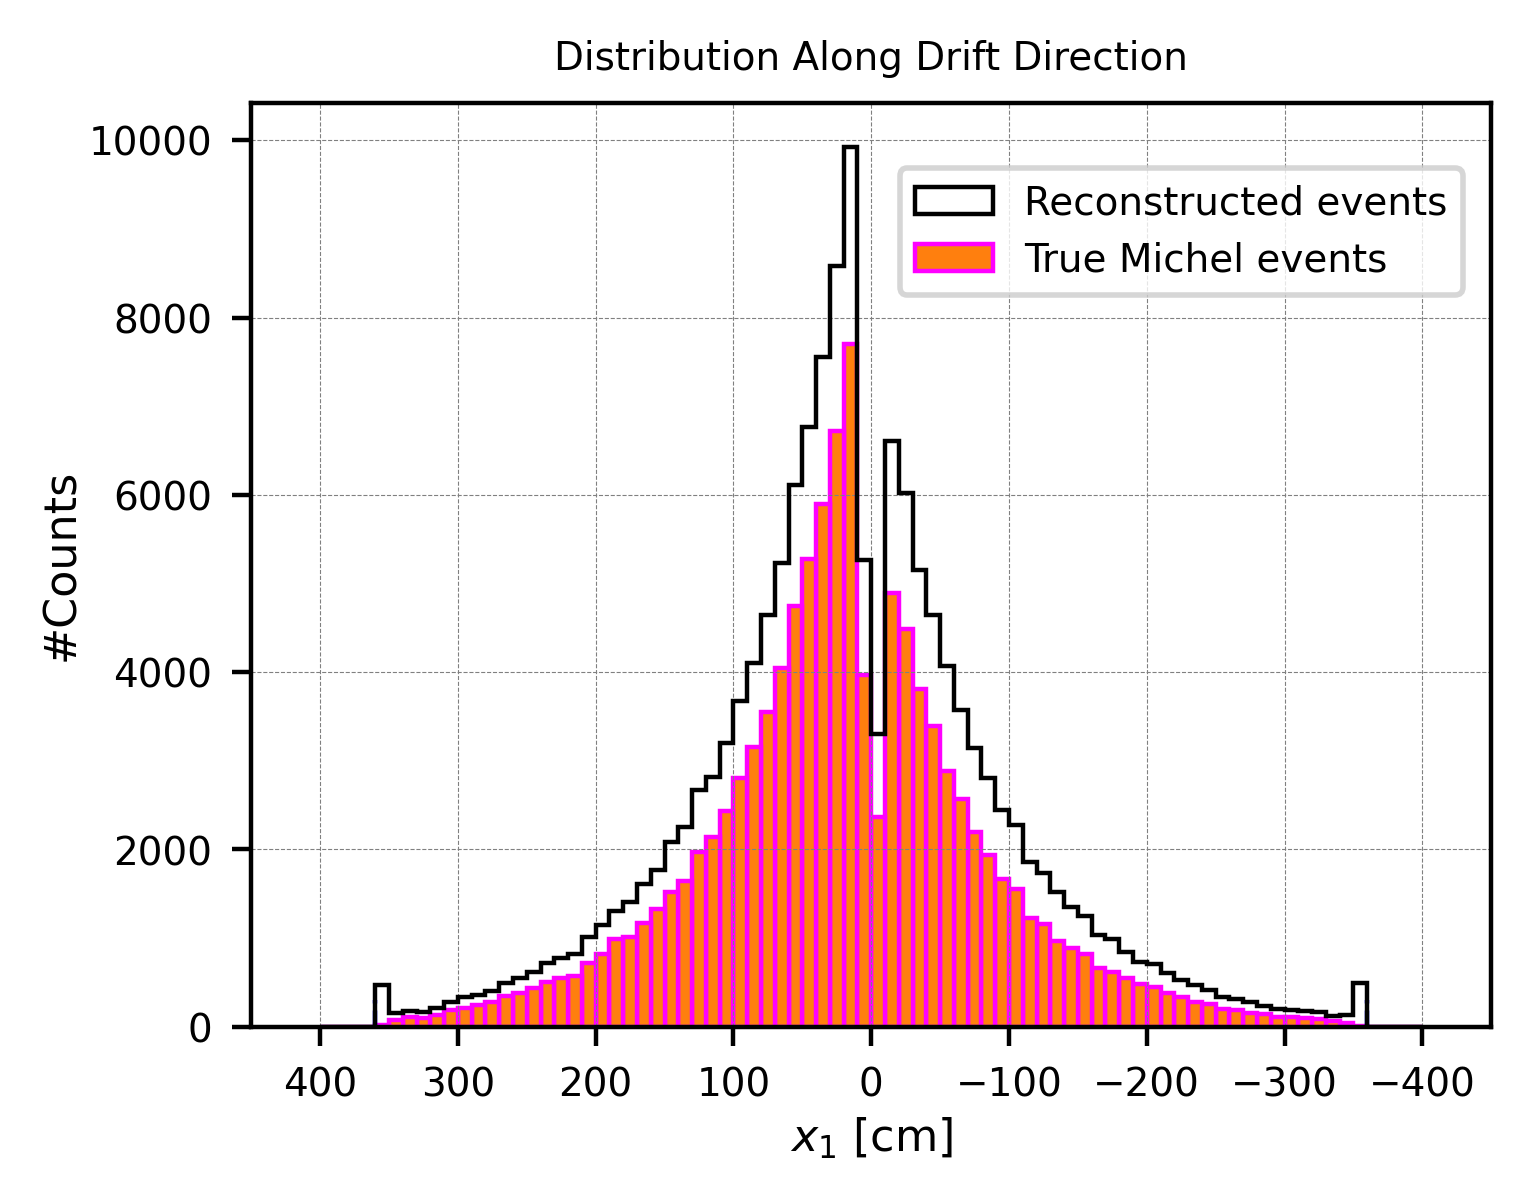

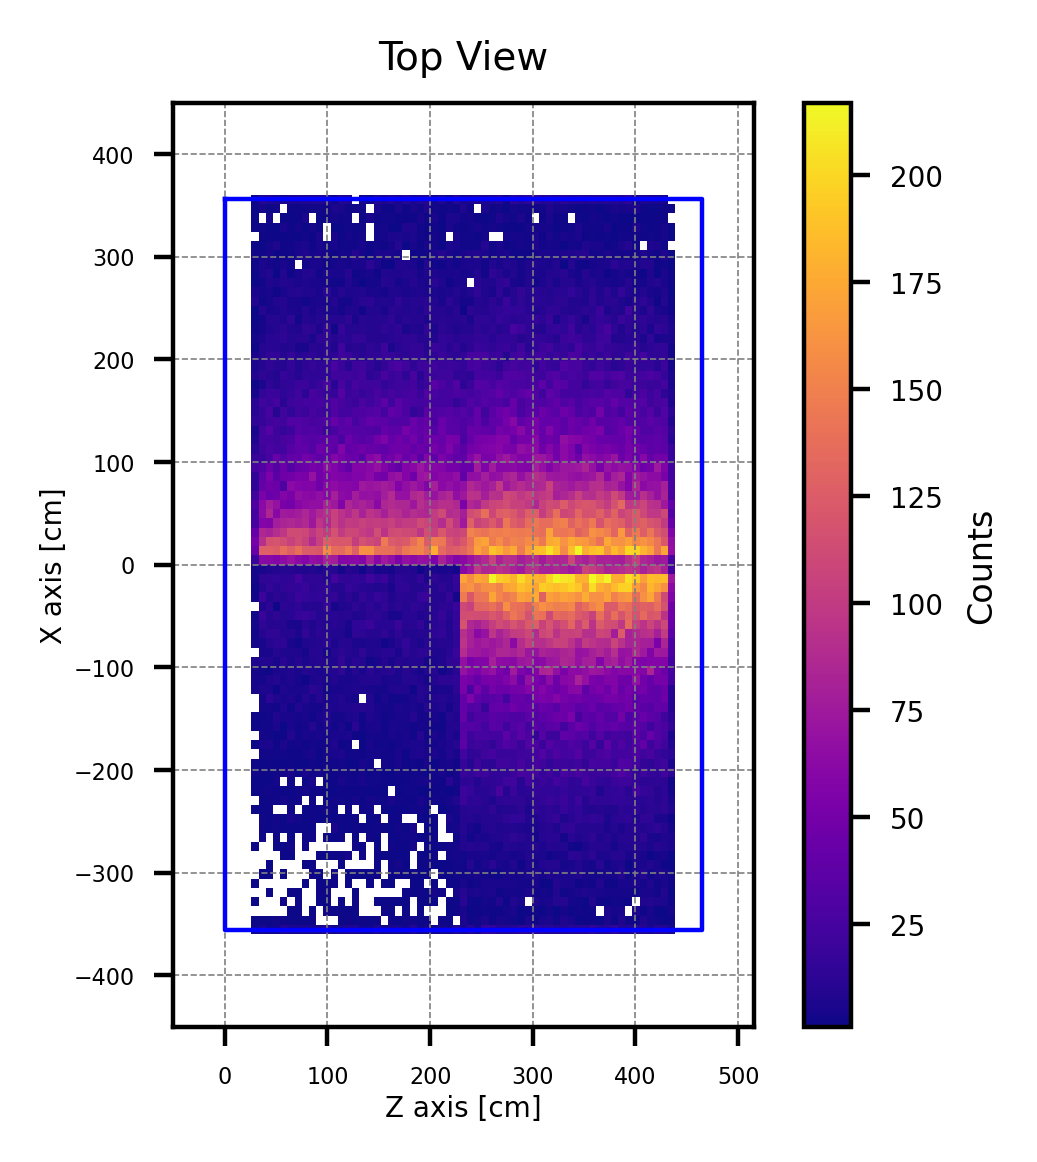

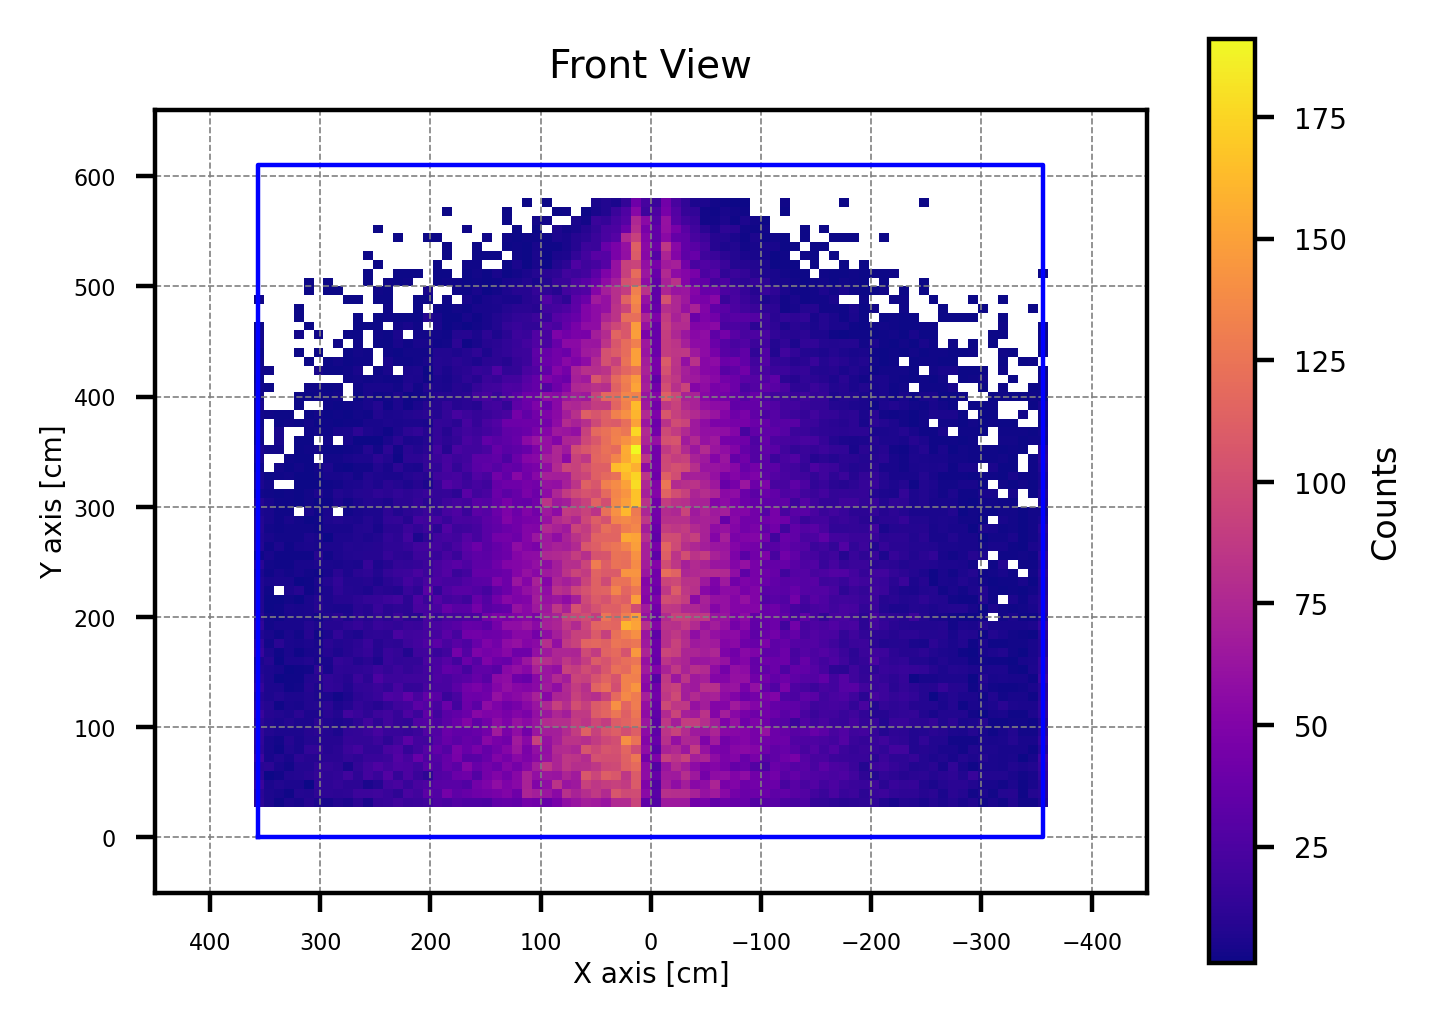

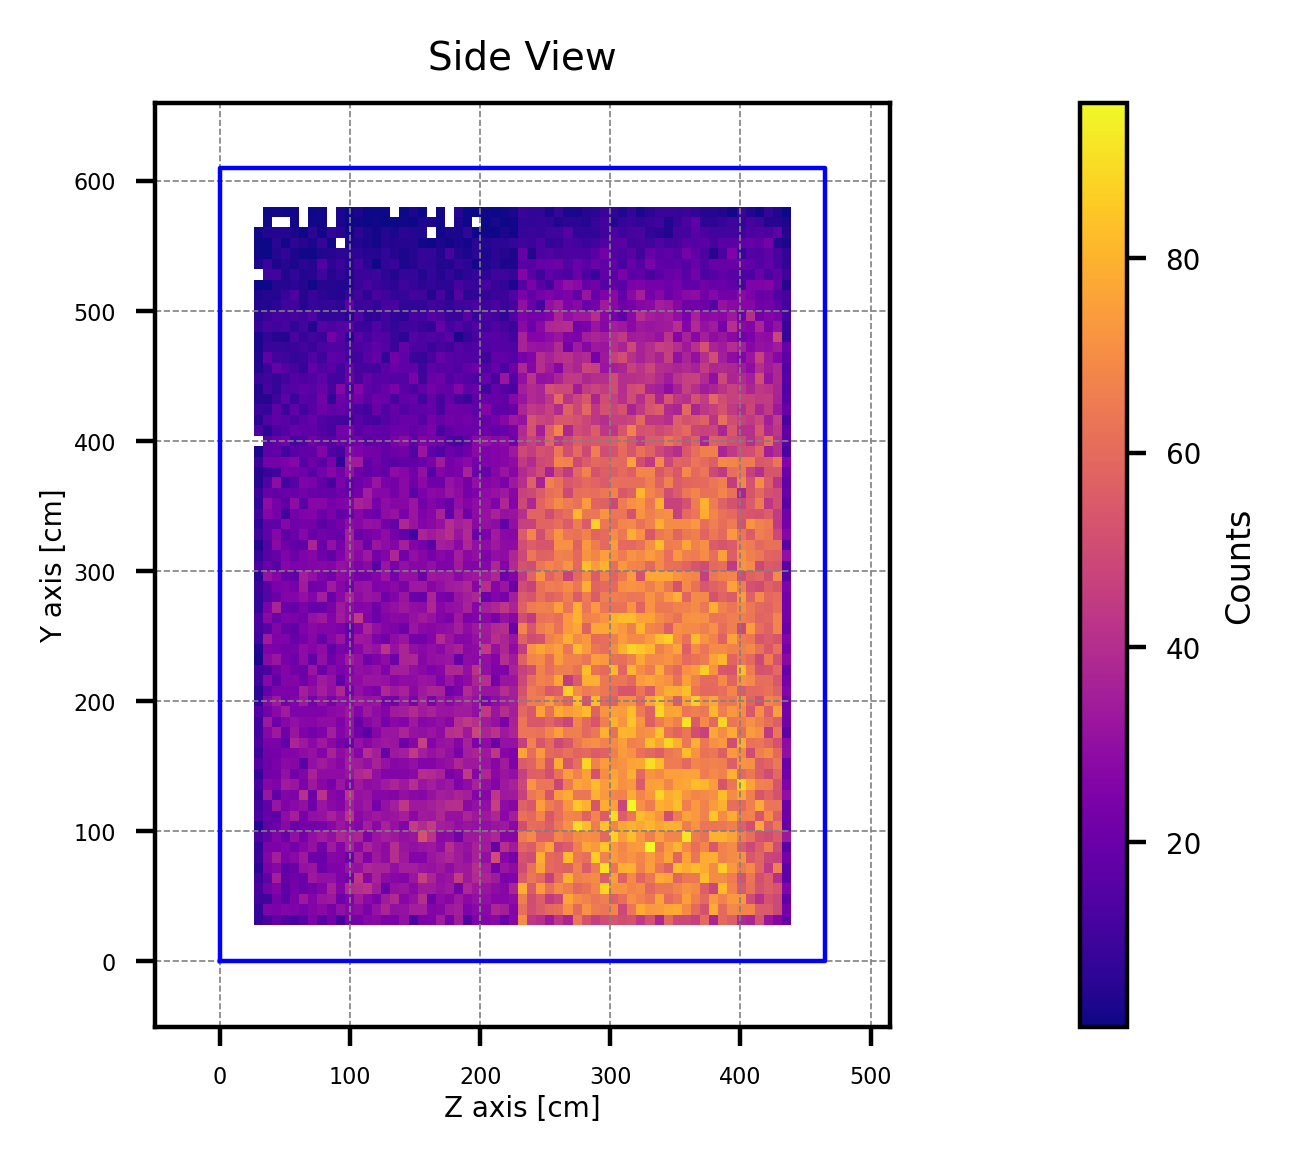

<Figure size 1600x1200 with 0 Axes>

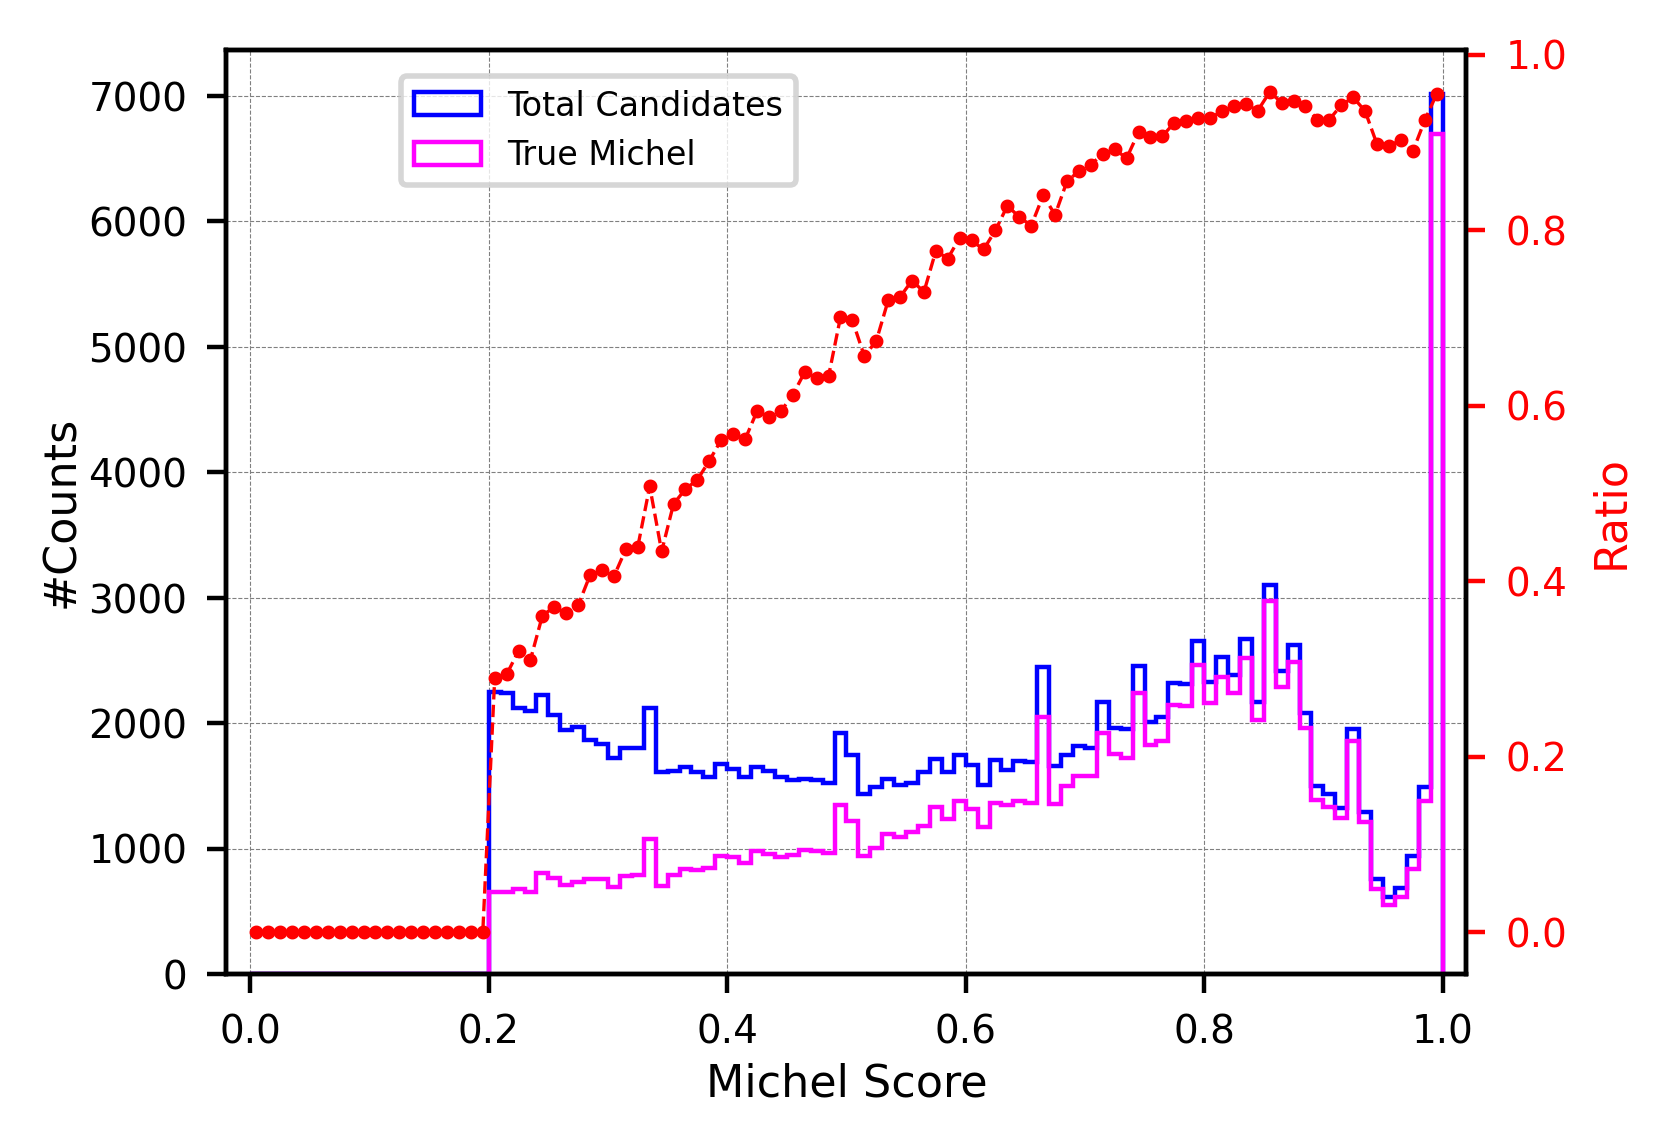

<Figure size 1600x1200 with 0 Axes>

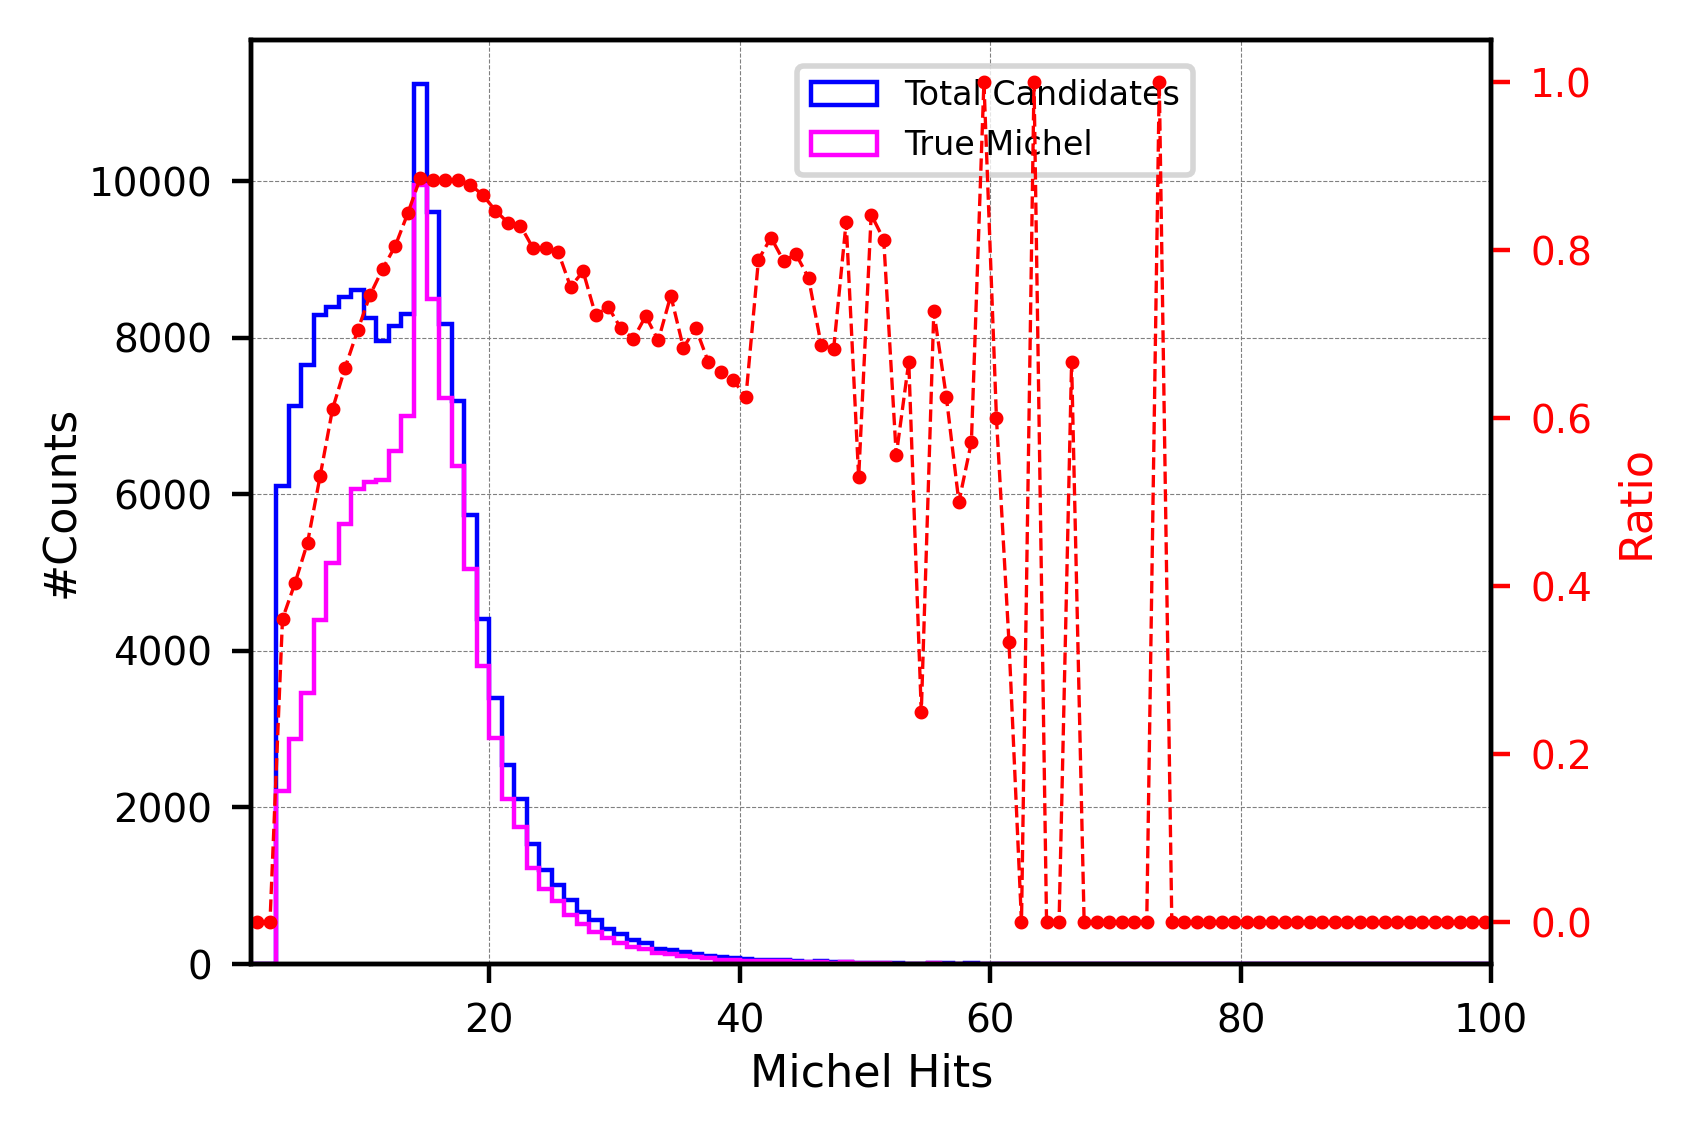




Starting points distribution: 


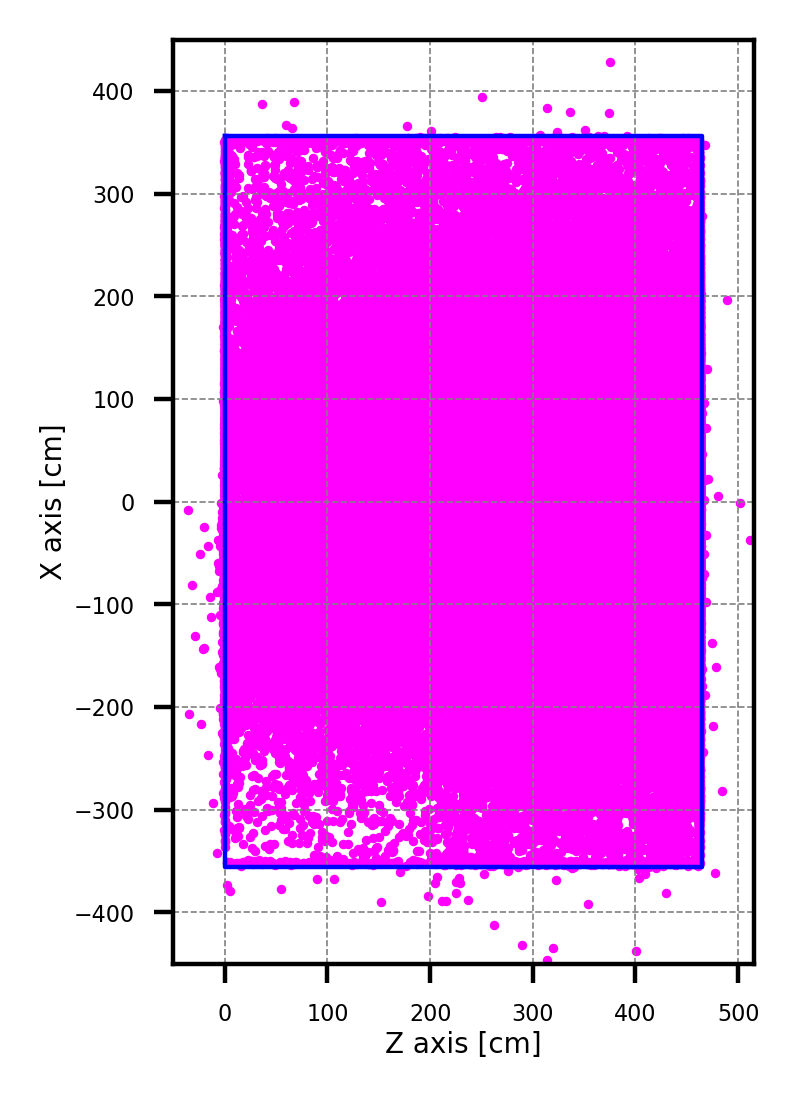

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]


TPC_X_true = [ev.decayX_initial for ev in TPC_events_true]
TPC_Y_true = [ev.decayY_initial for ev in TPC_events_true]
TPC_Z_true = [ev.decayZ_initial for ev in TPC_events_true]
TPC_MS_true = [ev.MS_initial for ev in TPC_events_true]
TPC_MH_true = [ev.MH_initial for ev in TPC_events_true]




#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(TPC_X_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(100, 100), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 









#Michel score distribution ----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MS, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show()









 

#Michel hits distribution -----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MH, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show() 








#Starting points distribution:==========================================
print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()



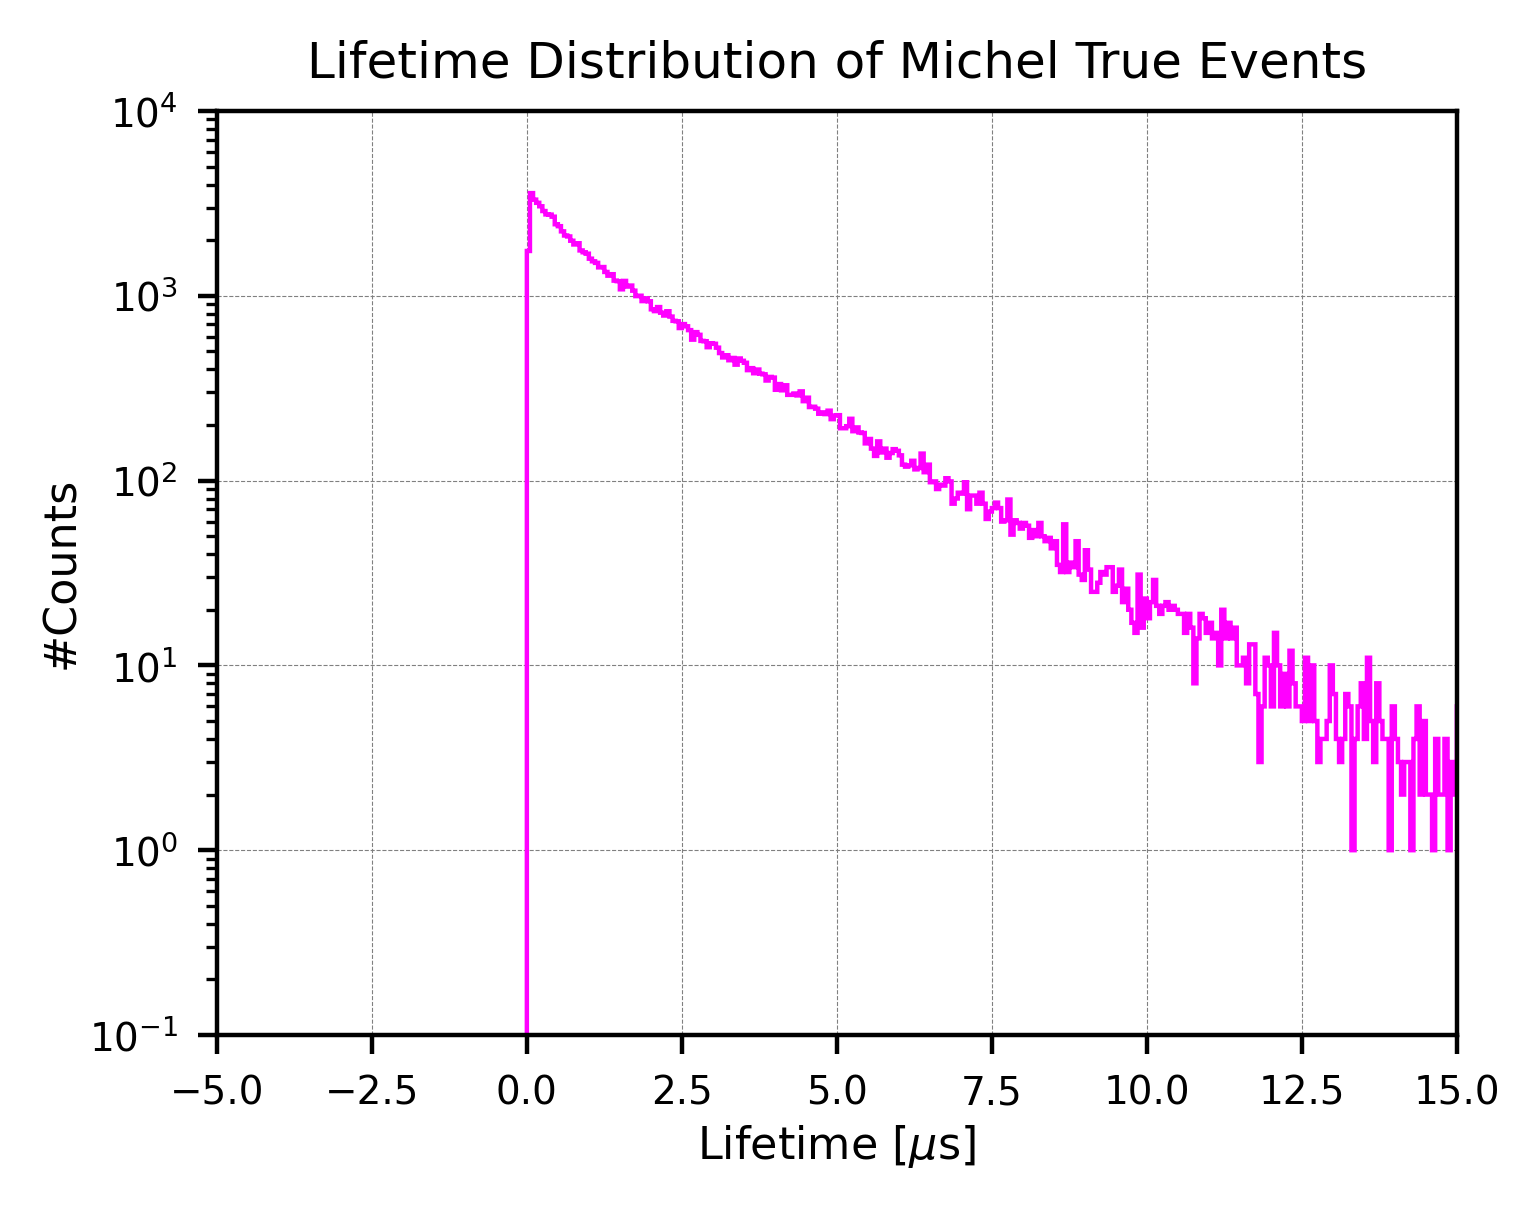

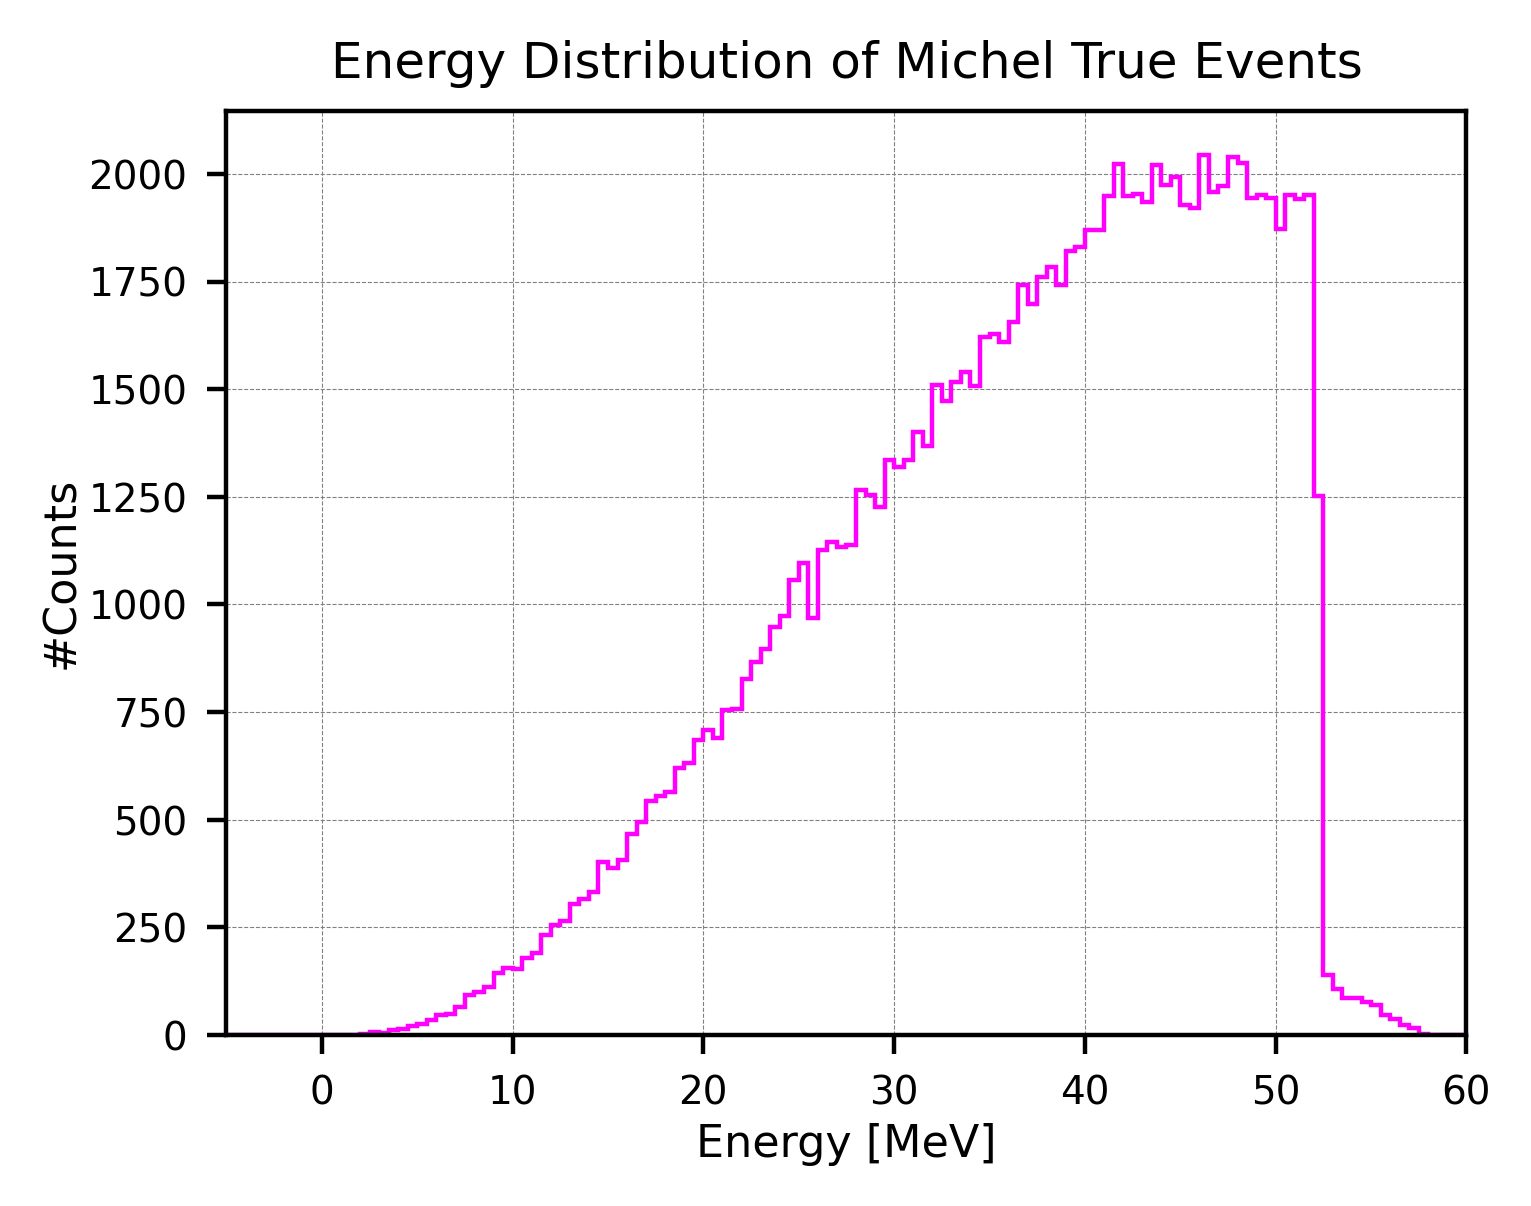

In [91]:

TPC_lifetime_true = [ev.lifetime_initial for ev in TPC_events_true]
TPC_energy_true = [ev.energy_initial for ev in TPC_events_true]


#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 15)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 10000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  










#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  


### New fittings:

(TPC cut) Michel e^+  :  90370 / 150427 (60.08%)
(TPC cut) Michel e^-  :  19488 / 150427 (12.96%)
(TPC cut) False Michel:  19488 / 150427 (12.96%)


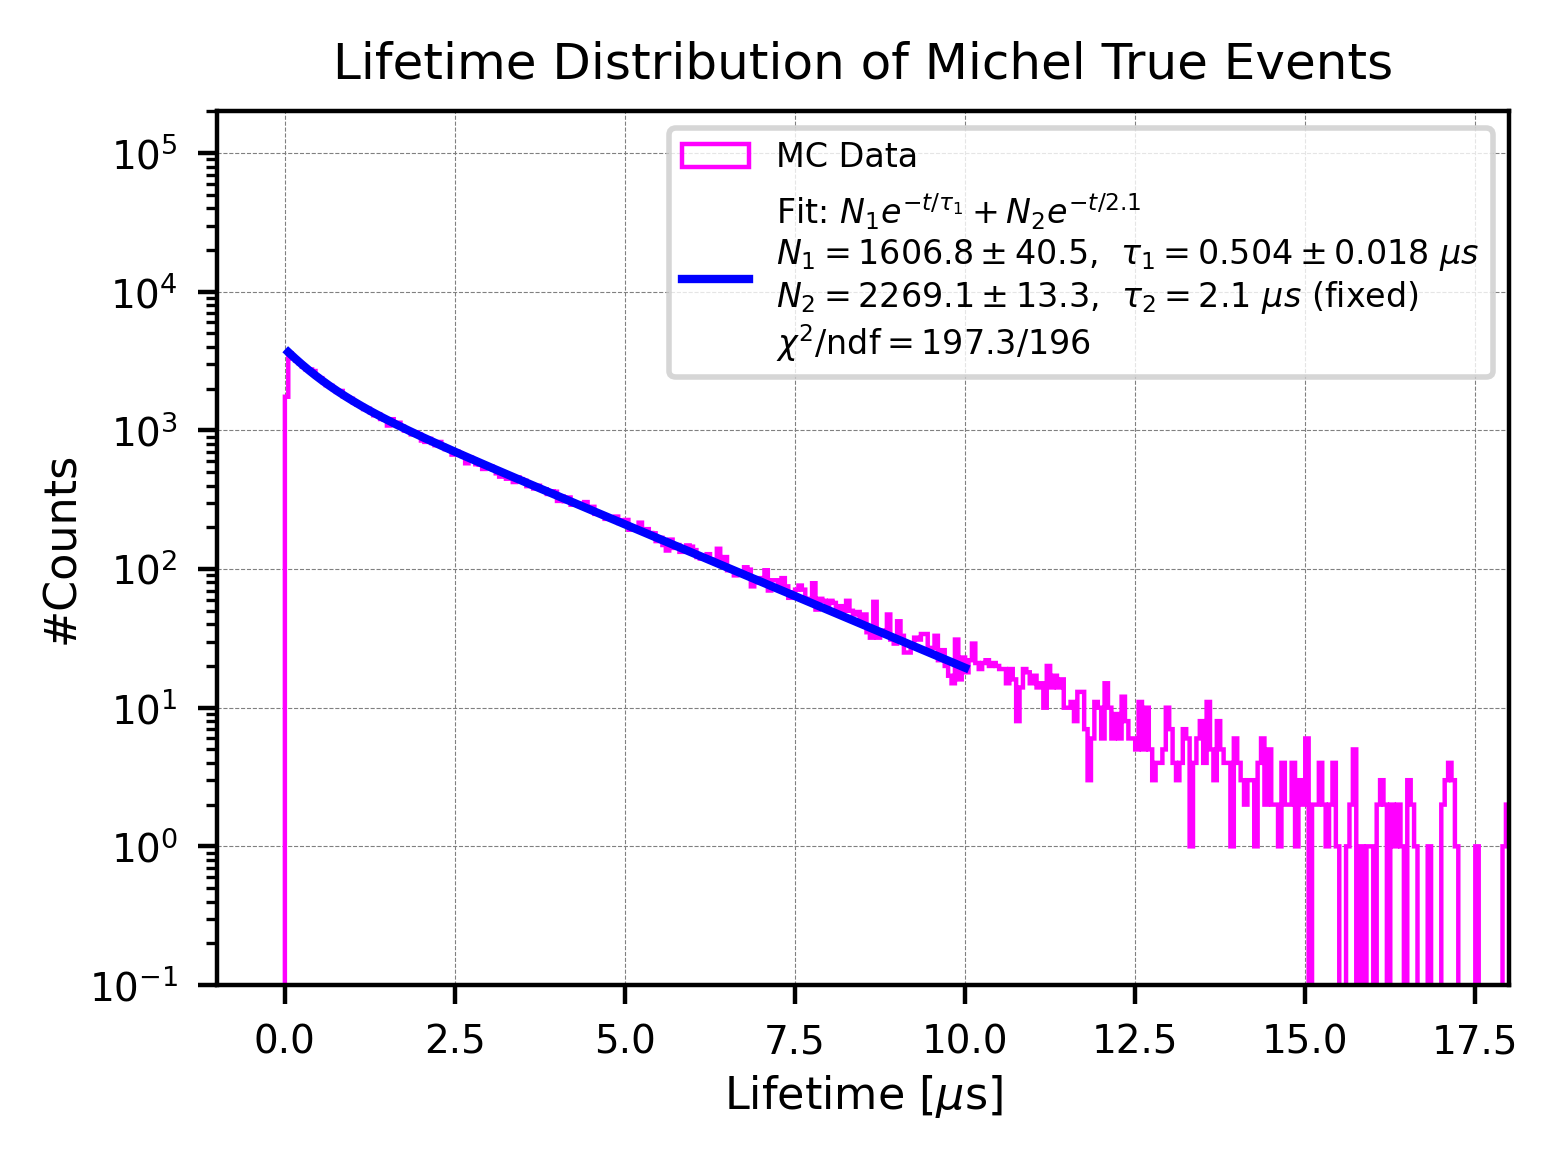

N1 = 1606.770 ± 40.531
tau1 = 0.50400 ± 0.01756 us
N2 = 2269.055 ± 13.292
chi2/ndf = 197.27/196 = 1.006


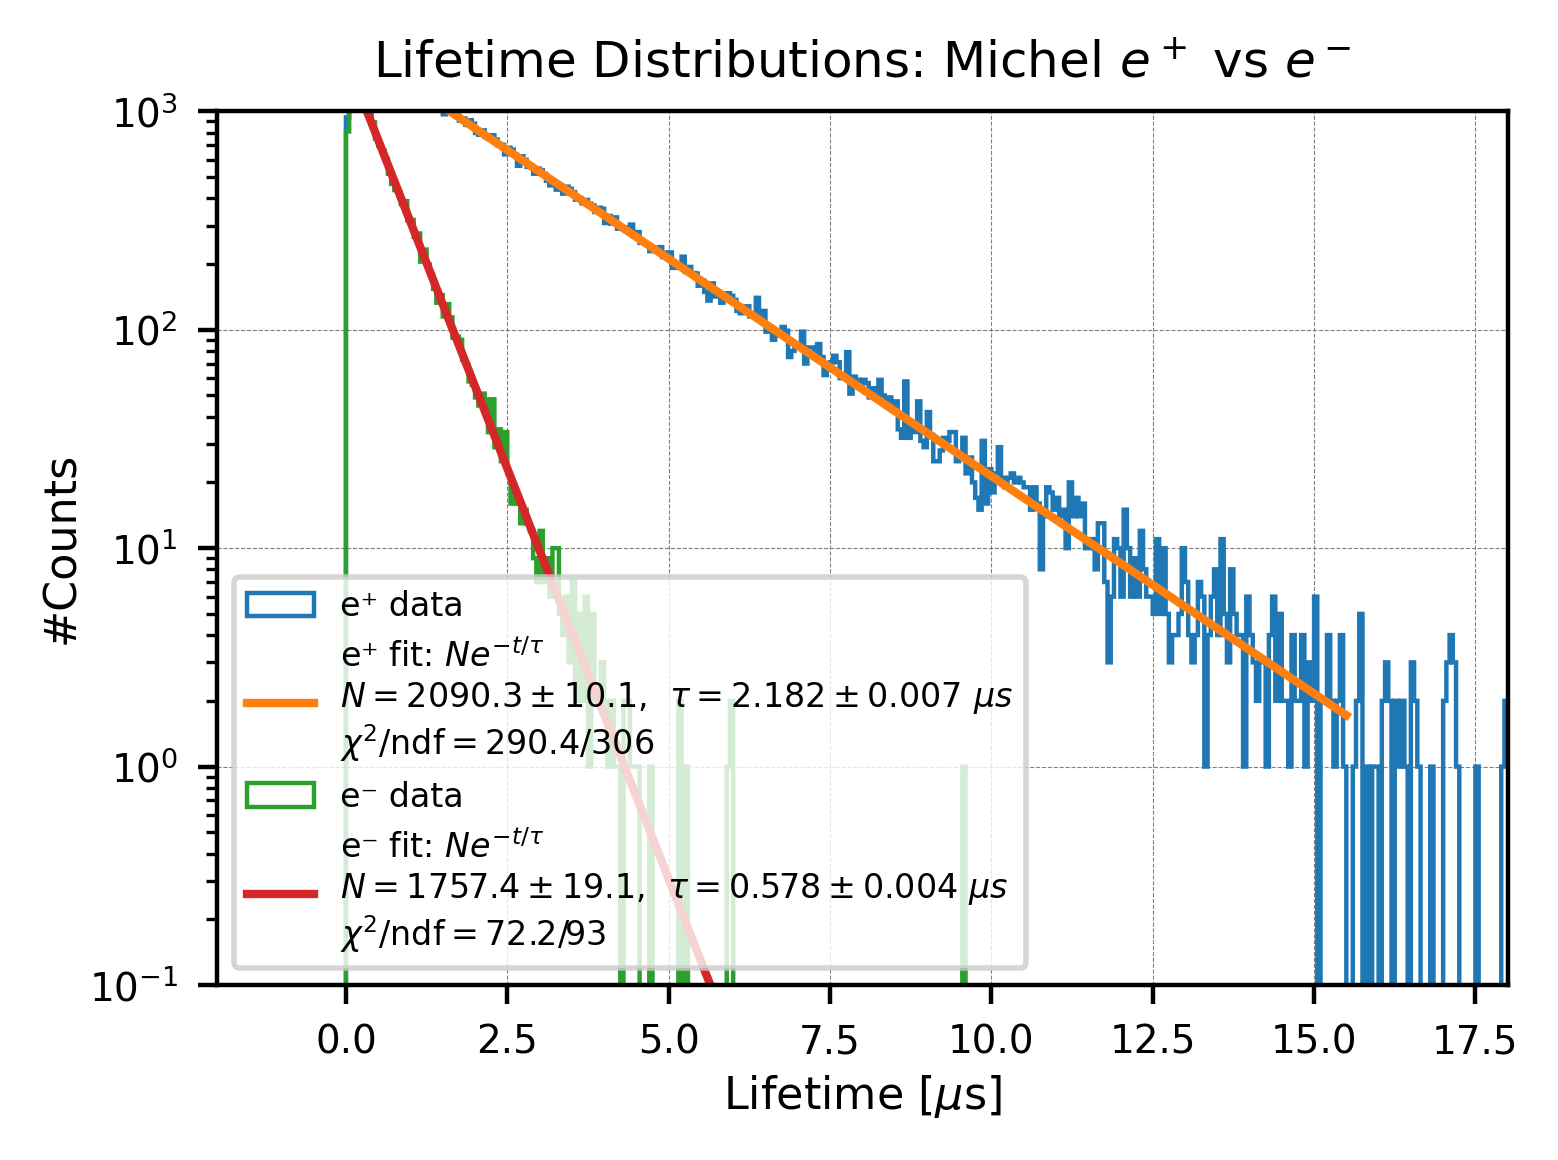

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# Seperate Michel e^- and e^+ (true events)------------------------------
TPC_life_pM = []
TPC_life_nM = []
count = 0
for ev in TPC_events_reco:
    pdg = ev.pdg_initial
    life = ev.lifetime_initial

    if pdg < 0:
        TPC_life_pM.append(life)
    elif pdg > 0:
        TPC_life_nM.append(life)
    elif pdg == 0:
        count += 1

print("(TPC cut) Michel e^+  : ", len(TPC_life_pM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_pM)/len(TPC_events_reco)*100))
print("(TPC cut) Michel e^-  : ", len(TPC_life_nM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_nM)/len(TPC_events_reco)*100))
print("(TPC cut) False Michel: ", len(TPC_life_nM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_nM)/len(TPC_events_reco)*100))








# Define the new exponential decay function===========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Exponential decay model (bin-by-bin, tau2 fixed)
# ============================================================
def exp_decay(t, N1, tau1, N2):
    return N1 * np.exp(-t / tau1) + N2 * np.exp(-t / 2.1)

# ============================================================
# Histogram setup
# ============================================================
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Histogram the data
counts, bin_edges = np.histogram(TPC_lifetime_true, bins=bins, range=(range_min, range_max))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# ============================================================
# Select fitting region
# ============================================================
fit_mask = (bin_centers >= 0.05) & (bin_centers <= 10)
x_fit_all = bin_centers[fit_mask]
y_fit_all = counts[fit_mask]

# Skip zero bins (avoid div by 0 in weights)
nz = y_fit_all > 0
x_fit = x_fit_all[nz]
y_fit = y_fit_all[nz]
sigma = np.sqrt(y_fit)  # Poisson errors

# ============================================================
# Initial guesses
# ============================================================
N1_0 = float(np.max(y_fit)) if y_fit.size else 1.0
tau1_0 = 2.0
N2_0 = max(N1_0 / 10.0, 1.0)

# ============================================================
# Weighted least squares fit
# ============================================================
popt, pcov = curve_fit(
    exp_decay, x_fit, y_fit,
    p0=[N1_0, tau1_0, N2_0],
    sigma=sigma,
    absolute_sigma=True,
    bounds=([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf]),
    maxfev=20000,
)
N1_fit, tau1_fit, N2_fit = popt
perr = np.sqrt(np.diag(pcov))
N1_err, tau1_err, N2_err = perr

# ============================================================
# Chi² / ndf
# ============================================================
y_exp = exp_decay(x_fit, *popt)
residual = (y_fit - y_exp) / sigma
chi2 = np.sum(residual**2)
ndf = max(len(x_fit) - len(popt), 1)
chi2_ndf = chi2 / ndf

# ============================================================
# Smooth curve for plotting
# ============================================================
x_smooth = np.linspace(0.05, 10, 500)
y_smooth = exp_decay(x_smooth, *popt)

# ============================================================
# Plot histogram
# ============================================================
plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8, label="MC Data")

# Plot fitted curve
plt.plot(
    x_smooth, y_smooth, 'b-',
    label=(
        r'Fit: $N_1 e^{-t/\tau_1} + N_2 e^{-t/2.1}$' + '\n'
        + rf'$N_1={N1_fit:.1f}\pm{N1_err:.1f}$,  $\tau_1={tau1_fit:.3f}\pm{tau1_err:.3f}\ \mu s$' + '\n'
        + rf'$N_2={N2_fit:.1f}\pm{N2_err:.1f}$,  $\tau_2=2.1\ \mu s$ (fixed)' + '\n'
        + rf'$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$'
    )
)

# ============================================================
# Style
# ============================================================
plt.xlim(-1, 18)
plt.ylim(0.1, 200000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()

# ============================================================
# Print results
# ============================================================
print(
    f"N1 = {N1_fit:.3f} ± {N1_err:.3f}\n"
    f"tau1 = {tau1_fit:.5f} ± {tau1_err:.5f} us\n"
    f"N2 = {N2_fit:.3f} ± {N2_err:.3f}\n"
    f"chi2/ndf = {chi2:.2f}/{ndf} = {chi2_ndf:.3f}"
)













#Fitting seperating for Michel e^+ and e^-===============================================

# --- single exponential ---
def exp1(t, N, tau):
    return N * np.exp(-t / tau)

# --- plotting / binning setup ---
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.05
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- helper: weighted fit (σ = sqrt(y)), skip zeros, draw ---
def fit_and_draw(sample, label_prefix, fit_range=(0.05, 15.5)):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # choose fit window & drop zero bins
    m = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    x_all = bin_centers[m]
    y_all = counts[m]
    nz = y_all > 0
    x_fit = x_all[nz]
    y_fit = y_all[nz]

    # abort gracefully if too few points
    if len(y_fit) < 3:
        plt.hist(sample, bins=bins, range=(range_min, range_max),
                 histtype='step', linewidth=0.8, label=f"{label_prefix} MC data")
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    sigma = np.sqrt(y_fit)

    # safe initial guesses & bounds
    N0, tau0 = float(np.max(y_fit)), 2.0
    bounds = ([0.0, 1e-6], [np.inf, np.inf])

    # weighted least squares
    popt, pcov = curve_fit(
        exp1, x_fit, y_fit, p0=[N0, tau0],
        sigma=sigma, absolute_sigma=True,
        bounds=bounds, maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi2/ndf
    y_mod = exp1(x_fit, *popt)
    r = (y_fit - y_mod) / sigma
    chi2 = float(np.sum(r**2))
    ndf = max(len(x_fit) - len(popt), 1)
    chi2_ndf = chi2 / ndf

    # smooth curve
    x_smooth = np.linspace(fit_range[0], fit_range[1], 500)
    y_smooth = exp1(x_smooth, *popt)

    # draw histogram (step)
    plt.hist(sample, bins=bins, range=(range_min, range_max),
             histtype='step', linewidth=0.8, label=f"{label_prefix} data")

    # draw fit
    plt.plot(
        x_smooth, y_smooth,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$,  $\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    return (N_fit, tau_fit, N_err, tau_err, chi2_ndf)

# ---- run for both lists ----
N_p, tau_p, dN_p, dtau_p, chi2ndf_p = fit_and_draw(np.asarray(TPC_life_pM), "e⁺")
N_n, tau_n, dN_n, dtau_n, chi2ndf_n = fit_and_draw(np.asarray(TPC_life_nM), "e⁻")

# --- final plot cosmetics (kept similar to your style) ---
plt.xlim(-2, 18)
plt.ylim(0.1, 1000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distributions: Michel $e^+$ vs $e^-$', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()



